## Imports

In [1]:
# Standard Libraries
import os
import csv
import math
import copy
import pickle
import cProfile
import pstats
import datetime as dt
from functools import reduce
from math import sqrt

# Data Handling & Analysis
import numpy as np
import pandas as pd
import scipy
import hydroeval as he
from sklearn.metrics import mean_squared_error

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import seaborn as sns
import plotly.graph_objs as go
from adjustText import adjust_text

# SWMM API
from swmm_api import __version__, read_rpt_file, read_inp_file, read_out_file, swmm5_run
from swmm_api.output_file import OBJECTS, VARIABLES
from swmm_api.input_file import SwmmInput, section_labels as sections
from swmm_api.input_file.sections import Outfall
from swmm_api.input_file.section_labels import TIMESERIES
from swmm_api.input_file.macros.plotting_map import plot_map, add_node_labels
from swmm_api.input_file.macros.plotting_longitudinal import plot_longitudinal


### Functions

In [2]:
def load_runoff_obs_to_df(OBS_RUNOFF_DATA_PATH):
    """ Takes OBSERVATION FILE with runoff data and makes pd Dataframe
    :param output_path: str, path name that have the runoff data
    :return: df_obs_runoff
    """
    df_obs_runoff = pd.read_csv (OBS_RUNOFF_DATA_PATH + ".csv")
    df_obs_runoff.dropna(inplace = True) ; df_obs_runoff.rename(columns={'discharge_cms': 'OBS runoff [CMS]'} , inplace=True, errors='raise')
    df_obs_runoff["date_and_time"] =  pd.to_datetime(df_obs_runoff["date_and_time"], format='%d/%m/%Y %H:%M:%S')
    df_obs_runoff = df_obs_runoff.set_index('date_and_time')
    df_obs_runoff.drop(['Unnamed: 0'], axis=1, inplace=True)


    return df_obs_runoff
    
# df_runoff.to_pickle('df_runoff.pkl')

In [3]:
def data_5min_interpolate(df_to_interpolate):
    """ Takes df column and makes 5 min interpolation
    :param df_to_interpolate: pd, df with index datetime64 type
    :return: df_interpol
    """
    df_interpol = df_to_interpolate.resample('5min').mean()
#     df_interpol= df_interpol.interpolate(method='polynomial', order=3)
    df_interpol= df_interpol.interpolate(method='linear')
    return df_interpol

In [4]:
def load_sim_to_df(sim_output_path):
    """ Takes SWMM FILE with runoff data and makes pd Dataframe
    sim_output_path: str, file name that have the swmm outflow data
    return: sim_df
    """
    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['outflow', 'rainfall']]
    sim_df.rename(columns={'outflow':'SWMM outflow [CMS]', 'rainfall':'rainfall [mm/h]'}, inplace=True, errors='raise')
    sim_df.index = pd.to_datetime(sim_df.index)
    return sim_df

In [5]:
def update_imperviousness_with_factor(subcatchment_dict, factor):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with imperviousness values powered by the factor.
    """
#     impervious_initial_values = [21, 43, 47, 47, 51, 47, 51, 47, 43, 22, 37, 18, 24, 37, 47, 35, 45, 71, 19]
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
#         initial_imperviousness = impervious_initial_values[index]
#         subcatchment.imperviousness = initial_imperviousness
        powered_imperviousness = subcatchment.imperviousness * factor
        # Update the imperviousness value for the current subcatchment with the powered imperviousness value
        subcatchment.imperviousness = powered_imperviousness


    # Return the updated dictionary
    return subcatchment_dict

def update_storage_with_factor(subareas_dict, factor):
    """
    Update the storage values of SubArea objects in a dictionary by a factor.

    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        factor (float): The factor by which storage values need to be powered.

    Returns:
        dict: The updated dictionary with storage values powered by the factor.
    """
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        # Access the impervious and pervious storage values for the current subarea
        imp_storage = subarea.storage_imperv
        perv_storage = subarea.storage_perv
        # Multiply the impervious and pervious storage values by the factor
        powered_imp_storage = imp_storage * factor
        powered_perv_storage = perv_storage * factor
        # Update the storage values for the current subarea with the powered values
        subarea.storage_imperv = powered_imp_storage
        subarea.storage_perv = powered_perv_storage

    # Return the updated dictionary
    return subareas_dict

def update_n_with_factor(subareas_dict, factor):
    """
    Update the n_imperv and n_perv values of SubArea objects in a dictionary by a factor.

    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        factor (float): The factor by which n_imperv and n_perv values need to be multiplied.

    Returns:
        dict: The updated dictionary with n_imperv and n_perv values multiplied by the factor.
    """
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        # Access the impervious and pervious n values for the current subarea
        imp_n = subarea.n_imperv
        perv_n = subarea.n_perv
        # Multiply the impervious and pervious n values by the factor
        updated_imp_n = imp_n * factor
        updated_perv_n = perv_n * factor
        # Update the n values for the current subarea with the multiplied values
        subarea.n_imperv = updated_imp_n
        subarea.n_perv = updated_perv_n

    # Return the updated dictionary
    return subareas_dict

In [6]:
def update_width_with_factor(subcatchment_dict, factor, width_initial_values):
    """
    Update the width values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which width values need to be powered.
        width_initial_values (numpy.ndarray): A NumPy array of initial width values corresponding to each subcatchment.

    Returns:
        dict: The updated dictionary with width values powered by the factor.
    """
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
        width = width_initial_values[index]  # Get the initial width value for the current subcatchment
        powered_width = width * factor
        subcatchment.width = powered_width

    # Return the updated dictionary
    return subcatchment_dict


def update_curve_num_with_factor(infiltration_dict, factor, curve_no_initial_values):
    """
    Update the curve_no values of InfiltrationCurveNumber objects in a dictionary by a factor.

    Args:
        infiltration_dict (dict): A dictionary containing InfiltrationCurveNumber objects as values with subcatchment
                                  names as keys.
        factor (float): The factor by which curve_no values need to be powered.
        curve_no_initial_values (numpy.ndarray): A NumPy array of initial curve_no values corresponding to each subcatchment.

    Returns:
        dict: The updated dictionary with curve_no values powered by the factor.
    """
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, infiltration_curve) in enumerate(infiltration_dict.items()):
        curve_no = curve_no_initial_values[index]  # Get the initial curve_no value for the current subcatchment
        powered_curve_no = curve_no * factor
        infiltration_curve.curve_no = powered_curve_no

    # Return the updated dictionary
    return infiltration_dict

def update_pct_zero_with_factor(subareas_dict, pct_zero_factor, pct_zero_initial_values):
    """
    Update the pct_zero values of SubArea objects in a dictionary by a factor.
    
    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        pct_zero_factor (float): The factor by which pct_zero values need to be multiplied.
        pct_zero_initial_values (numpy.ndarray): A NumPy array of initial pct_zero values corresponding to each subarea.
    
    Returns:
        dict: The updated dictionary with pct_zero values multiplied by the factor.
    """
    # Loop through each subarea in the dictionary
    for index, (subarea_name, subarea) in enumerate(subareas_dict.items()):
        # Get the initial pct_zero value for the current subarea
        pct_zero = pct_zero_initial_values[index]
        # Multiply the pct_zero value by the factor
        updated_pct_zero = pct_zero * pct_zero_factor
        # Update the pct_zero value for the current subarea with the multiplied value
        subarea.pct_zero = updated_pct_zero
    
    # Return the updated dictionary
    return subareas_dict


def update_pct_routed_with_factor(subareas_dict, routed_to, precent):
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        subarea.route_to = routed_to
        subarea.pct_routed = precent

        # Return the updated dictionary
    return subareas_dict


In [7]:
def stat(storm_df):
    """
    Format statistical data from storm_df DataFrame.
    
    Calculates various statistical parameters based on the storm data in the storm_df DataFrame.
    
    Args:
        storm_df (pandas.DataFrame): DataFrame containing storm data from SWMM and OBS.
        
    Returns:
        Tuple containing the following:
        
        - swmm_total_runoff (float): Total runoff volume in cubic meters calculated from SWMM data.
        - obs_total_runoff (float): Total runoff volume in cubic meters calculated from OBS data.
        - swmm_max_runoff (float): Runoff peak in CMS (Cubic Meters per Second) from SWMM data.
        - obs_max_runoff (float): Runoff peak in CMS (Cubic Meters per Second) from OBS data.
        - swmm_max_runoff_time (datetime): Time of the runoff peak from SWMM data.
    """
    
    # Total runoff volume [cubic meter]
    swmm_total_runoff = sum(storm_df['SWMM outflow [CMS]'])
    obs_total_runoff = sum(storm_df['OBS runoff [CMS]'])

    # Runoff peak [CMS] and time
    swmm_max_runoff = storm_df['SWMM outflow [CMS]'].max()
    swmm_max_runoff_time = storm_df[storm_df['SWMM outflow [CMS]'] == swmm_max_runoff].index[0]

    obs_max_runoff = storm_df['OBS runoff [CMS]'].max()
    obs_max_runoff_time = storm_df[storm_df['OBS runoff [CMS]'] == obs_max_runoff].index[0]

    return swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff, swmm_max_runoff_time


In [8]:
def observation_and_swmm_hydrograph(storm_df, date):
    """
    This function takes observation and SWMM model runoff and precipitation data and puts it in a hydrograph.
    Params:
     - storm_df: df, The DataFrame that includes the runoff and precipitation data
     - date: date of storm occurrence. Format: 'yyyy_mm_dd'
    Returns: a hydrograph plot for one subcatchment
    """
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(storm_df.index.strftime('%d/%m/%Y')[0], fontsize=20)

    y_obs_runoff = storm_df['OBS runoff [CMS]']
    y_rainfall = storm_df['rainfall [mm/h]']
    y_sim_runoff = storm_df['SWMM outflow [CMS]']

    ax1 = sns.lineplot(ax=ax, data=y_obs_runoff, color='g', label='Observed Runoff')
    ax2 = ax1.twinx()
#     ax2.set_ylabel('Rainfall ($mm/hr$)')

    sns.lineplot(ax=ax2, data=y_rainfall, color='b', label='Rainfall', alpha=0.4)
    ax2.fill_between(storm_df.index, 0, y_rainfall, alpha=0.4, color='b')
#     ax2.set_ylim(ymin=y_rainfall.max() + 50, ymax=0)
    ax2.set_ylim(ymin=150, ymax=0)
    ax1.set_ylim(ymin=0, ymax=90)
    

    sns.lineplot(ax=ax, data=y_sim_runoff, color='r', label='Simulated Runoff')

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax1.set_ylabel('Runoff ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=15)

    # set x-axis label format to %d/%m %H
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax1.tick_params(axis='y', labelsize=18) ; ax2.tick_params(axis='y', labelsize=18)
    ax1.grid()

    return fig


In [9]:
def calculate_objectives(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE), Root Mean Square Deviation (RMSD), bias, Mean Absolute Deviation (MAD), and R-squared (R^2) between observed and simulated data.

    Parameters:
    observed (pandas.core.series.Series): Series containing the observed data.
    simulated (pandas.core.series.Series): Series containing the simulated data.

    Returns:
    nse (float): Nash-Sutcliffe Efficiency (NSE) value.
    rmsd (float): Root Mean Square Deviation (RMSD) value.
    bias (float): Bias value.
    mad (float): Mean Absolute Deviation (MAD) value.
    r_squared (float): R-squared (R^2) value.
    kge (float): KGE value.
    """
    if not isinstance(observed, np.ndarray):
        observed = observed.to_numpy()
    if not isinstance(simulated, np.ndarray):
        simulated = simulated.to_numpy()

    observed_mean = np.mean(observed)

    ss_diff = np.sum((observed - simulated) ** 2)
    ss_mean = np.sum((observed - observed_mean) ** 2)
    nse = 1 - (ss_diff / ss_mean)
    rmsd = np.sqrt(np.mean((observed - simulated) ** 2))
    bias = abs(np.mean(simulated - observed))
    mad = np.mean(np.abs(simulated - observed))
    kge_tuple = he.evaluator(he.kge, simulated, observed)
    kge = float(kge_tuple[0])
    # Calculate R-squared (R^2)
    ss_total = np.sum((observed - observed_mean) ** 2)
    r_squared = 1 - (ss_diff / ss_total)

    return nse, rmsd, bias, mad, r_squared, kge


In [10]:
def compute_objective_functions(obs_hydrograph_df, cali_results_df, cali_swmm_hydrograph_df):
    # Define storm objective functions
    storm_objective_functions = ['storm_1-nse', 'storm_rmsd', 'storm_bias', 'storm_mad', 'storm_r_squared', 'storm_1-kge']
    columns = pd.MultiIndex.from_tuples([('storm objective functions', col) for col in storm_objective_functions])
    storm_objective_function_df = pd.DataFrame(columns=columns)

    # Define peak objective functions
    peak_objective_functions = ['peak_1-nse', 'peak_rmsd', 'peak_bias', 'peak_mad', 'peak_r_squared', 'peak_1-kge']
    columns = pd.MultiIndex.from_tuples([('peak objective functions', col) for col in peak_objective_functions])
    peak_objective_function_df = pd.DataFrame(columns=columns)

    # Define volume objective functions
    volume_objective_functions = ['volume_1-nse', 'volume_rmsd', 'volume_bias', 'volume_mad', 'volume_r_squared', 'volume_1-kge']
    columns = pd.MultiIndex.from_tuples([('volume objective functions', col) for col in volume_objective_functions])
    volume_objective_function_df = pd.DataFrame(columns=columns)

    # Compute storm objective functions
    obs_hydrograph_arr = obs_hydrograph_df['OBS runoff [CMS]'].values
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_hydrograph = cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iloc[idx]
        storm_nse, storm_rmsd, storm_bias, storm_mad, storm_r_squared, storm_kge = calculate_objectives(obs_hydrograph_arr, simulated_hydrograph)
        storm_objective_function_df.loc[idx] = [(1 - storm_nse), storm_rmsd, storm_bias, storm_mad, storm_r_squared, (1 - storm_kge)]
    
    # Compute peak objective functions
    obs_max_runoff = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
    cali_swmm_peak_flow_df = cali_results_df.xs('Max Runoff', level=1, axis=1, drop_level=False)
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_peak = cali_swmm_peak_flow_df.iloc[idx]
        peak_nse, peak_rmsd, peak_bias, peak_mad, peak_r_squared, peak_kge = calculate_objectives(obs_max_runoff, simulated_peak)
        peak_objective_function_df.loc[idx] = [(1 - peak_nse), peak_rmsd, peak_bias, peak_mad, peak_r_squared, (1 - peak_kge)]


    # Compute volume objective functions
    obs_storm_volume = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum()*5*60
    cali_swmm_total_volume_df = cali_results_df.xs('Total Volume', level=1, axis=1, drop_level=False)*5*60
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_volume = cali_swmm_total_volume_df.iloc[idx]
        volume_nse, volume_rmsd, volume_bias, volume_mad, volume_r_squared, volume_kge = calculate_objectives(obs_storm_volume, simulated_volume)
        volume_objective_function_df.loc[idx] = [(1 - volume_nse), volume_rmsd, volume_bias, volume_mad, volume_r_squared, (1 - volume_kge)]    


    return storm_objective_function_df, peak_objective_function_df, volume_objective_function_df

# STEP 3 - Multi Objective Solution

### Functions

In [11]:
def normalize_columns(df):
    normalized_df = df.copy()
    for column_name in df.columns:
        column = df[column_name]
        normalized_column = (column - column.min()) / (column.max() - column.min())
        normalized_df[column_name] = normalized_column
    return normalized_df


In [12]:
def objective_fun_idx_to_drop(objectives_df, row, row_comp):
    row_comp_results = abs(objectives_df.iloc[row]) < abs(objectives_df.iloc[row_comp])
    if row_comp_results.all():
        idx_to_drop = row_comp
    else:
        idx_to_drop = None
    return idx_to_drop


In [13]:
def closest_row_to_origin(df):
    min_distance = float('inf')  # Initialize with a large value
    closest_row_idx = None
    
    for idx, row in df.iterrows():
        distance = math.sqrt(sum(coord**2 for coord in row))  # Euclidean distance
        if distance < min_distance:
            min_distance = distance
            closest_row_idx = idx
    
    return df.loc[closest_row_idx]

In [14]:
def objective_scatter_plot(df, objective1, objective2, color='blue'):
    # Extract the data for the two objectives
    data1 = df[objective1]
    data2 = df[objective2]

    # Create a scatter plot
    return plt.scatter(data1, data2, color=color)

# Load the dict to pickle

In [15]:
# Define the path and filename

path = r'D:\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, 'cross_validation_cali_dict_28catchments.pickle')

# Load the dictionary from the pickle file
with open(filename, 'rb') as file:
    cross_validation_dict = pickle.load(file)

In [16]:
cross_validation_dict.keys()

dict_keys(['validation_2012_01_13', 'validation_2013_01_06', 'validation_2014_12_14', 'validation_2015_10_07', 'validation_2015_10_27', 'validation_2015_10_28', 'validation_2015_12_14', 'validation_2016_01_08', 'validation_2016_12_13', 'validation_2016_12_19', 'validation_2016_12_27', 'validation_2017_11_21', 'validation_2017_12_24', 'validation_2018_01_01', 'validation_2018_01_05', 'validation_2018_01_14', 'validation_2018_01_23', 'validation_2018_01_25', 'validation_2018_02_13', 'validation_2018_12_07', 'validation_2019_12_13', 'validation_2019_12_27', 'validation_2020_01_19'])

### View of best factors for best objective function in each CV combination

In [17]:
for cross_val in cross_validation_dict.keys():

    cali_total_df = cross_validation_dict[cross_val][0]
    cali_swmm_hydrograph_df = cross_validation_dict[cross_val][1]
    cali_obs_hydrograph_df = cross_validation_dict[cross_val][2]
    
    factors_cols = [('Factors', 'IMP'), ('Factors', 'Storage'), 
                    ('Factors', 'Width'), ('Factors', 'N'), ('Factors', 'PCT_ZERO'), ('Factors', 'CN'),
                   ('Factors','PCT_ROUTED'), ('Factors','EVAP')]
    cali_total_df[factors_cols] = cali_total_df[factors_cols].apply(lambda x: x.round(2))
    
    print(f"SWMM best scenario storm RMSD: {cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_rmsd')].idxmin(), ('storm objective functions', 'storm_rmsd')]}\n{cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_rmsd')].idxmin()].iloc[:5]}")
    print(f"SWMM best scenario Peak RMSD: {cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_rmsd')].idxmin(), ('peak objective functions', 'peak_rmsd')]}\n{cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_rmsd')].idxmin()].iloc[:5]}")
    print(f"SWMM best scenario volume RMSD: {cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_rmsd')].idxmin(), ('volume objective functions', 'volume_rmsd')]}\n{cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_rmsd')].idxmin()].iloc[:5]}")

    print(f"SWMM best scenario storm 1-NSE: {cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_1-nse')].idxmin(), ('storm objective functions', 'storm_1-nse')]}\n{cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_1-nse')].idxmin()].iloc[:5]}")
    print(f"SWMM best scenario Peak 1-NSE: {cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_1-nse')].idxmin(), ('peak objective functions', 'peak_1-nse')]}\n{cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_1-nse')].idxmin()].iloc[:5]}")
    print(f"SWM0M best scenario volume 1-NSE: {cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_1-nse')].idxmin(), ('volume objective functions', 'volume_1-nse')]}\n{cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_1-nse')].idxmin()].iloc[:5]}")

    print(f"SWMM best scenario storm MAD: {cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_mad')].idxmin(), ('storm objective functions', 'storm_mad')]}\n{cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_mad')].idxmin()].iloc[:5]}")
    print(f"SWMM best scenario Peak MAD: {cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_mad')].idxmin(), ('peak objective functions', 'peak_mad')]}\n{cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_mad')].idxmin()].iloc[:5]}")
    print(f"SWMM best scenario volume MAD: {cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_mad')].idxmin(), ('volume objective functions', 'volume_mad')]}\n{cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_mad')].idxmin()].iloc[:5]}")
    
    print(f"SWMM best scenario storm 1-KGE: {cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_1-kge')].idxmin(), ('storm objective functions', 'storm_1-kge')]}\n{cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_1-kge')].idxmin()].iloc[:5]}")
    print(f"SWMM best scenario Peak 1-KGE: {cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_1-kge')].idxmin(), ('peak objective functions', 'peak_1-kge')]}\n{cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_1-kge')].idxmin()].iloc[:5]}")
    print(f"SWM0M best scenario volume 1-KGE: {cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_1-kge')].idxmin(), ('volume objective functions', 'volume_1-kge')]}\n{cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_1-kge')].idxmin()].iloc[:5]}")


SWMM best scenario storm RMSD: 2.3662566161039074
Factors  Width       0.4
         IMP         1.0
         Storage     5.0
         N           1.0
         PCT_ZERO    1.0
Name: 53, dtype: object
SWMM best scenario Peak RMSD: 5.268778257891742
Factors  Width       0.4
         IMP         1.0
         Storage     6.0
         N           1.0
         PCT_ZERO    1.0
Name: 75, dtype: object
SWMM best scenario volume RMSD: 38378.059114039424
Factors  Width       0.4
         IMP         1.0
         Storage     7.0
         N           1.0
         PCT_ZERO    1.0
Name: 103, dtype: object
SWMM best scenario storm 1-NSE: 0.2307579190883765
Factors  Width       0.4
         IMP         1.0
         Storage     5.0
         N           1.0
         PCT_ZERO    1.0
Name: 53, dtype: object
SWMM best scenario Peak 1-NSE: 0.2626560618935976
Factors  Width       0.4
         IMP         1.0
         Storage     6.0
         N           1.0
         PCT_ZERO    1.0
Name: 75, dtype: object
SWM0

SWMM best scenario storm RMSD: 2.0819341773899227
Factors  Width       0.4
         IMP         1.0
         Storage     5.0
         N           1.0
         PCT_ZERO    1.0
Name: 53, dtype: object
SWMM best scenario Peak RMSD: 5.090701227465209
Factors  Width       0.4
         IMP         1.0
         Storage     6.0
         N           1.0
         PCT_ZERO    1.0
Name: 73, dtype: object
SWMM best scenario volume RMSD: 35369.78470318737
Factors  Width       0.4
         IMP         1.0
         Storage     7.0
         N           1.0
         PCT_ZERO    1.0
Name: 103, dtype: object
SWMM best scenario storm 1-NSE: 0.2007944275731428
Factors  Width       0.4
         IMP         1.0
         Storage     5.0
         N           1.0
         PCT_ZERO    1.0
Name: 53, dtype: object
SWMM best scenario Peak 1-NSE: 0.22124473724615423
Factors  Width       0.4
         IMP         1.0
         Storage     6.0
         N           1.0
         PCT_ZERO    1.0
Name: 73, dtype: object
SWM0

## Select the objective funtions that will use us to the final solution

In [18]:
objective1 = 'peak_1-kge'
# objective2 = 'volume_rmsd'
objective2 = 'volume_1-kge'
objective3 = 'peak_rmsd'
objective4 = 'peak_bias'
# objective5 = 'volume_1-nse'

# objective1 = 'storm_1-nse'

selected_objective_function = [objective1, objective2, objective3, objective4]

folder_name = '_'.join(selected_objective_function)


## Define where to save the plots
folder_path = os.path.join(r'D:\Development\RESEARCH\Raanana\figures\28_catchments_cross_validation', folder_name)
os.makedirs(folder_path, exist_ok=True)


###  For each CV combination comupte and save in cross_validation_dict:
#### 1. pareto front
#### 2. best simulation (closest point to origin)

DataFrame Name: validation_2012_01_13


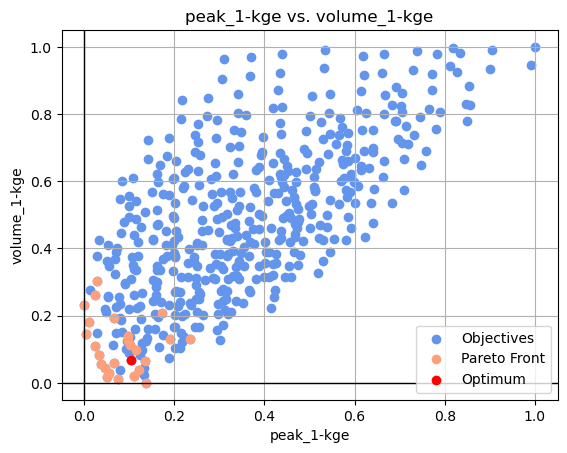

DataFrame Name: validation_2013_01_06


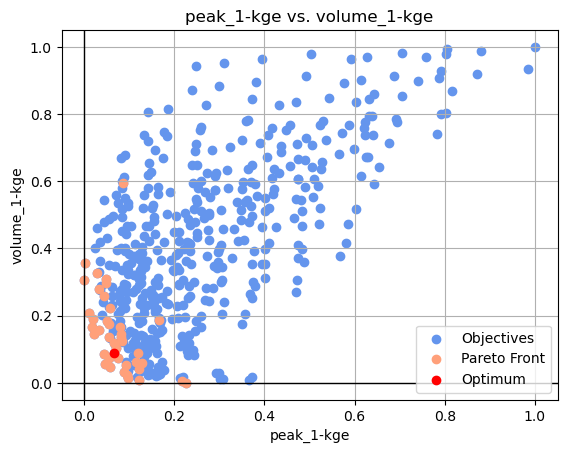

DataFrame Name: validation_2014_12_14


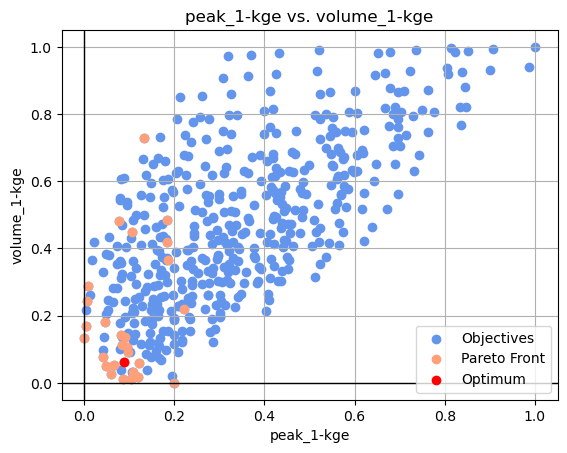

DataFrame Name: validation_2015_10_07


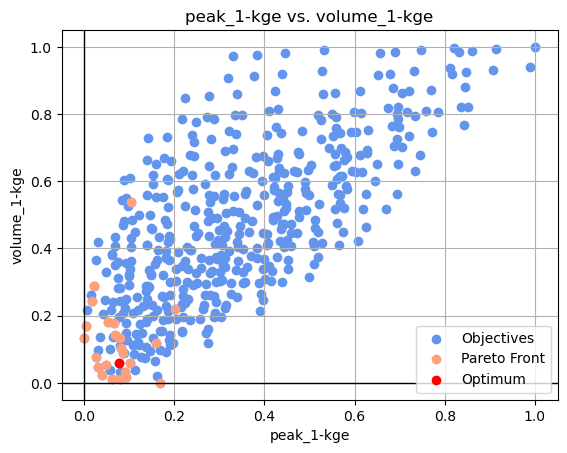

DataFrame Name: validation_2015_10_27


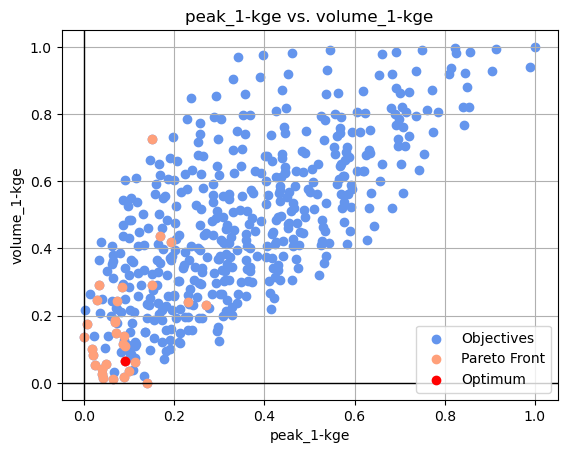

DataFrame Name: validation_2015_10_28


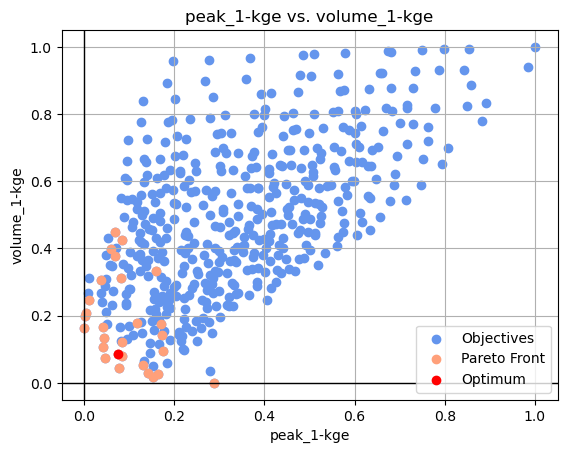

DataFrame Name: validation_2015_12_14


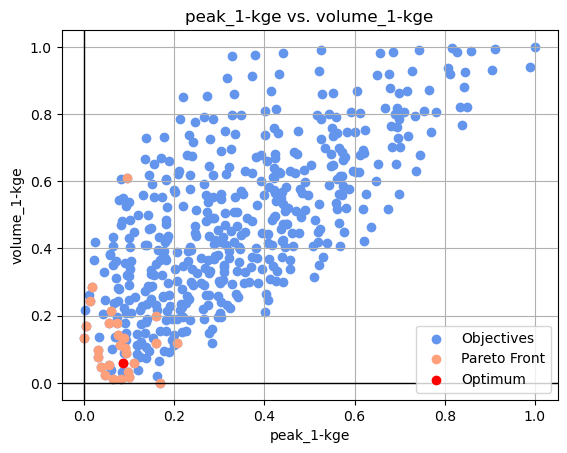

DataFrame Name: validation_2016_01_08


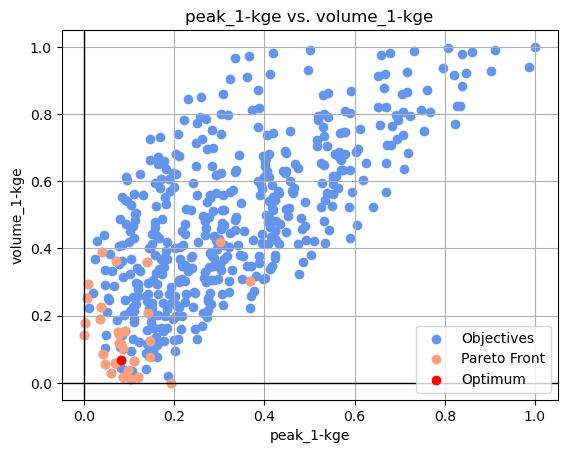

DataFrame Name: validation_2016_12_13


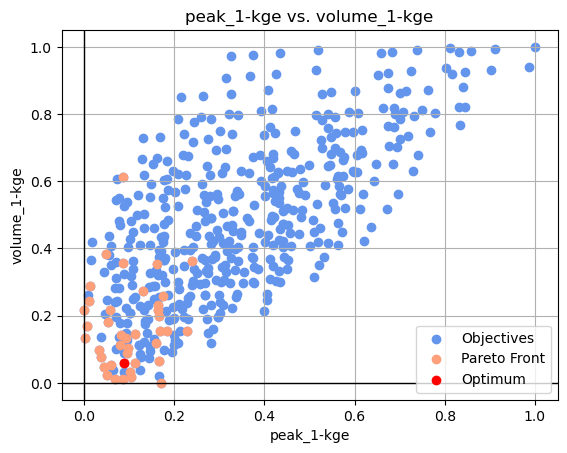

DataFrame Name: validation_2016_12_19


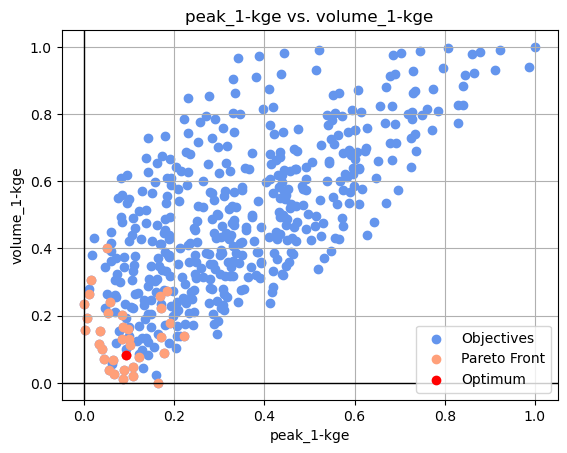

DataFrame Name: validation_2016_12_27


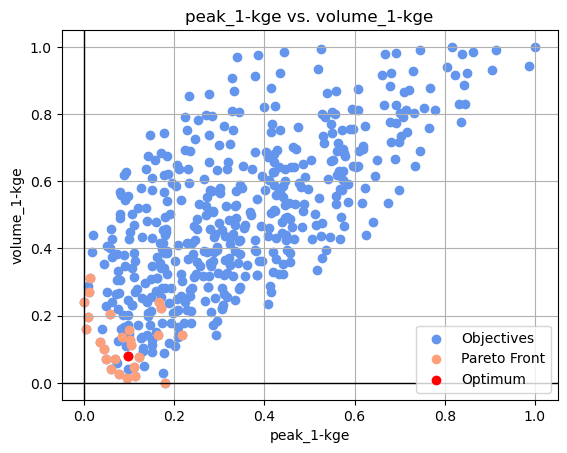

DataFrame Name: validation_2017_11_21


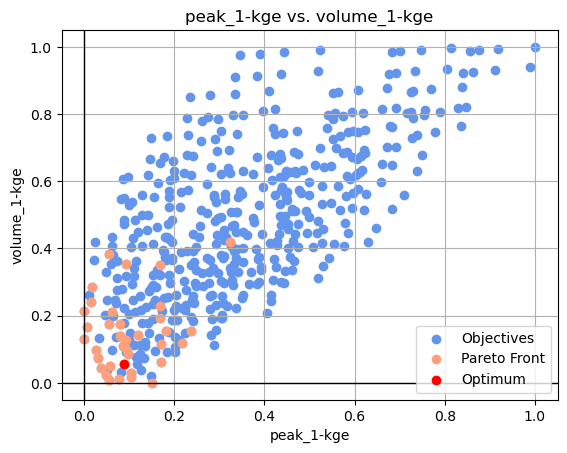

DataFrame Name: validation_2017_12_24


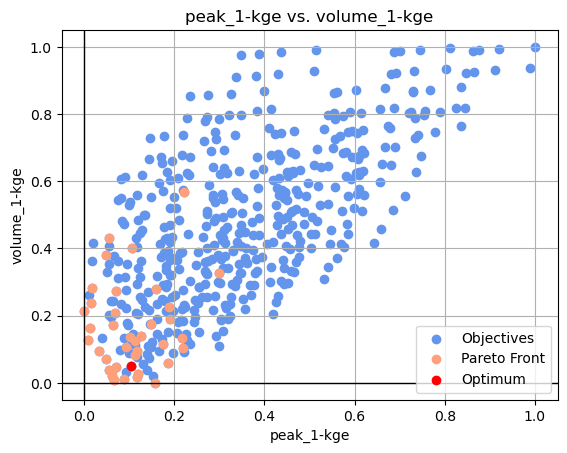

DataFrame Name: validation_2018_01_01


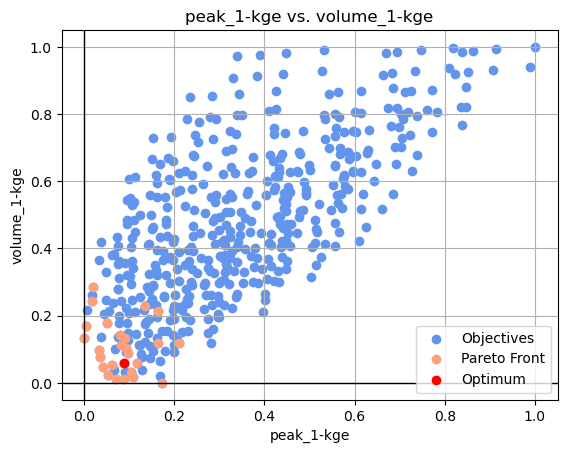

DataFrame Name: validation_2018_01_05


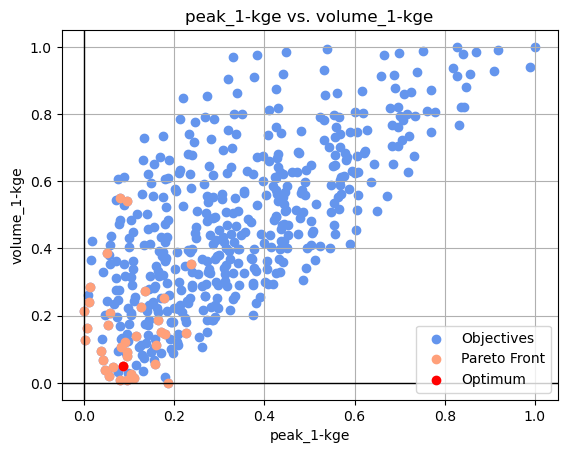

DataFrame Name: validation_2018_01_14


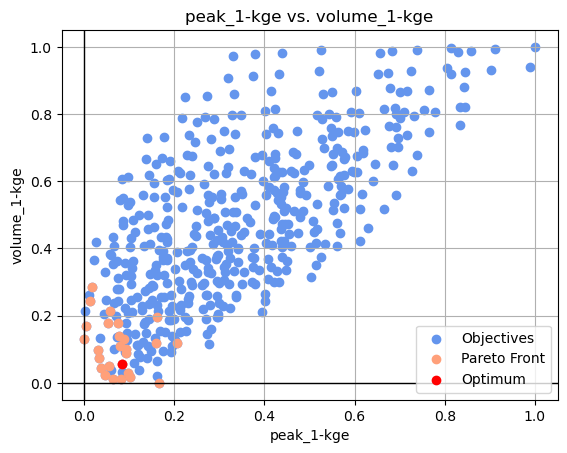

DataFrame Name: validation_2018_01_23


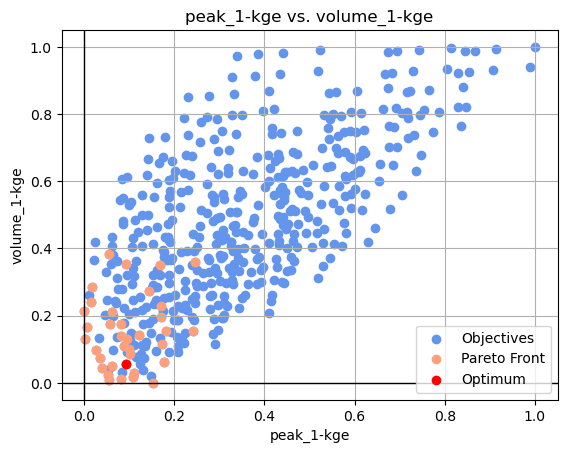

DataFrame Name: validation_2018_01_25


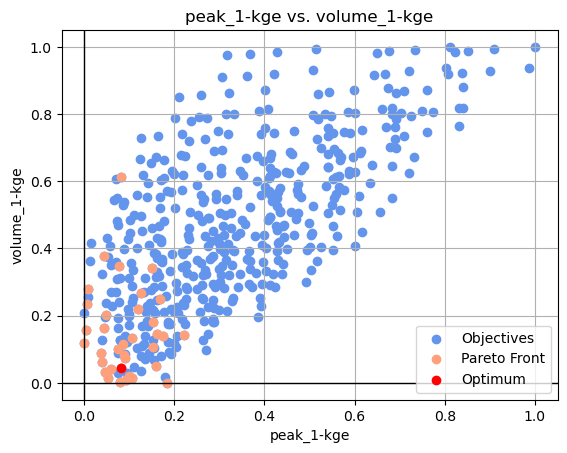

DataFrame Name: validation_2018_02_13


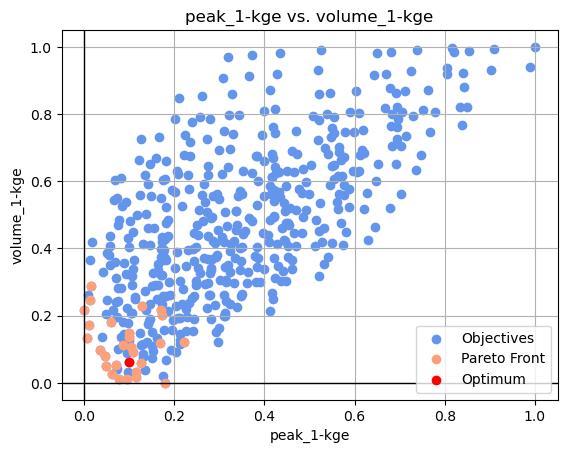

DataFrame Name: validation_2018_12_07


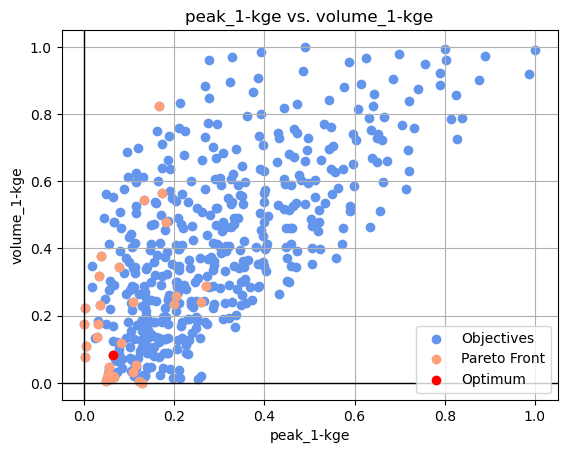

DataFrame Name: validation_2019_12_13


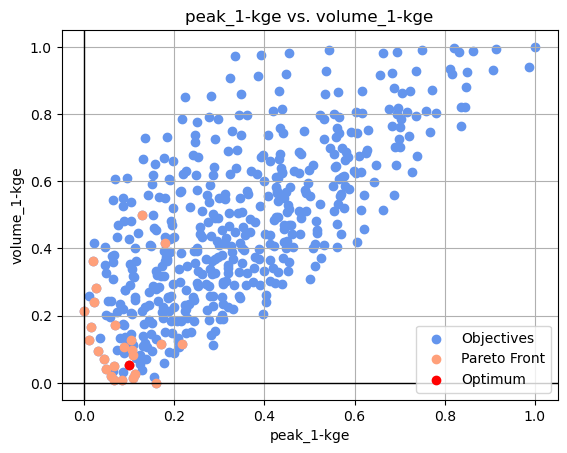

DataFrame Name: validation_2019_12_27


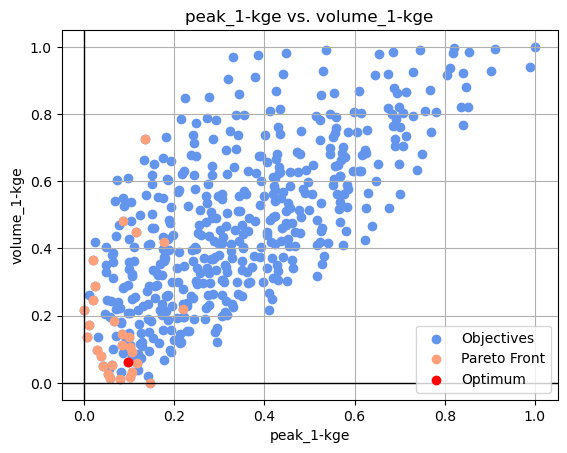

DataFrame Name: validation_2020_01_19


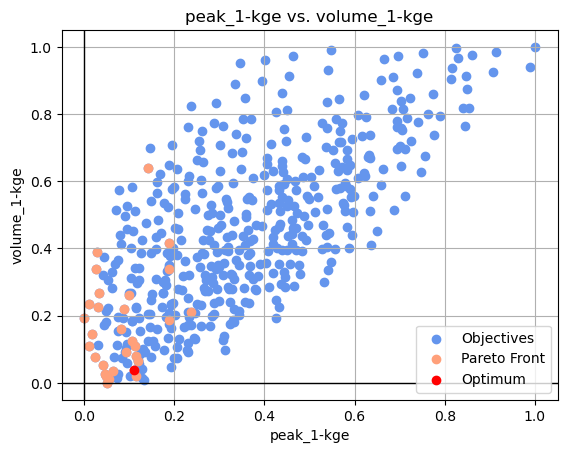

In [19]:
objectives_cols = [( 'storm objective functions',     'storm_1-nse'),
            ( 'storm objective functions',       'storm_rmsd'),
            ( 'storm objective functions',       'storm_bias'),
            ( 'storm objective functions',        'storm_mad'),
            ( 'storm objective functions',  'storm_r_squared'),
            ( 'storm objective functions',        'storm_1-kge'),
            (  'peak objective functions',       'peak_1-nse'),
            (  'peak objective functions',        'peak_rmsd'),
            (  'peak objective functions',        'peak_bias'),
            (  'peak objective functions',         'peak_mad'),
            (  'peak objective functions',   'peak_r_squared'),
            (  'peak objective functions',         'peak_1-kge'),
            ('volume objective functions',     'volume_1-nse'),
            ('volume objective functions',      'volume_rmsd'),
            ('volume objective functions',      'volume_bias'),
            ('volume objective functions',       'volume_mad'),
            ('volume objective functions', 'volume_r_squared'),
            ('volume objective functions',       'volume_1-kge')]


for key, cali_total_df in cross_validation_dict.items():
    
    print(f"DataFrame Name: {key}")

    objectives_df = cali_total_df[0][objectives_cols]
    objectives_df.columns = [col[1] if col in objectives_cols else col for col in objectives_df.columns]
    
#     ## for normalization:
    
    objectives_df = normalize_columns(abs(objectives_df[selected_objective_function]))

    ## Finding pareto front
    idx_to_drop_l = [] 
    clean_flag = False
    count = 0
    pareto_front_df = objectives_df.copy(deep=True)
    
    while clean_flag == False:
        for row in range(0,len(pareto_front_df)):
            count +=1
#             print(count)  
            for row_comp in range(len(pareto_front_df)):
                idx_to_drop = objective_fun_idx_to_drop(pareto_front_df, row, row_comp)
                if idx_to_drop is not None:
                    idx_to_drop_l.append(idx_to_drop)
                if count >= 9999999:
                    break
        if not idx_to_drop_l: 
            clean_flag = True
        else: 
            clean_flag = False
        pareto_front_df = pareto_front_df.drop(pareto_front_df.index[idx_to_drop_l])
        closest_point_df = closest_row_to_origin(pareto_front_df)
        closest_point_df = cross_validation_dict[key][0].iloc[closest_point_df.name]
        idx_to_drop_l = [] 
    
    cross_validation_dict[key].append(pareto_front_df)
    cross_validation_dict[key].append(closest_point_df)
    pareto_front_df = cross_validation_dict[key][3]
    closest_point_df = closest_row_to_origin(pareto_front_df)
    
    # Call the function for the first dataset and store the scatter object
    scatter1 = objective_scatter_plot(objectives_df, objective1, objective2, color = 'cornflowerblue')
    scatter2 = objective_scatter_plot(pareto_front_df, objective1, objective2, color='lightsalmon')
    scatter3 = objective_scatter_plot(closest_point_df, objective1, objective2, color='r')
    # Set axis labels and title
    plt.ylabel(objective2)
    plt.xlabel(objective1)
    plt.title(objective1 + ' vs. ' + objective2)

    plt.grid()
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    # Create a legend for the scatter plots
    plt.legend([scatter1, scatter2, scatter3], ['Objectives', 'Pareto Front', 'Optimum'], 
               scatterpoints=1, loc='lower right')
    # Display the plot
    plt.show() 
    
    
    objectives_df = cross_validation_dict[key][0][objectives_cols]
    objectives_df.columns = [col[1] if col in objectives_cols else col for col in objectives_df.columns]
        

# Save the dict to pickle

In [20]:
# Define the path and filename
path = r'C:\Users\raznu\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, '28catchments_cross_validation_cali_solution_dict.pickle')

# Save the dictionary as a pickle file
with open(filename, 'wb') as file:
    pickle.dump(cross_validation_dict, file)


# Load the dict to pickle

In [21]:
# Define the path and filename
path = r'C:\Users\raznu\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, '28catchments_cross_validation_cali_solution_dict.pickle')

# Load the dictionary from the pickle file
with open(filename, 'rb') as file:
    cross_validation_dict = pickle.load(file)
    
    
    

In [22]:
def compute_objective_functions(obs_hydrograph_df, cali_results_df, cali_swmm_hydrograph_df):
    # Define storm objective functions
    storm_objective_functions = ['storm_1-nse', 'storm_rmsd', 'storm_bias', 'storm_mad', 'storm_r_squared', 'storm_1-kge']
    columns = pd.MultiIndex.from_tuples([('storm objective functions', col) for col in storm_objective_functions])
    storm_objective_function_df = pd.DataFrame(columns=columns)

    # Define peak objective functions
    peak_objective_functions = ['peak_1-nse', 'peak_rmsd', 'peak_bias', 'peak_mad', 'peak_r_squared', 'peak_1-kge']
    columns = pd.MultiIndex.from_tuples([('peak objective functions', col) for col in peak_objective_functions])
    peak_objective_function_df = pd.DataFrame(columns=columns)

    # Define volume objective functions
    volume_objective_functions = ['volume_1-nse', 'volume_rmsd', 'volume_bias', 'volume_mad', 'volume_r_squared', 'volume_1-kge']
    columns = pd.MultiIndex.from_tuples([('volume objective functions', col) for col in volume_objective_functions])
    volume_objective_function_df = pd.DataFrame(columns=columns)

    # Compute storm objective functions
    obs_hydrograph_arr = obs_hydrograph_df['OBS runoff [CMS]'].values.astype(np.float64)
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_hydrograph = cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iloc[idx].astype(np.float64)
        storm_nse, storm_rmsd, storm_bias, storm_mad, storm_r_squared, storm_kge = calculate_objectives(obs_hydrograph_arr, simulated_hydrograph)
        storm_objective_function_df.loc[idx] = [(1 - storm_nse), storm_rmsd, storm_bias, storm_mad, storm_r_squared, (1 - storm_kge)]

    # Compute peak objective functions
    obs_max_runoff = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max().astype(np.float64)
    cali_swmm_peak_flow_df = cali_results_df.xs('Max Runoff', level=1, axis=1, drop_level=False).astype(np.float64)
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_peak = cali_swmm_peak_flow_df.iloc[idx]
        peak_nse, peak_rmsd, peak_bias, peak_mad, peak_r_squared, peak_kge = calculate_objectives(obs_max_runoff, simulated_peak)
        peak_objective_function_df.loc[idx] = [(1 - peak_nse), peak_rmsd, peak_bias, peak_mad, peak_r_squared, (1 - peak_kge)]

    # Compute volume objective functions
    obs_storm_volume = (obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60).astype(np.float64)
    cali_swmm_total_volume_df = (cali_results_df.xs('Total Volume', level=1, axis=1, drop_level=False) * 5 * 60).astype(np.float64)
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_volume = cali_swmm_total_volume_df.iloc[idx]
        volume_nse, volume_rmsd, volume_bias, volume_mad, volume_r_squared, volume_kge = calculate_objectives(obs_storm_volume, simulated_volume)
        volume_objective_function_df.loc[idx] = [(1 - volume_nse), volume_rmsd, volume_bias, volume_mad, volume_r_squared, (1 - volume_kge)]

    return storm_objective_function_df, peak_objective_function_df, volume_objective_function_df


# STEP 4 - Run Validation Storms 

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2012_01_13/validation.inp:   0%|       …

C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  r = r_num / r_den
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:82: RuntimeWarning: invalid value encountered in true_divide
  alpha = np.std(simulations, axis=0) / np.std(evaluation, dtype=np.float64)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:34: RuntimeWarning: divide by zero encountered in double_scalars
  r_squared = 1 - (ss_diff / ss_total)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2013_01_06/validation.inp:   0%|       …

C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  r = r_num / r_den
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:82: RuntimeWarning: invalid value encountered in true_divide
  alpha = np.std(simulations, axis=0) / np.std(evaluation, dtype=np.float64)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:34: RuntimeWarning: divide by zero encountered in double_scalars
  r_squared = 1 - (ss_diff / ss_total)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2014_12_14/validation.inp:   0%|       …

...

C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2005789587.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(12, 6))
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  r = r_num / r_den
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:82: RuntimeWarning: invalid value encountered in true_divide
  alpha = np.std(simulations, axis=0) / np.std(evaluation, dtype=np.float64)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:34: RuntimeWarning: divid

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2019_12_27/validation.inp:   0%|       …

C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  r = r_num / r_den
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:82: RuntimeWarning: invalid value encountered in true_divide
  alpha = np.std(simulations, axis=0) / np.std(evaluation, dtype=np.float64)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:34: RuntimeWarning: divide by zero encountered in double_scalars
  r_squared = 1 - (ss_diff / ss_total)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2020_01_19/validation.inp:   0%|       …

C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  r = r_num / r_den
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:82: RuntimeWarning: invalid value encountered in true_divide
  alpha = np.std(simulations, axis=0) / np.std(evaluation, dtype=np.float64)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:34: RuntimeWarning: divide by zero encountered in double_scalars
  r_squared = 1 - (ss_diff / ss_total)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\2314548913.py:26: RuntimeWarning: divide by zero encountered in double_scalars
  nse = 1 - (ss_diff / ss_mean)
C:\Users\raznu\Anaconda3\lib\site-packages\hydroeval\objective_functions.py:80: RuntimeWarning: invalid value encountered in true_divide
  

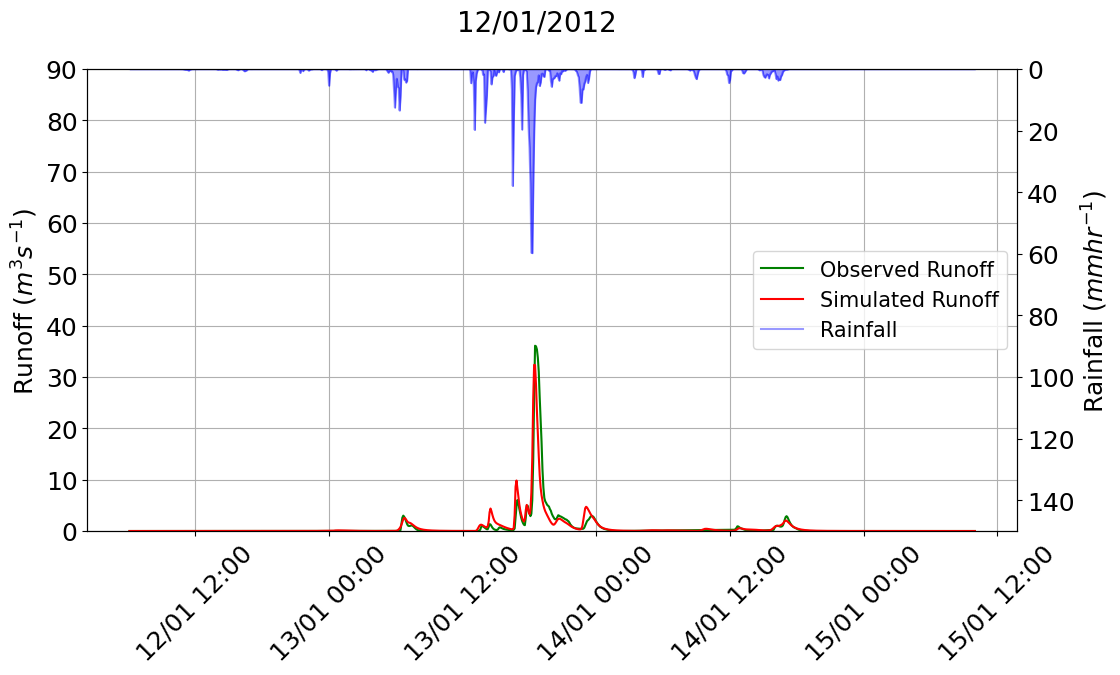

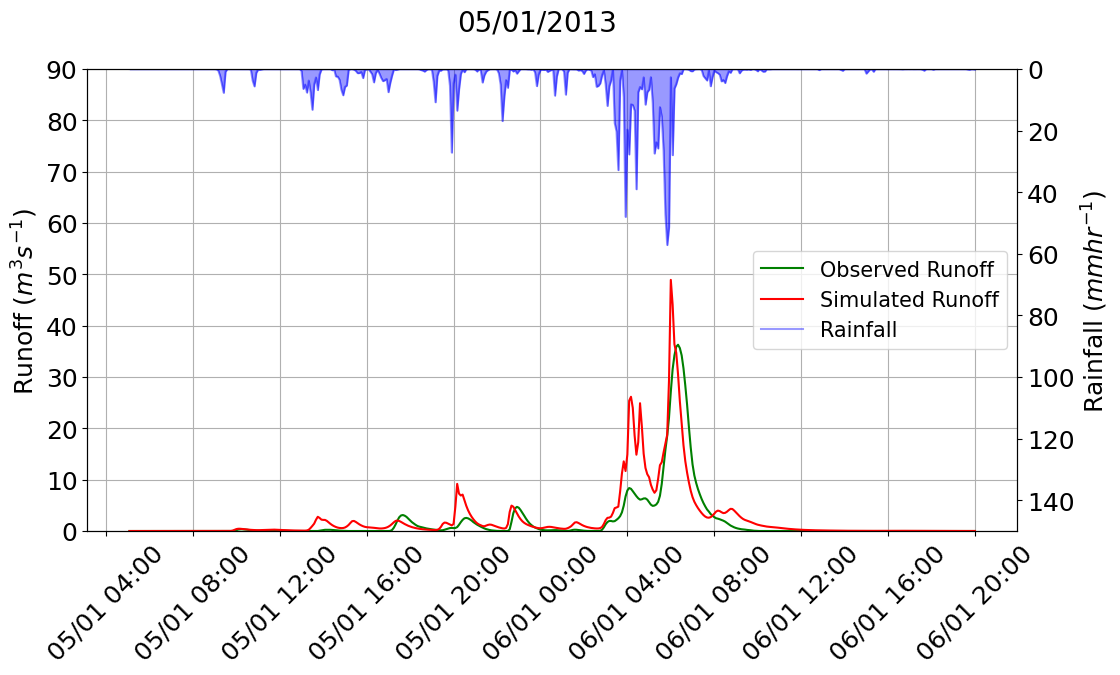

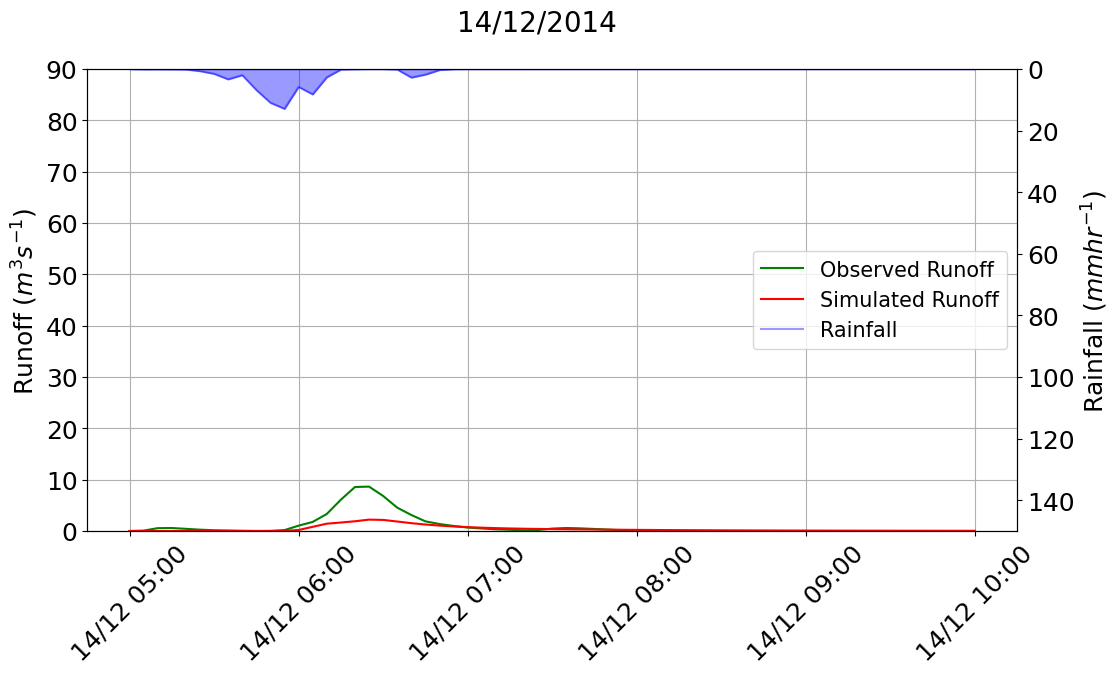

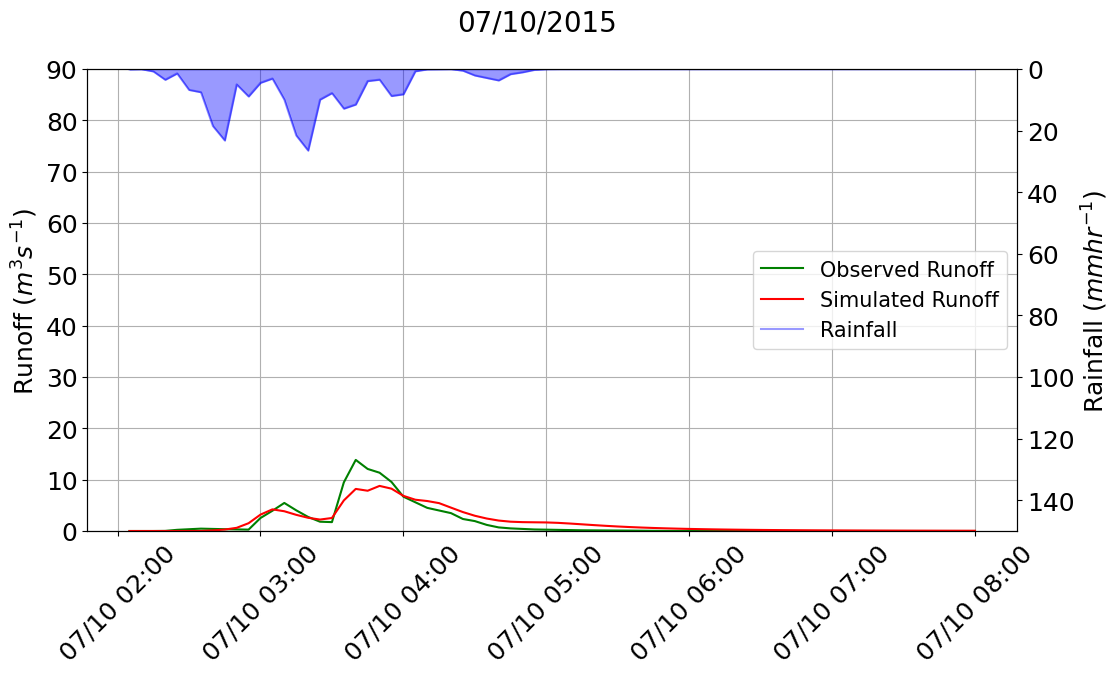

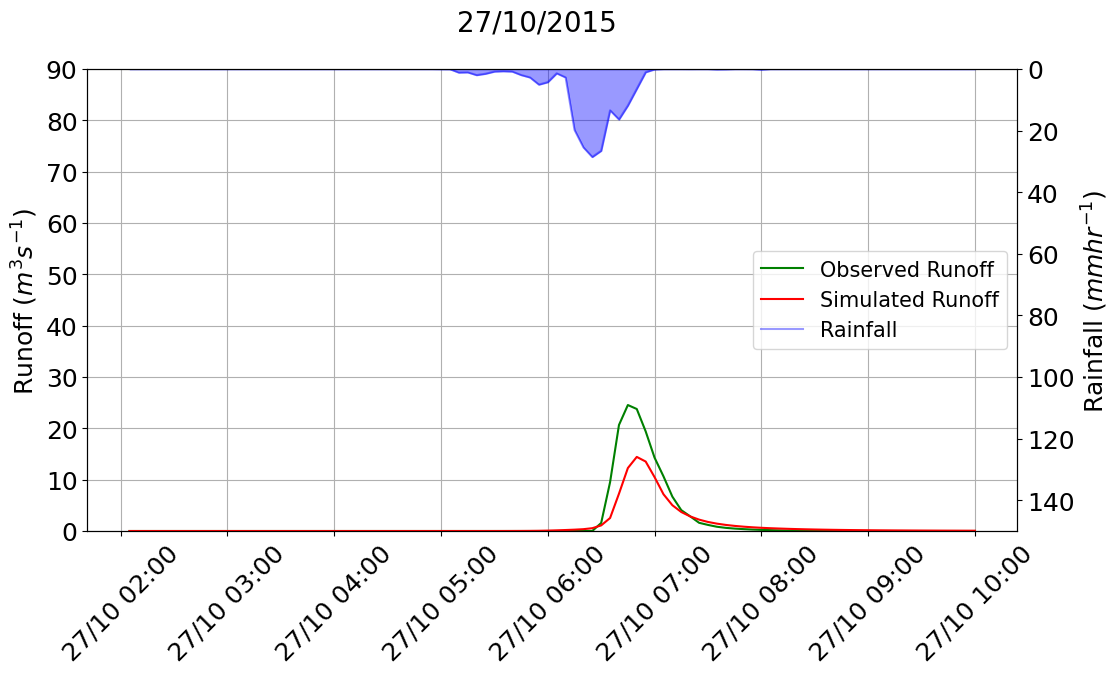

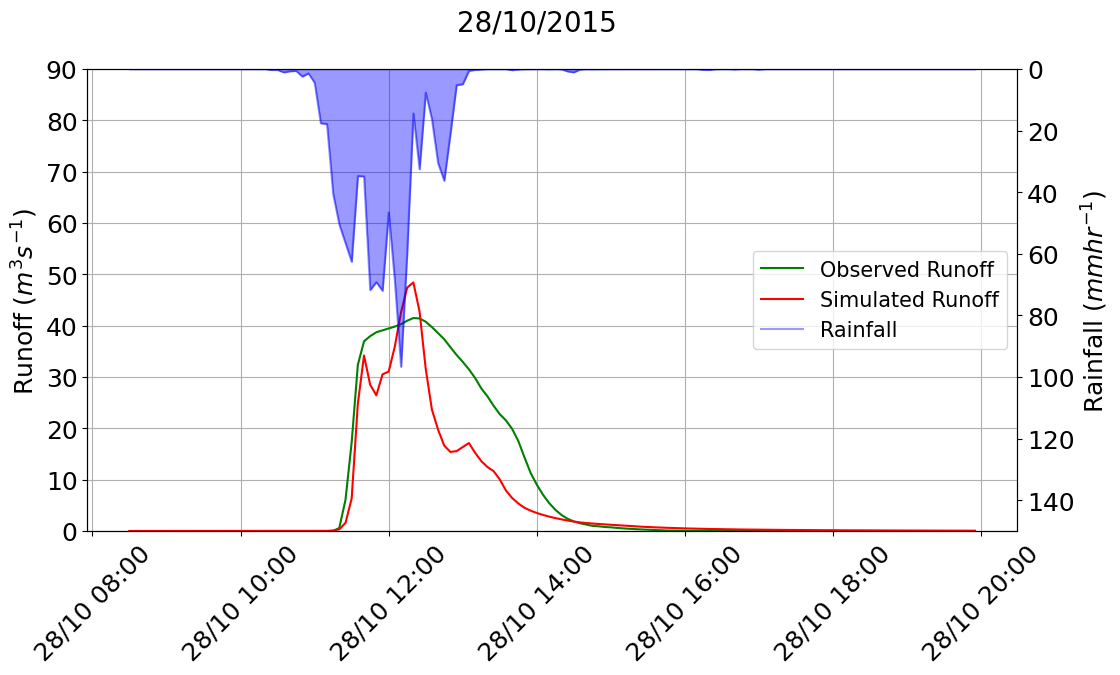

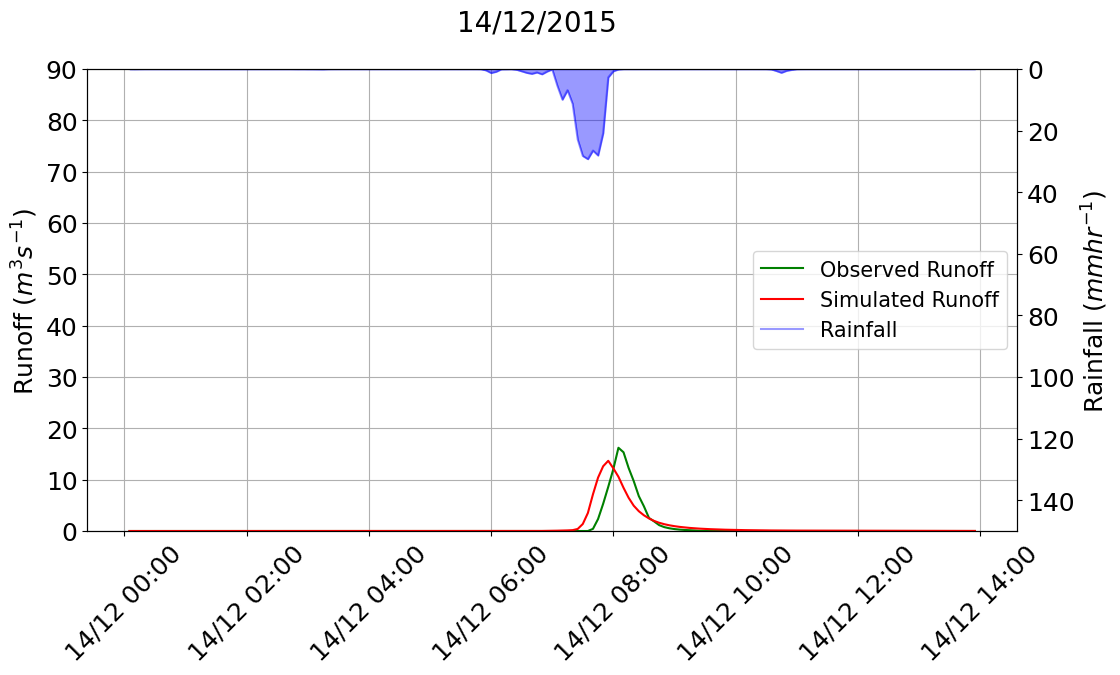

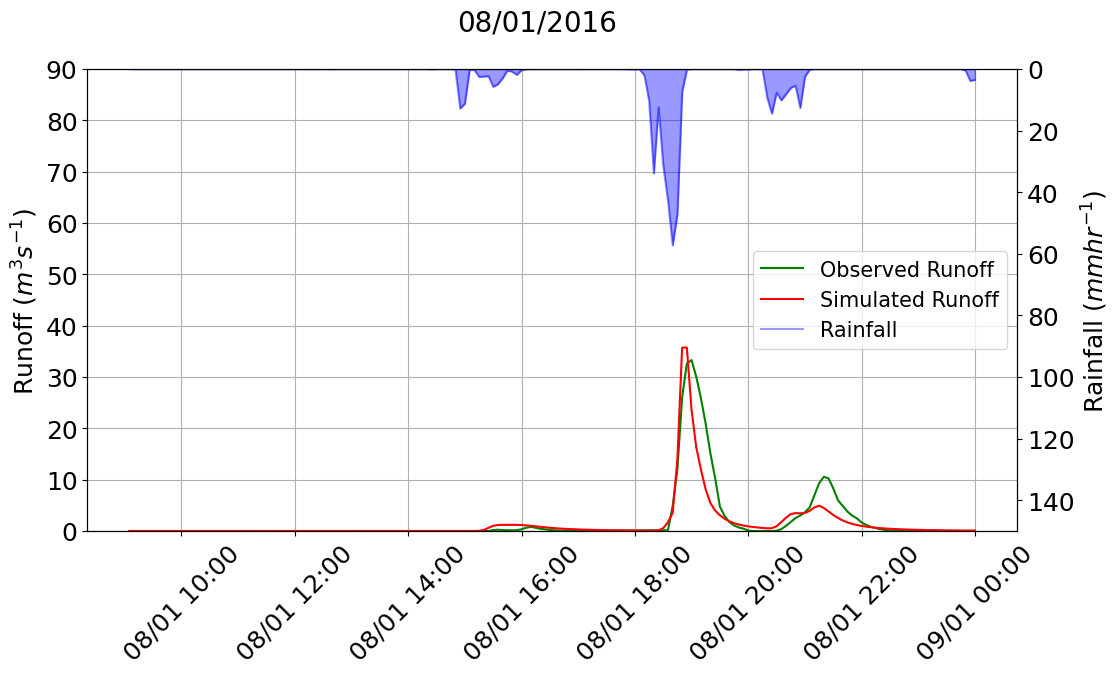

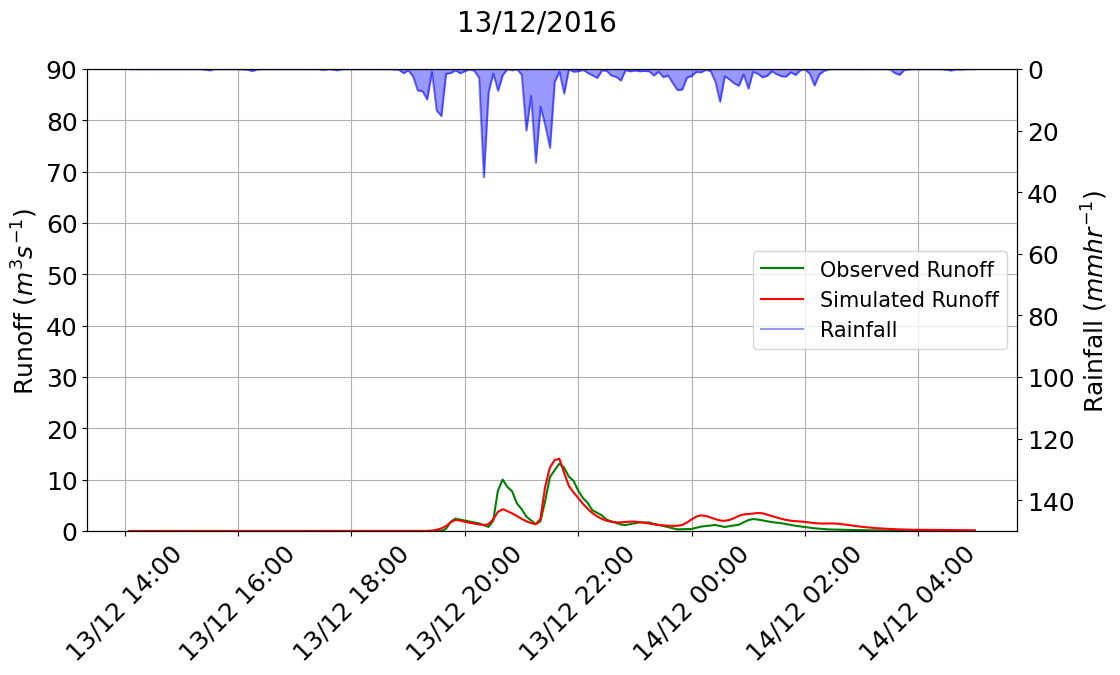

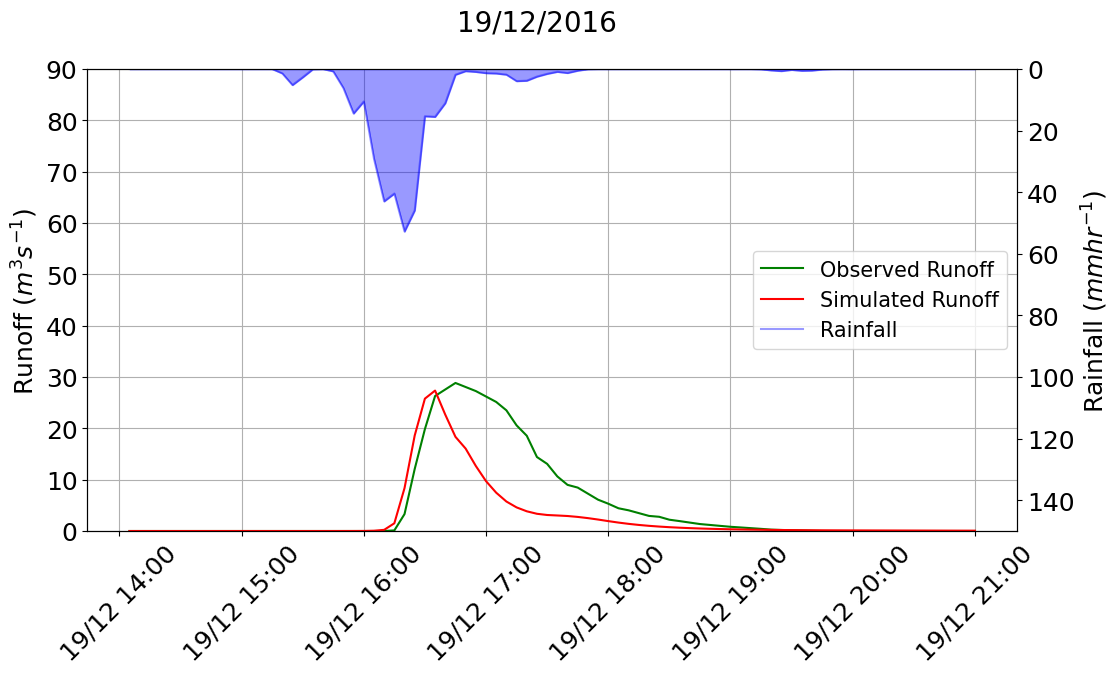

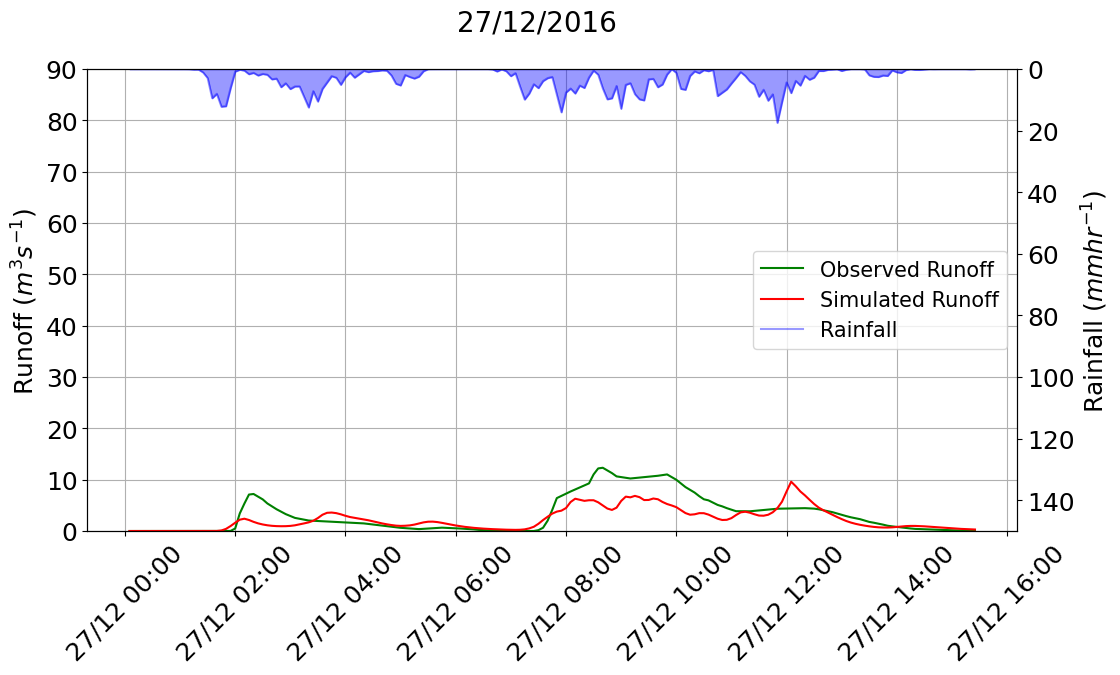

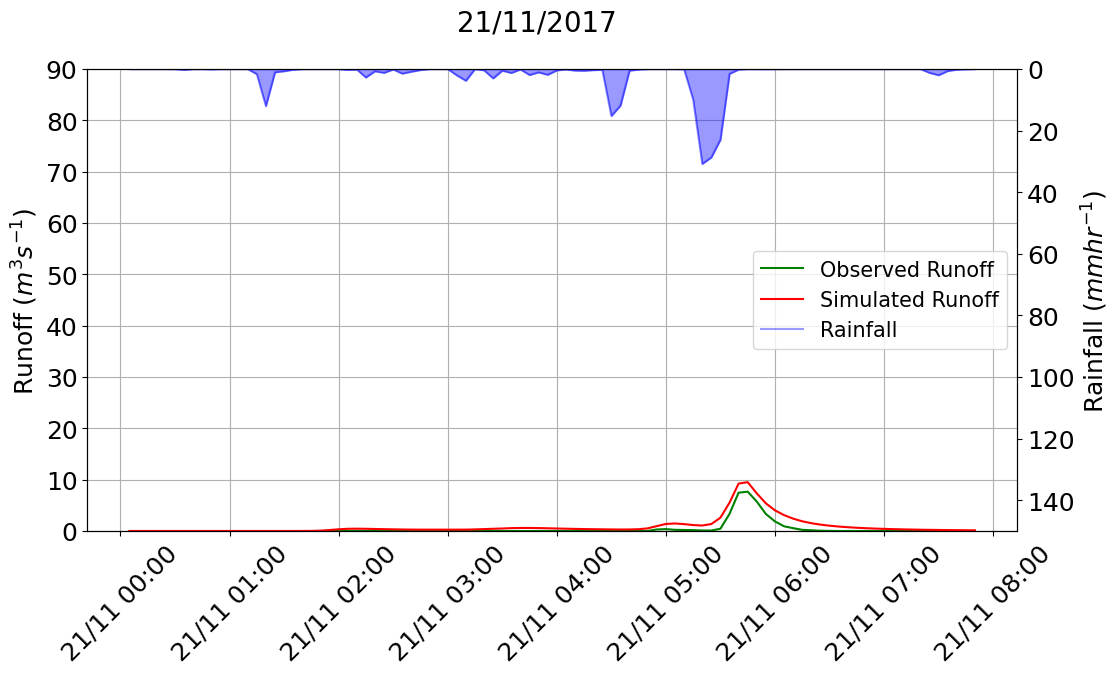

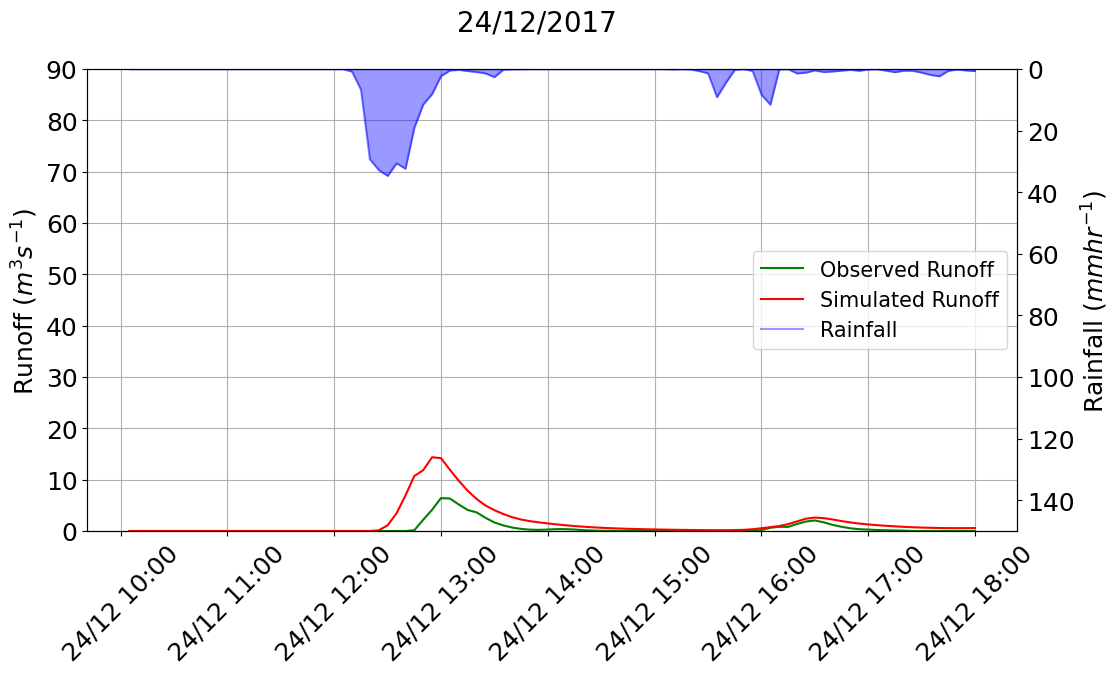

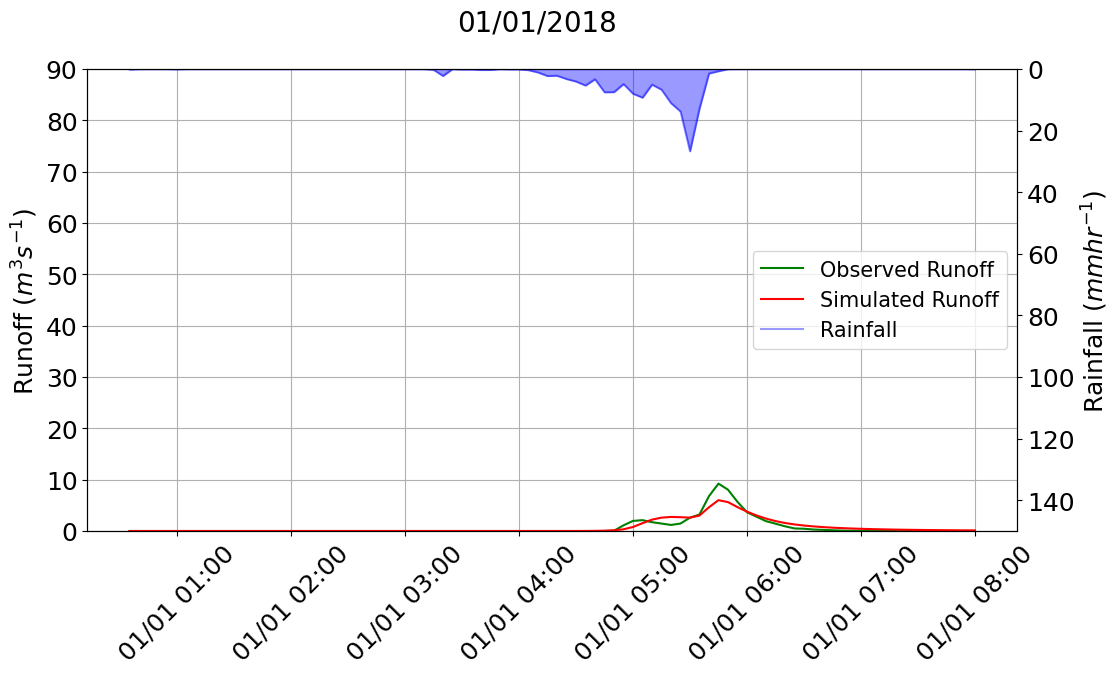

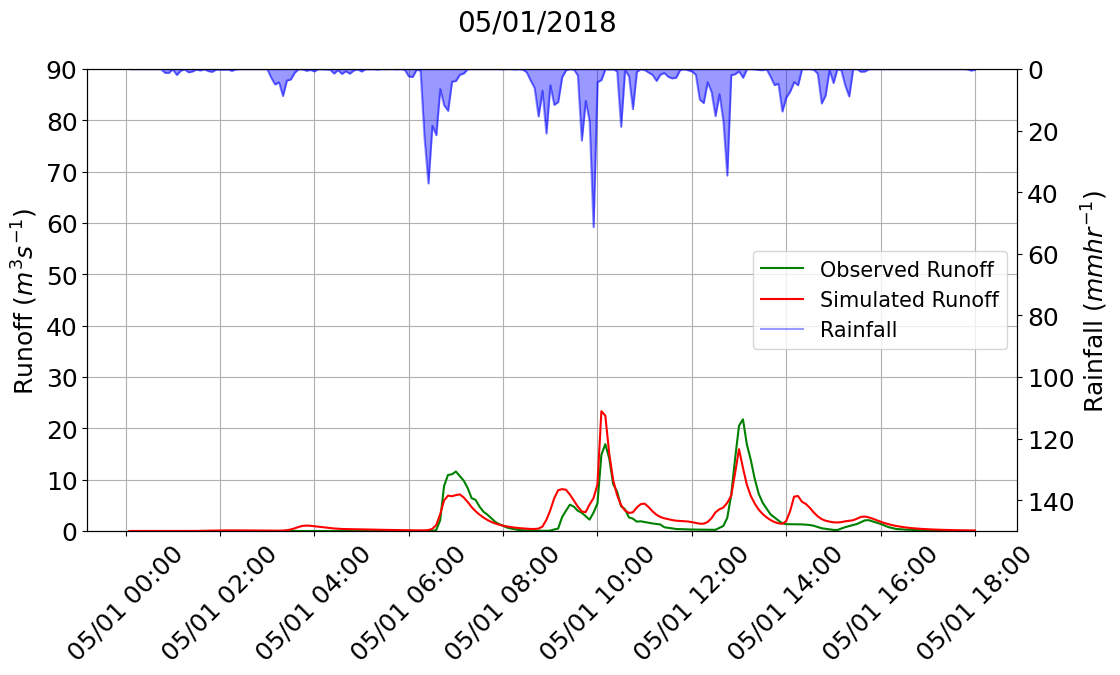

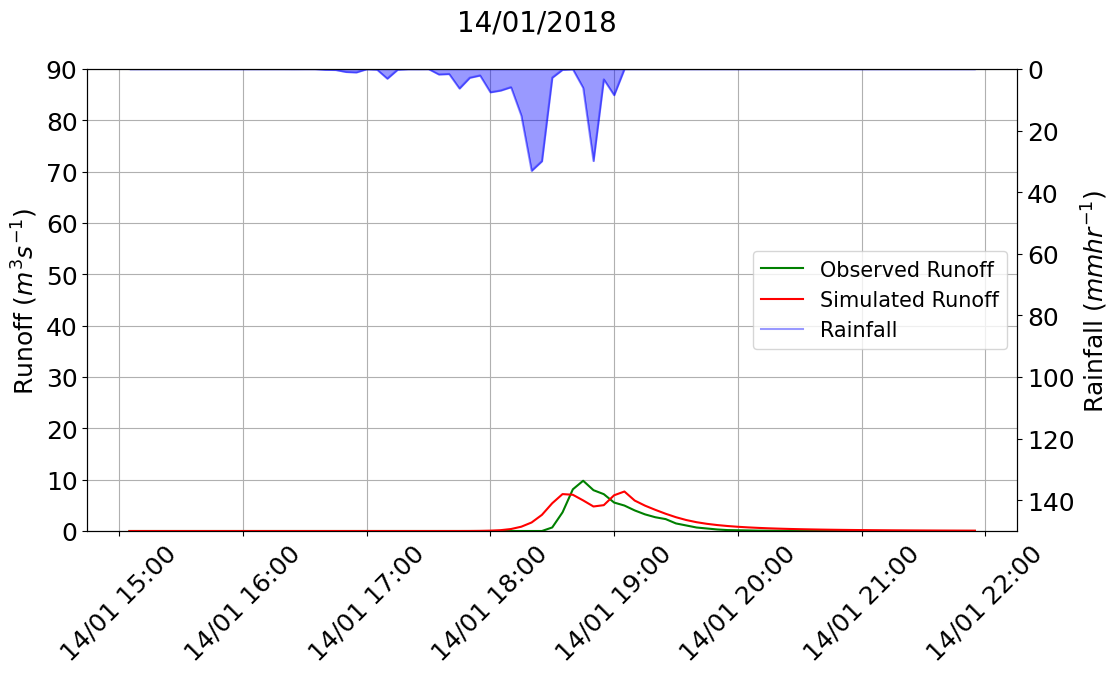

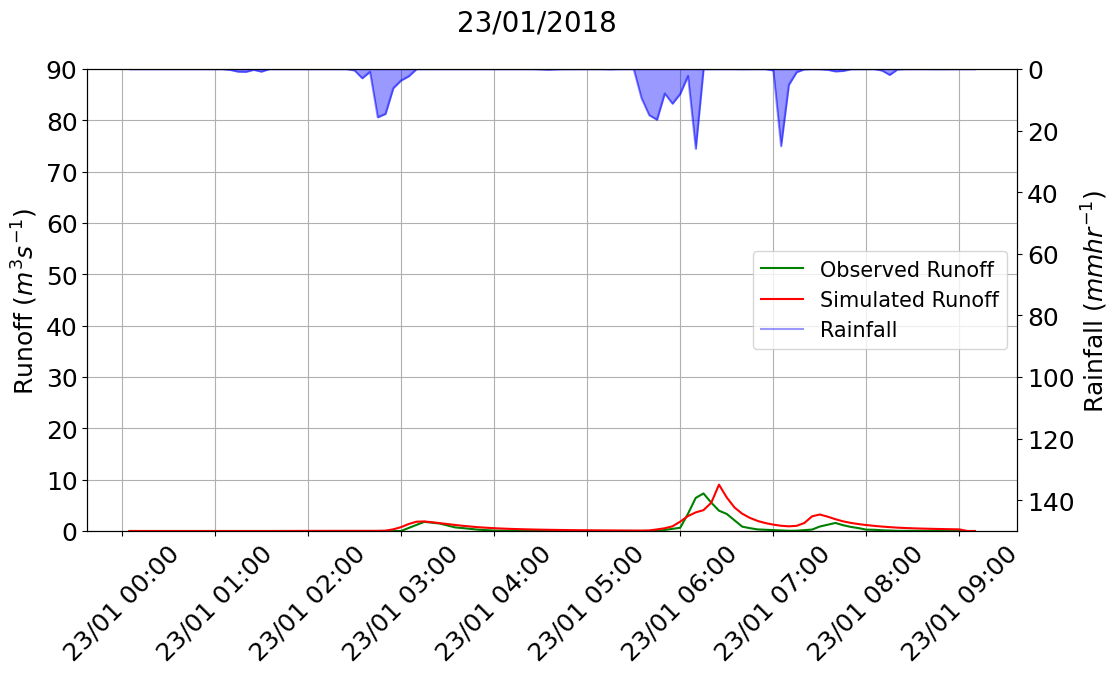

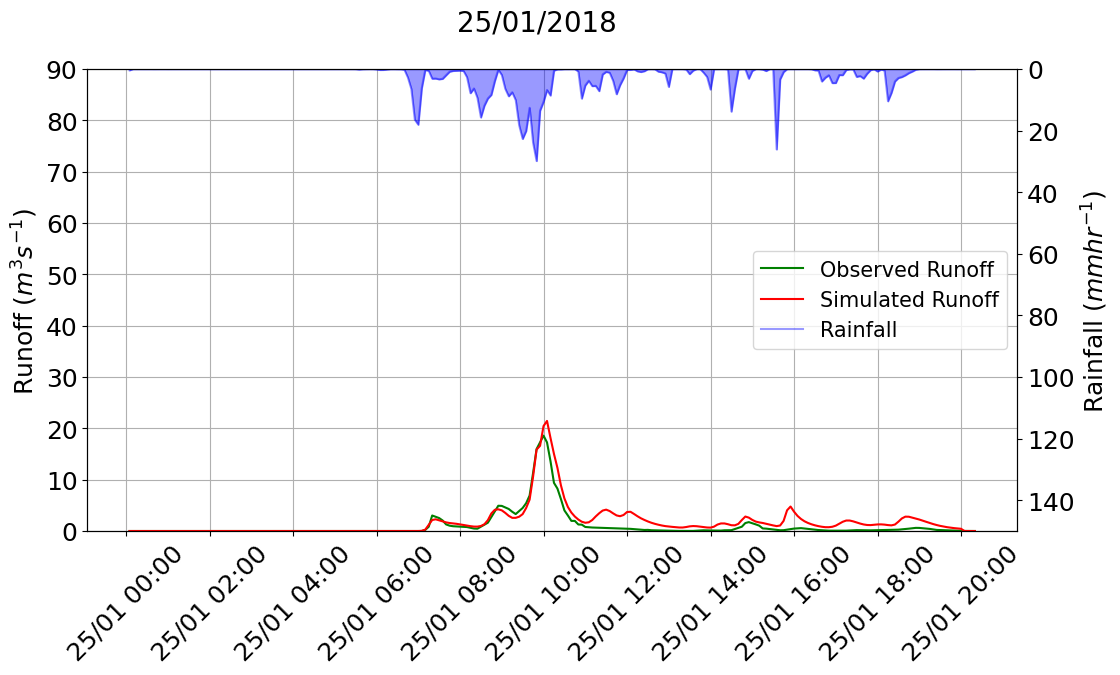

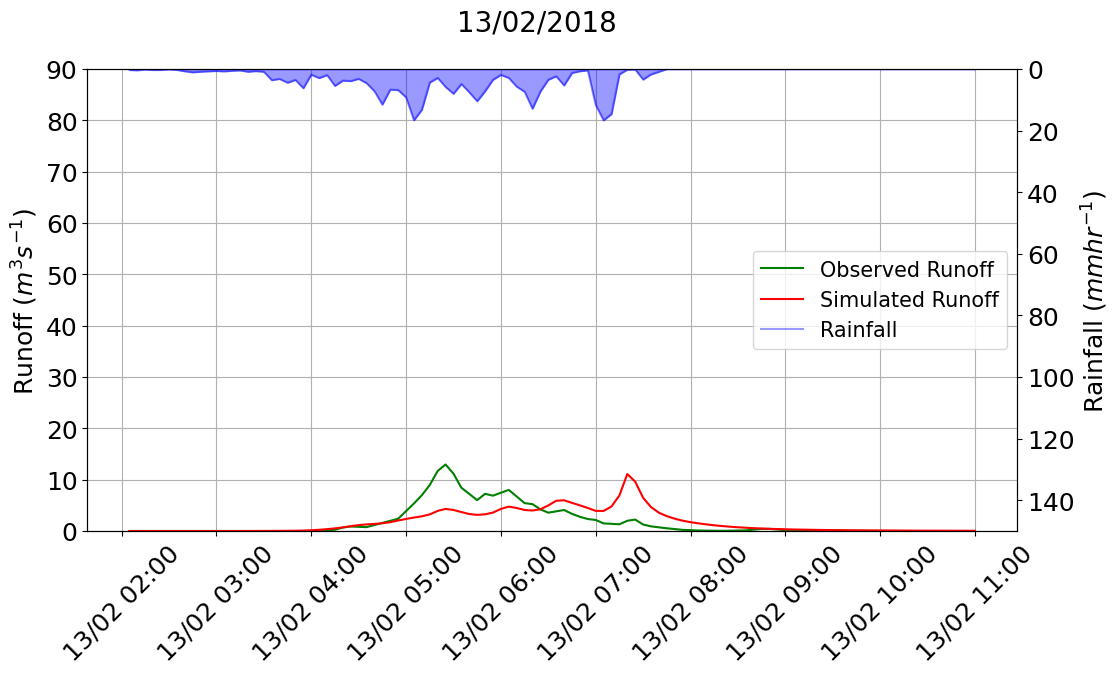

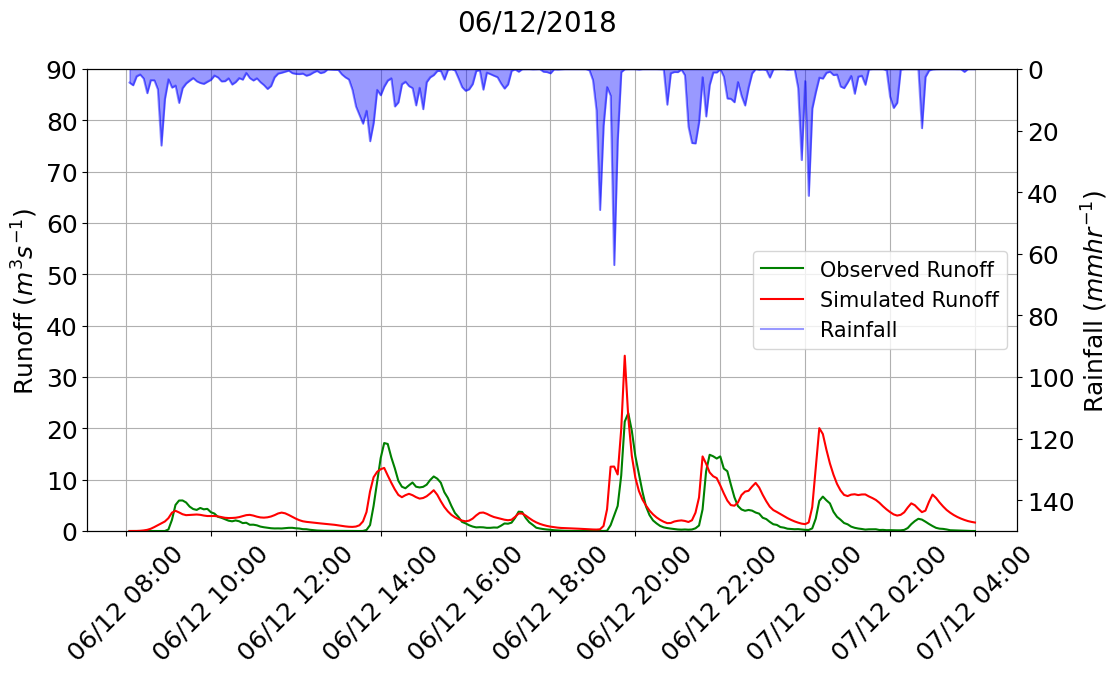

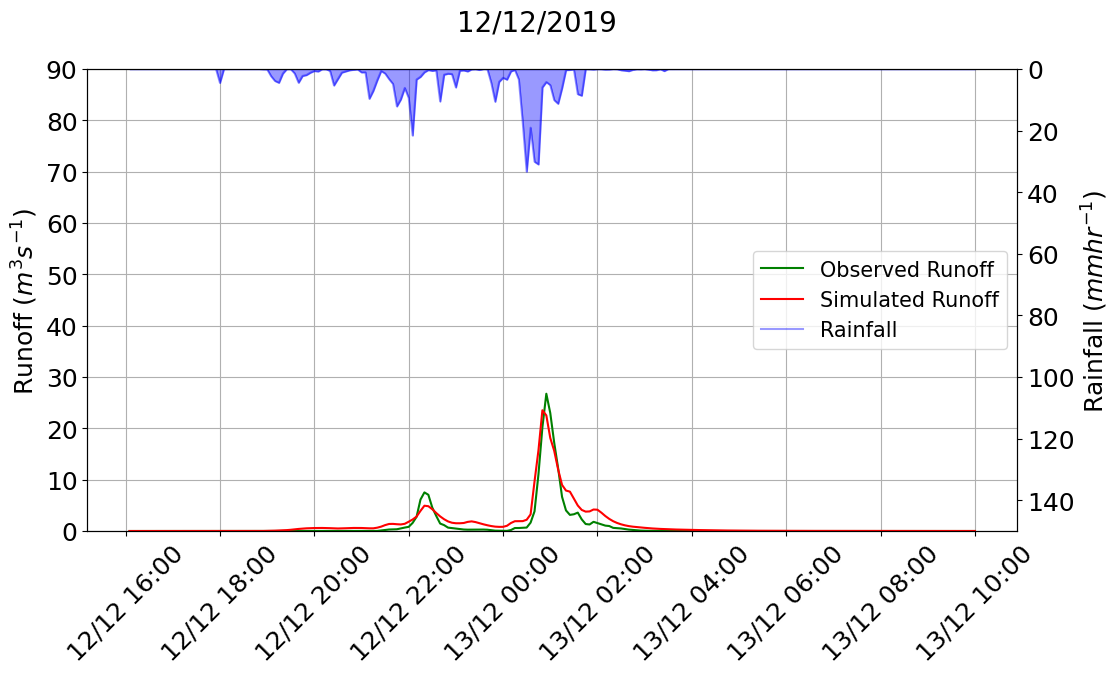

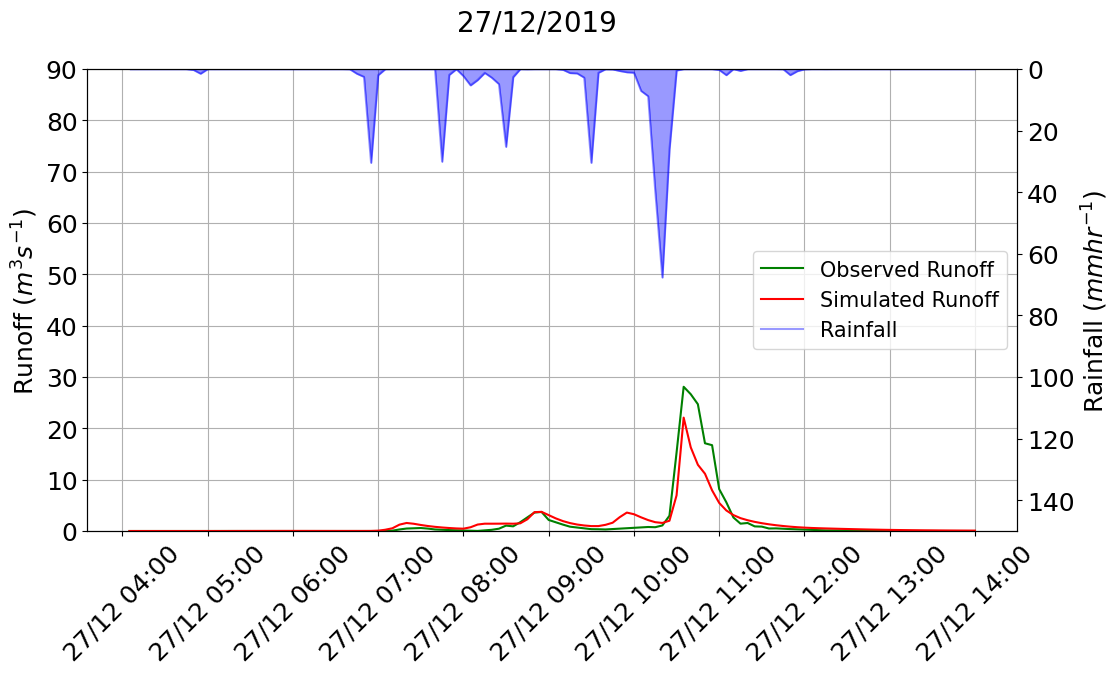

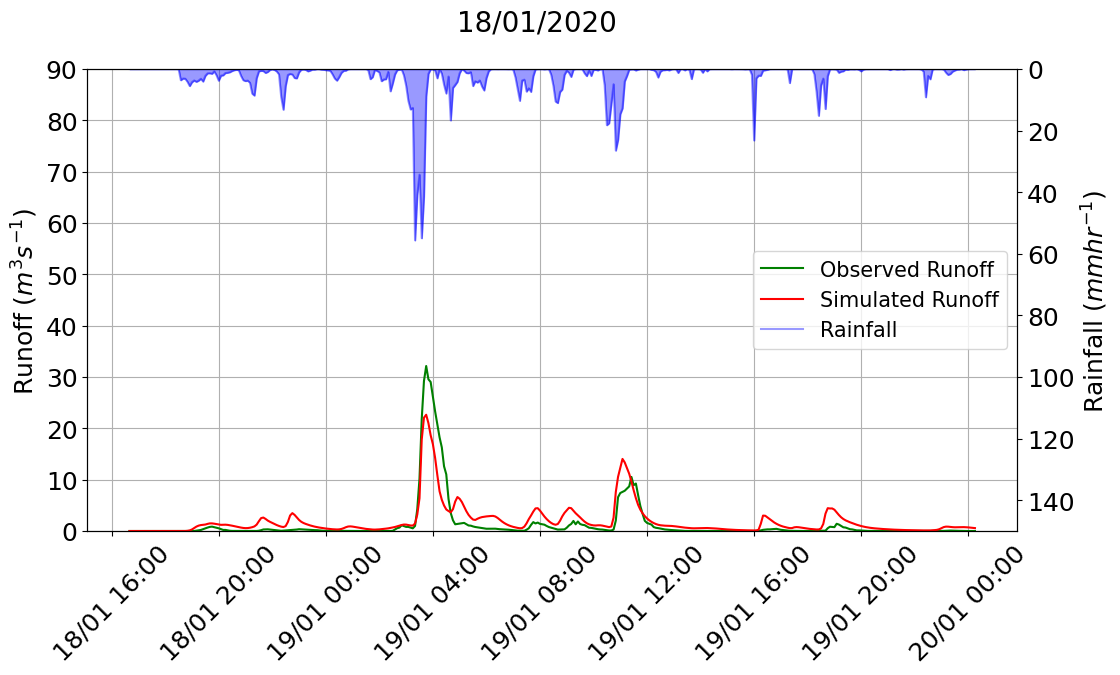

In [23]:
# MAIN_PATH = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation_WITH_NEW_STORMS/"
MAIN_PATH = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/"

imp_factor_l = [] ; width_factor_l = [] ; storage_factor_l = [] ; pct_zero_factor_l = [] ; n_factor_l =[] ; cn_factor_l =[]
pct_routed_factor_l = [] ; evap_factor_l = [] 
vali_results_df_l =[] ; hydrograph_df_l = [] ; swmm_runoff_l = [] ; 
swmm_max_runoff_time_l =[] ; swmm_total_runoff_l = [] ; swmm_max_runoff_l = [] ;

count = 0 ; 
obs_hydrograph_df = pd.DataFrame()

# width_initial_values = np.array([896, 1161, 680, 503, 545, 1222, 860, 447, 777, 889, 1348, 476, 1180, 451, 846, 715, 1067, 669, 617, 565, 1095, 1255, 1005, 394, 399, 771, 1366, 471])
width_initial_values = np.array([2470, 2800, 2800, 1890, 1160, 2840, 2660, 2000, 1140, 1400, 540, 2200, 4160, 1070, 1310, 1310, 1200, 1440, 1400, 1400, 1520, 1850, 1740, 2504, 980, 1900, 2140, 950]) # W=2L method     curve_no_initial_values = np.array([71, 61, 61, 61, 61, 61, 61, 61, 71, 61, 61, 71, 66, 61, 66, 71, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 71])
# curve_no_initial_values = np.array([71, 61, 61, 61, 61,  61, 61, 61, 71, 61, 61, 71, 66, 61, 66, 71, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 61, 71])
curve_no_initial_values = np.array([39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39])
pct_zero_initial_values = np.array([30, 50, 50, 50, 50, 50, 50, 50, 30, 50, 50, 30, 30, 50, 30, 50, 50, 50, 50, 50, 50, 60, 50, 50, 50, 60, 60, 30])

# Call the update function with the initial pct_zero values array

for i, cross_val in enumerate(cross_validation_dict):
    # Retrieve factors from the dictionary
    width_factor = cross_validation_dict[cross_val][4][('Factors','Width')]
    imp_factor = cross_validation_dict[cross_val][4][('Factors','IMP')]
    storage_factor = cross_validation_dict[cross_val][4][('Factors','Storage')]
    n_factor = cross_validation_dict[cross_val][4][('Factors','N')]
    pct_zero_factor = cross_validation_dict[cross_val][4][('Factors','PCT_ZERO')]
    cn_factor = cross_validation_dict[cross_val][4][('Factors','CN')]
    pct_routed_factor = cross_validation_dict[cross_val][4][('Factors','PCT_ROUTED')]
    evap_factor = cross_validation_dict[cross_val][4][('Factors','EVAP')]
    # date of calidation storm (in cross calidation method)
    date = cross_val.split('_')[1:]
    date= '_'.join(date)
#     bias = BIAS_L[i]

    SIM_PATH = os.path.join(MAIN_PATH, date + '/')
    ## Load the storm OBS data
    OBS_FILE = date 
    obs_runoff_df = data_5min_interpolate(load_runoff_obs_to_df(SIM_PATH + OBS_FILE))
    
    ## Load the SIM inp and dict - rest each iterate
    INP_FILE = r"raanana_28subcatchments.inp"
    inp = read_inp_file(SIM_PATH + INP_FILE) 
    subcatchment_d = dict(inp[sections.SUBCATCHMENTS])
    infiltration_d = dict(inp[sections.INFILTRATION])
    subareas_d = dict(inp[sections.SUBAREAS])
    timesereies_d = dict(inp[sections.TIMESERIES])
    
    update_imperviousness_with_factor(subcatchment_d, imp_factor)
    update_storage_with_factor(subareas_d, storage_factor)
    update_width_with_factor(subcatchment_d, width_factor, width_initial_values)
    update_n_with_factor(subareas_d, n_factor)   
    update_pct_zero_with_factor(subareas_d, pct_zero_factor, pct_zero_initial_values)
    update_curve_num_with_factor(infiltration_d, cn_factor, curve_no_initial_values)
    
    update_pct_routed_with_factor(subareas_d, 'PERVIOUS', pct_routed_factor)
    inp['EVAPORATION']['CONSTANT'] = evap_factor
    
    ## ---------------------RUN THE SIM----------------------
    file_name = 'validation'    # use it if you dont want to save the simulations swmm files
#     file_name = 'calibration_sf_{:.2f}_imp_{:.2f}_cn_{:.2f}_N_{:.2f}_CN_{:.2f}'.format(storage_factor, imp_factor, width_factor, n_factor, pct_zero_factor)
    inp.write_file(SIM_PATH + file_name + '.inp')
    swmm5_run(SIM_PATH + file_name + '.inp', progress_size=1)
    
    OUT_FILE = file_name +'.out'
    sim_df = load_sim_to_df(SIM_PATH+OUT_FILE)
    ## concat observed and simulated data -> The storm_df (choose one of 2 options)
    storm_df = pd.concat( [obs_runoff_df , sim_df] , axis=1)   ## concat by the larger index
#                         storm_df = obs_runoff_df.join(sim_df, how='inner')           ## join by the smaller index
    storm_df[storm_df < 0] = 0  ; storm_df = storm_df.fillna(0)

    ## ----------------VISUALIZATION AND STAT----------------
#     if imp_factor==1 and width_factor==1 and storage_factor==1 and n_factor==1 and pct_zero_factor==1:
    fig = observation_and_swmm_hydrograph(storm_df,date)
      # Optional! show or save the fig
#                     plt.show()  

#     fig.savefig(os.path.join(r'D:\Development\RESEARCH\Raanana\figures\cross_validation/', date + '.png'), dpi=900)

    swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff, swmm_max_runoff_time = stat(storm_df)


    imp_factor_l.append(imp_factor)
    width_factor_l.append(width_factor)
    storage_factor_l.append(storage_factor)
    n_factor_l.append(n_factor)
    cn_factor_l.append(cn_factor)
    pct_zero_factor_l.append(pct_zero_factor)
    pct_routed_factor_l.append(pct_routed_factor)
    evap_factor_l.append(evap_factor)
    
    
    swmm_total_runoff_l.append(swmm_total_runoff)
    swmm_max_runoff_l.append(swmm_max_runoff)
    swmm_max_runoff_time_l.append(swmm_max_runoff_time)
    swmm_runoff_l.append(list(storm_df['SWMM outflow [CMS]'].values))
    
    factor = pd.DataFrame(columns=pd.MultiIndex.from_product([['Factors'],
                                                              ['Width', 'IMP', 'Storage', 'N', 'PCT_ZERO','CN', 'PCT_ROUTED', 'EVAP']]))
    vali_results_df = pd.DataFrame(columns=pd.MultiIndex.from_product([[date],
                    ['Total Volume', 'Max Runoff', 'Max Runoff Time']]))
    vali_results_df = pd.concat([factor, vali_results_df], axis=0)

    vali_results_df[('Factors','IMP')] = imp_factor_l
    vali_results_df[('Factors','Width')] = width_factor_l
    vali_results_df[('Factors','Storage')] = storage_factor_l  
    vali_results_df[('Factors','N')] = n_factor_l
    vali_results_df[('Factors','CN')] = cn_factor_l
    vali_results_df[('Factors','PCT_ZERO')] = pct_zero_factor_l
    vali_results_df[('Factors','PCT_ROUTED')] = pct_routed_factor_l
    vali_results_df[('Factors','EVAP')] = evap_factor_l
    
    vali_results_df[(date,'Total Volume')] = swmm_total_runoff_l
    vali_results_df[(date,'Max Runoff')] = swmm_max_runoff_l
    vali_results_df[(date,'Max Runoff Time')] = swmm_max_runoff_time_l  

    #--------------------------------------------------------    
    factor = pd.DataFrame(columns=pd.MultiIndex.from_product([['Factors'],['Width', 'IMP', 'Storage', 'N', 'PCT_ZERO','CN', 'PCT_ROUTED', 'EVAP']]))
    new_columns = pd.MultiIndex.from_tuples([(date, str(index)) for index in storm_df['SWMM outflow [CMS]'].index])
    hydrograph_df = pd.DataFrame(data = swmm_runoff_l, columns=new_columns)
    factor[('Factors','IMP')] = imp_factor_l
    factor[('Factors','Width')] = width_factor_l
    factor[('Factors','Storage')] = storage_factor_l
    factor[('Factors','N')] = n_factor_l
    factor[('Factors','PCT_ZERO')] = pct_zero_factor_l
    factor[('Factors','CN')] = cn_factor_l
                                                              
    factor[('Factors','PCT_ROUTED')] = pct_routed_factor_l
    factor[('Factors','EVAP')] = evap_factor_l
                                                              
    hydrograph_df = pd.concat([factor, hydrograph_df], axis=1)
    #------------------------------------------------
    ## Rest the inp file
    inp = read_inp_file(SIM_PATH + INP_FILE) 
    subareas_d = dict(inp[sections.SUBAREAS])
    infiltration_d = dict(inp[sections.INFILTRATION])
    subcatchment_d = dict(inp[sections.SUBCATCHMENTS])
    timesereies_d = dict(inp[sections.TIMESERIES])
    
    ## OBS - rain and runoff df creation
    mi = pd.MultiIndex.from_tuples([(date, i) for i in storm_df.index], names=['Date', 'Time'])
    storm_df = pd.DataFrame(storm_df.values, index=mi, columns=storm_df.columns)
    obs_hydrograph_df = pd.concat([obs_hydrograph_df, storm_df[['OBS runoff [CMS]','rainfall [mm/h]']]], axis=0)

    # Rest the list for each date iterate    
    imp_factor_l = [] ; width_factor_l = [] ; storage_factor_l = [] ; pct_zero_factor_l = [] ; n_factor_l =[] ; cn_factor_l =[] ;
    swmm_runoff_l = [] ; swmm_max_runoff_time_l =[] ; swmm_total_runoff_l = [] ; swmm_max_runoff_l = [] ;
    pct_routed_factor_l = [] ; evap_factor_l = [] 

    ## merge the df lists by the factors value    
    merge_func = lambda left, right: pd.merge(left, right, how='left', on=[('Factors','Width'), ('Factors','IMP'), ('Factors','Storage'),  ('Factors','N'), ('Factors','PCT_ZERO'), ('Factors','PCT_ROUTED'), ('Factors','EVAP')])  # merge function to apply
    # merge_func = lambda left, right: pd.merge(left, right, how='inner', on=[('Factors','Width'), ('Factors','IMP'), ('Factors','Storage'),  ('Factors','N'), ('Factors','CN')])  # merge by the smaller index (join)

    ### CHECAK IT!!!!!!!!!!!!!!!!
#     vali_results_df = reduce(merge_func, vali_results_df_l)  # apply the merge function iteratively to the list of DataFrames
#     hydrograph_df= reduce(merge_func, hydrograph_df_l)  # apply the merge function iteratively to the list of DataFrames
    vali_swmm_hydrograph_df = hydrograph_df
    vali_results_df['Factors'] = vali_results_df['Factors'].round(2)
        
    # Create an empty dictionary to store the DataFrames
    vali_results_no_factors_df = vali_results_df.drop('Factors', level=0, axis=1)
    # Get the level 0 column names
    column_names = vali_results_no_factors_df.columns.get_level_values(0).unique()

#     # Iterate over the level 0 column names
    for column_name in column_names:

        # Select all columns except the current column name
        vali_results_selected_columns = [(col_level_0, col_level_1) for col_level_0, col_level_1 in vali_results_no_factors_df if col_level_0 == column_name]
        vali_swmm_hydrograph_columns = [(col_level_0, col_level_1) for col_level_0, col_level_1 in vali_swmm_hydrograph_df.drop('Factors', level=0, axis=1) if col_level_0 == column_name]
        obs_hydrograph_columns = [(col_level_0, col_level_1) for col_level_0, col_level_1 in obs_hydrograph_df.transpose() if col_level_0 == column_name]

        results_vali_df = vali_results_no_factors_df.loc[:, vali_results_selected_columns].copy()
        hydro_swmm_vali_df = vali_swmm_hydrograph_df.loc[:, vali_swmm_hydrograph_columns].copy()
        hydro_obs_df = obs_hydrograph_df.transpose().loc[:, obs_hydrograph_columns].copy()
        hydro_obs_df = hydro_obs_df.transpose()

        #compute objective functions
        storm_obj_df, peak_obj_df, volume_obj_df = compute_objective_functions(hydro_obs_df, results_vali_df, hydro_swmm_vali_df)

        # Create a new DataFrame with the selected columns
        vali_results_df = pd.concat([vali_results_df[vali_results_df.columns.get_level_values(0)[:1]], results_vali_df, storm_obj_df, peak_obj_df, volume_obj_df], axis=1)   
        vali_results_df.columns = pd.MultiIndex.from_tuples([(f'{col_level_0}', col_level_1) if col_level_0 == column_name else (col_level_0, col_level_1) for col_level_0, col_level_1 in vali_results_df.columns])

#         # Generate the DataFrame name
#         df_name = f'cal_{column_name}_df'
#         # Store the DataFrame in the dictionary with the generated name
#         validation_dfs[df_name] =new_df
        cross_validation_dict[cross_val].append(vali_results_df)
        cross_validation_dict[cross_val].append(vali_swmm_hydrograph_df)
        cross_validation_dict[cross_val].append(hydro_obs_df)
    

In [24]:
factors_cols = [('Factors', 'IMP'), ('Factors', 'Storage'), 
                ('Factors', 'Width'), ('Factors', 'N'), ('Factors', 'PCT_ZERO'), ('Factors', 'CN'),
               ('Factors','PCT_ROUTED'), ('Factors','EVAP')]
SIM_PATH + file_name 

'D:\\Development\\RESEARCH\\Raanana\\SWMM\\from_radar\\Cross_validation/2020_01_19/validation'

# Save the dict to pickle

In [25]:
# Define the path and filename
path = r'C:\Users\raznu\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, '28_catchments_cross_validation_final_dict.pickle')

# Save the dictionary as a pickle file
with open(filename, 'wb') as file:
    pickle.dump(cross_validation_dict, file)


## Load the dict to pickle

In [26]:
# Define the path and filename
path = r'C:\Users\raznu\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, '28_catchments_cross_validation_final_dict.pickle')

# Load the dictionary from the pickle file
with open(filename, 'rb') as file:
    cross_validation_dict = pickle.load(file)

# STEP 5 - PLOT
## scatter plots

In [27]:
def calculate_objectives(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE), Root Mean Square Deviation (RMSD), bias, Mean Absolute Deviation (MAD), and R-squared (R^2) between observed and simulated data.

    Parameters:
    observed (pandas.core.series.Series): Series containing the observed data.
    simulated (pandas.core.series.Series): Series containing the simulated data.

    Returns:
    
    nse (float): Nash-Sutcliffe Efficiency (NSE) value.
    rmsd (float): Root Mean Square Deviation (RMSD) value.
    bias (float): Bias value.
    mad (float): Mean Absolute Deviation (MAD) value.
    r_squared (float): R-squared (R^2) value.
    """
    if not isinstance(observed, np.ndarray):
        observed = observed.to_numpy()
    if not isinstance(simulated, np.ndarray):
        simulated = simulated.to_numpy()

    kge_tuple = he.evaluator(he.kge, simulated, observed)
    kge = kge_tuple[0]
    
    nse_tuple = he.evaluator(he.nse, simulated, observed)
    nse = nse_tuple[0]  
    
    rmsd = np.sqrt(np.mean((observed - simulated) ** 2))
    bias = abs(np.mean(simulated - observed))
    mad = np.mean(np.abs(simulated - observed))

    observed = observed.flatten()  # Flatten the observed array to 1D
    simulated = simulated.flatten()  # Flatten the simulated array to 1D

    pearson_r = scipy.stats.pearsonr(observed, simulated)
    r_squared = pearson_r[0]**2
    
    objectives = {
        'kge': kge,
        'nse': nse,
        'rmsd': rmsd,
        'bias': bias,
        'mad': mad,
        'r_squared': r_squared
    }
    
    return objectives

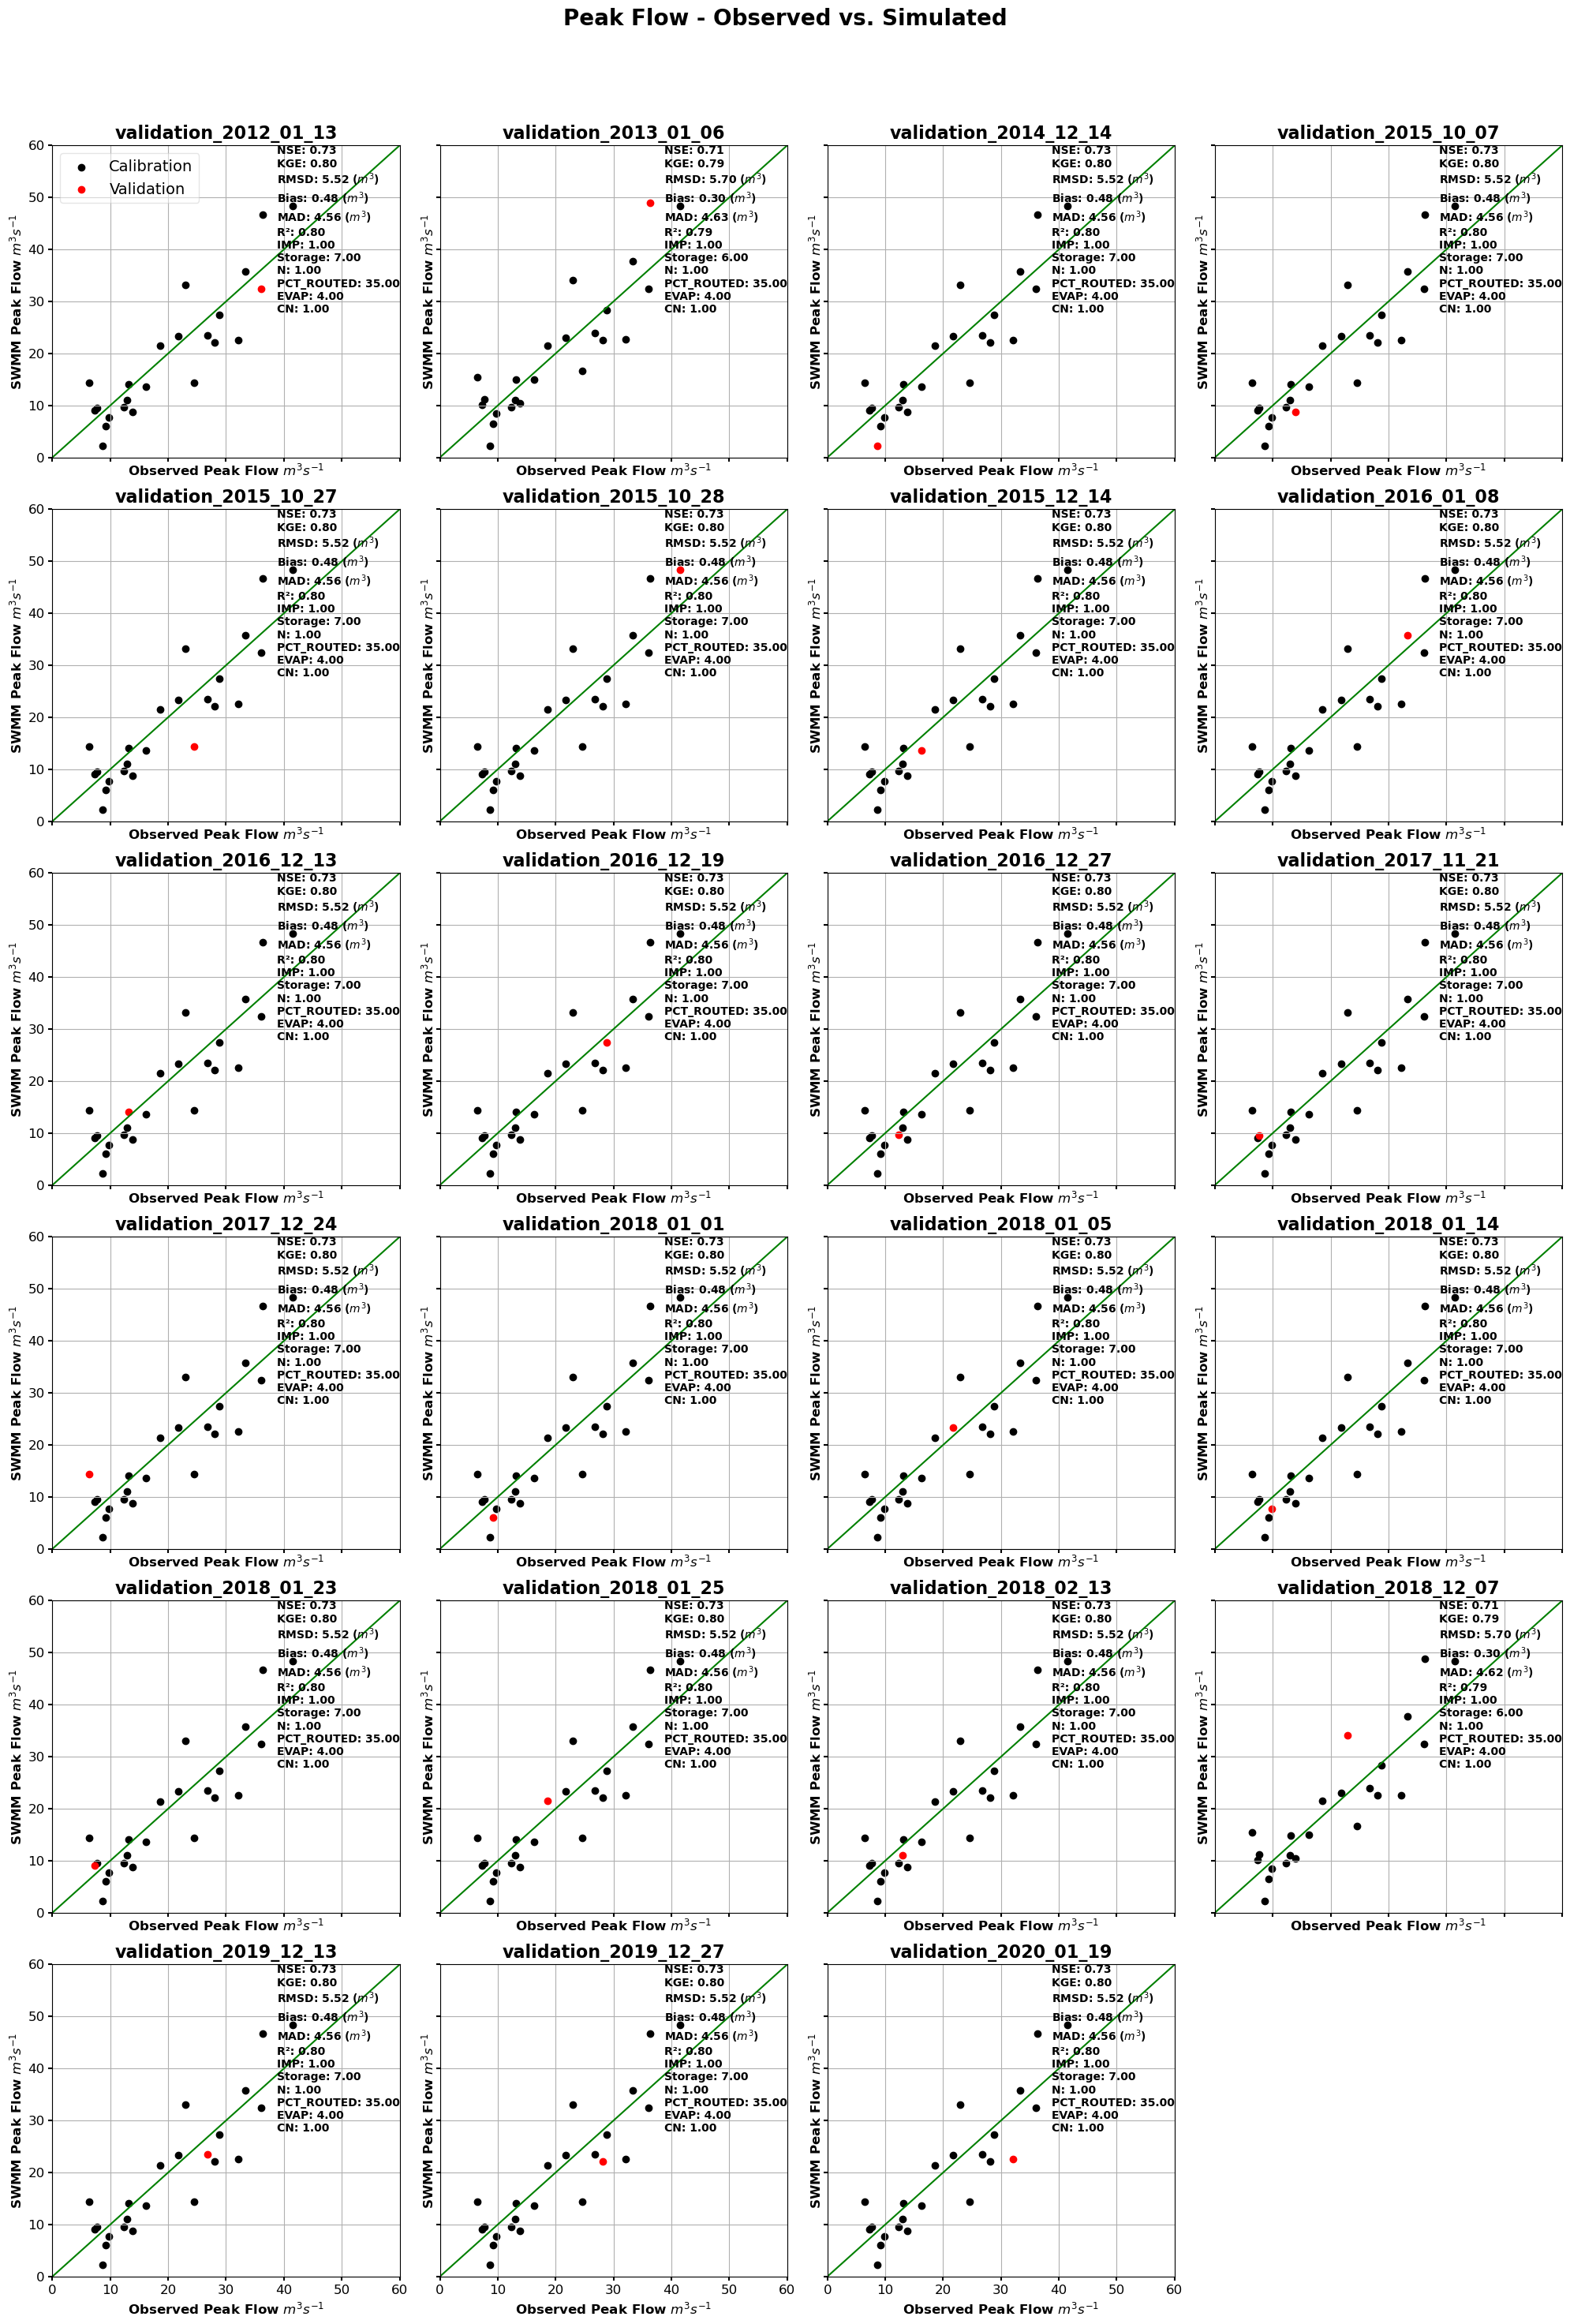

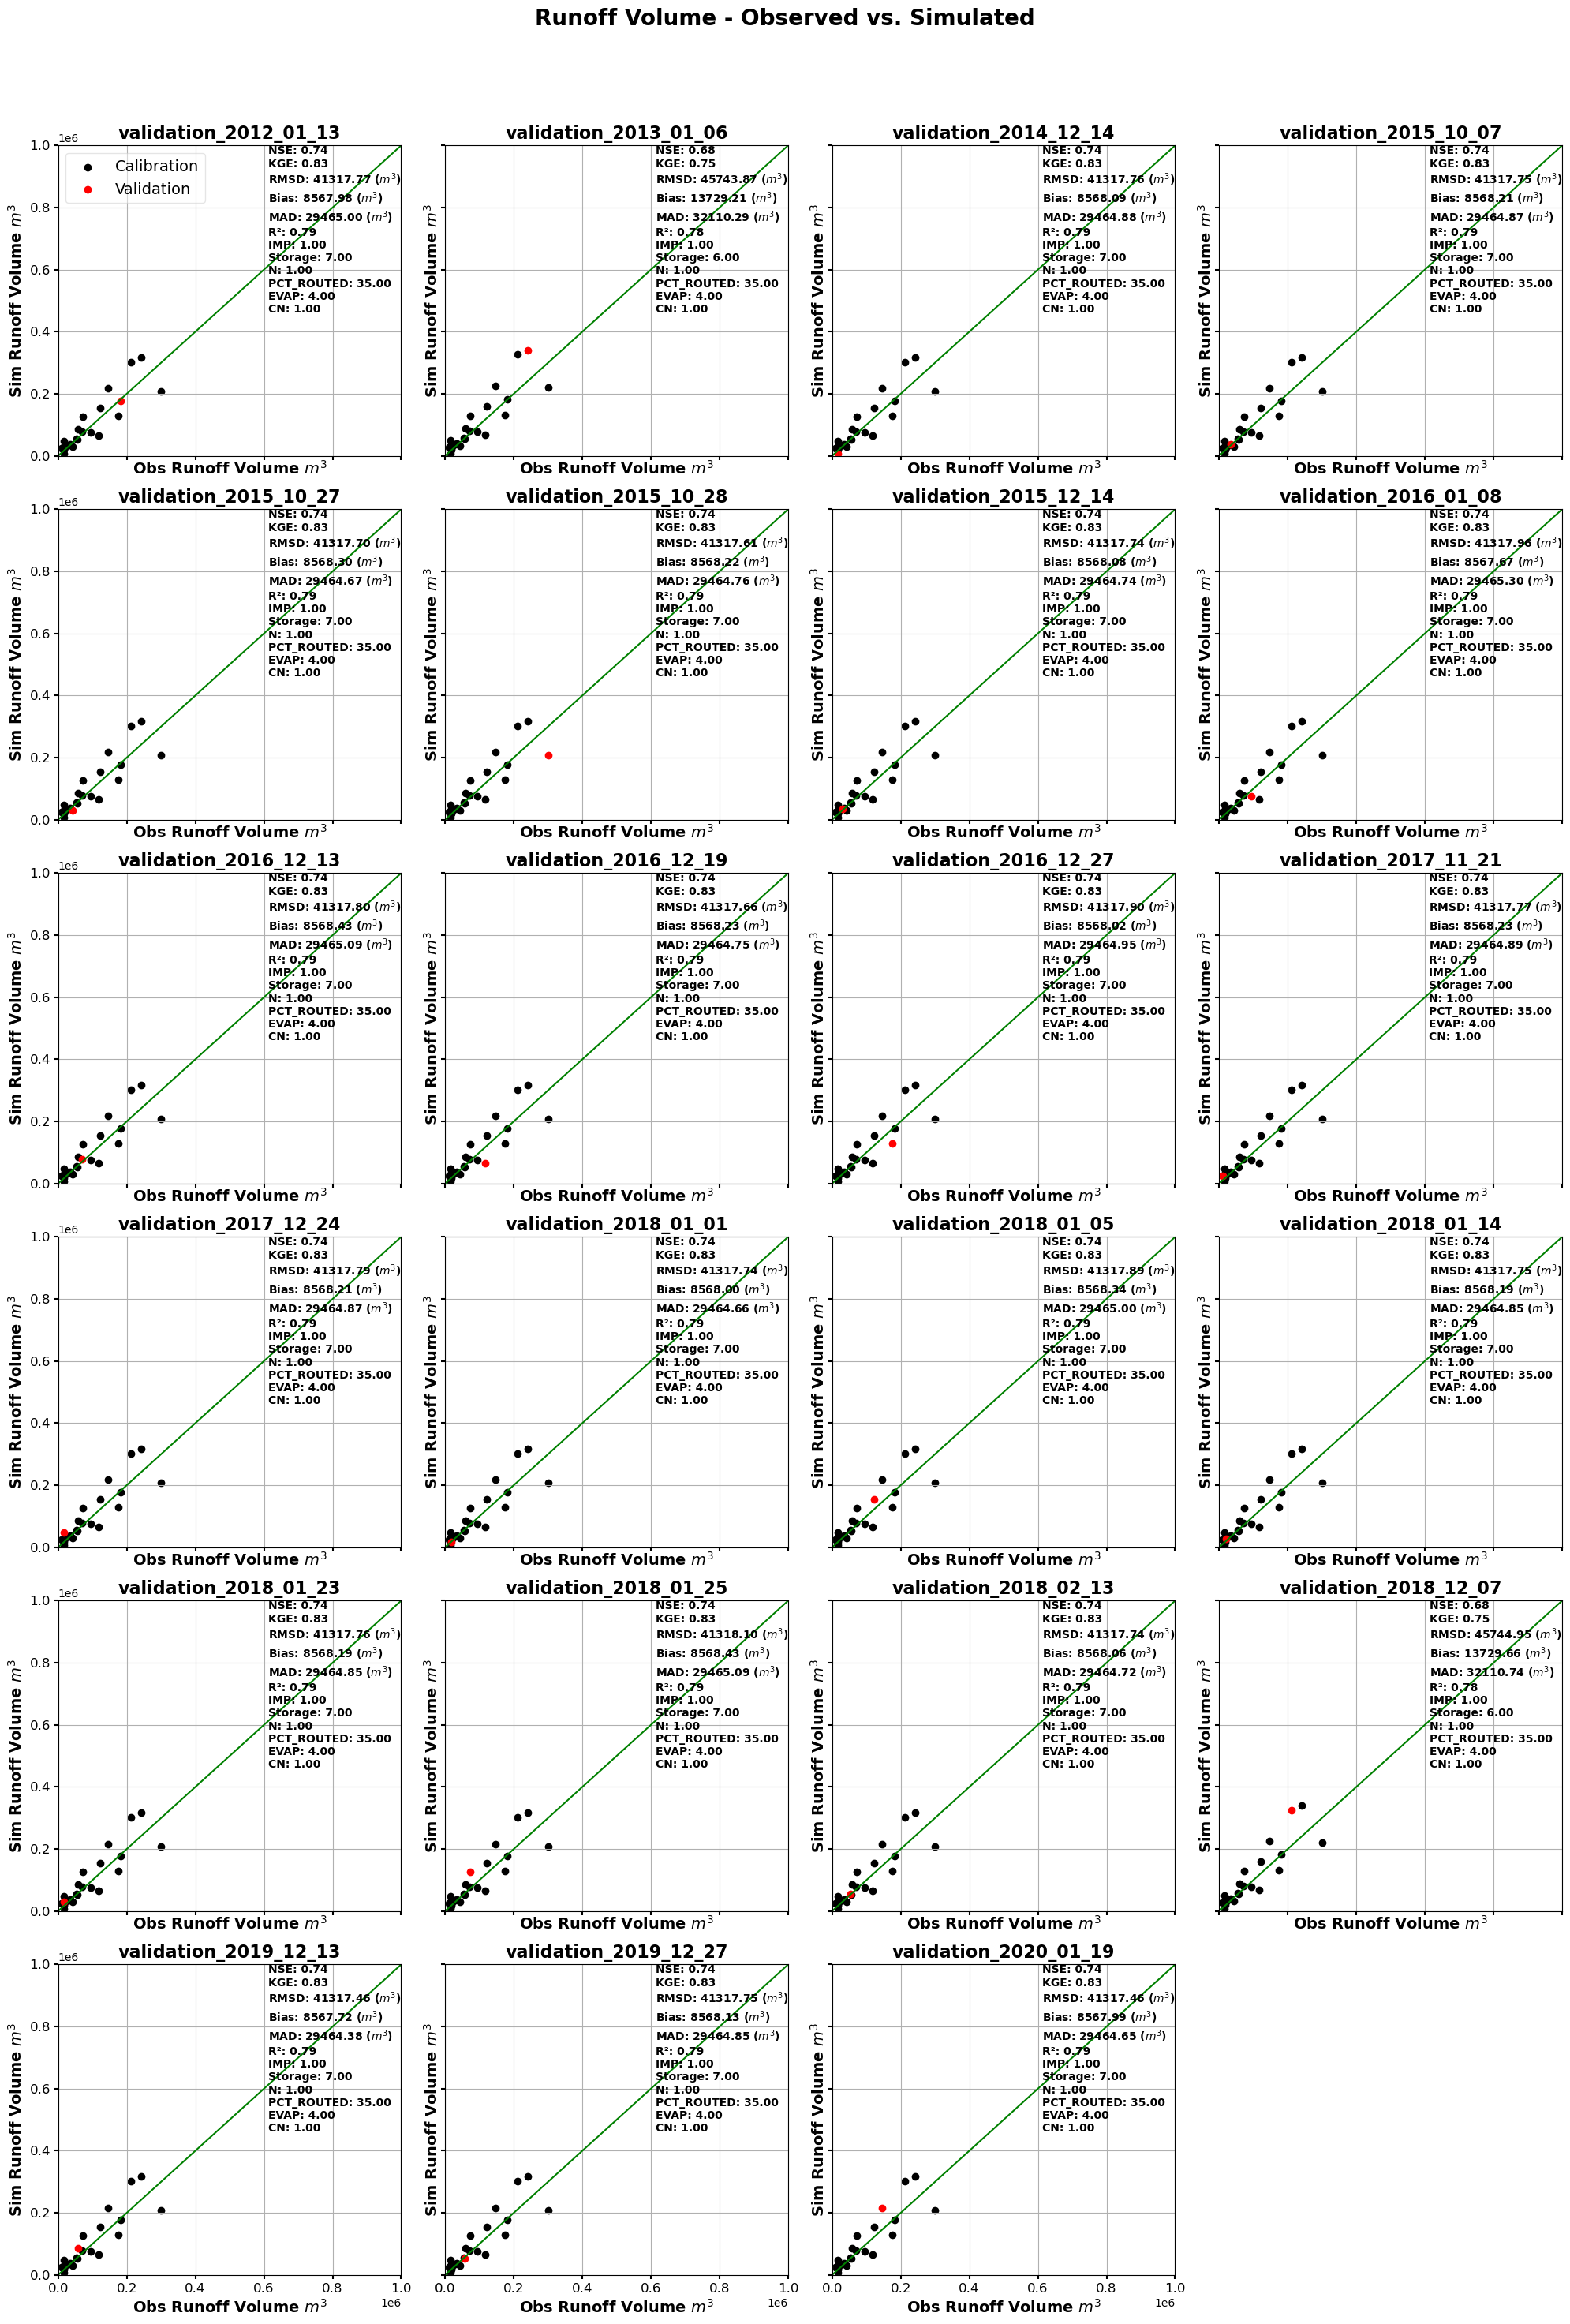

In [28]:
# Calculate the number of rows and columns in the subplot grid
num_plots = len(cross_validation_dict)
num_cols = 4
num_rows = math.ceil(num_plots / num_cols)

fig1, axs1 = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5), sharex=True, sharey=True)
fig2, axs2 = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5), sharex=True, sharey=True)

# Add more space between subplots
plt.subplots_adjust(hspace=0.5)

axs1 = axs1.flatten()
axs2 = axs2.flatten()

# Iterate through each cross-validation iteration
for index, cross_val in enumerate(cross_validation_dict.keys()):
    cali_total_df, cali_swmm_hydrograph_df, cali_obs_hydrograph_df = cross_validation_dict[cross_val][:3]
    vali_total_df, vali_swmm_hydrograph_df, vali_OBS_hydrograph_df = cross_validation_dict[cross_val][5:8]
    cali_total_df[factors_cols] = cali_total_df[factors_cols].apply(lambda x: x.round(2))
    
    # Selecting the OPTIMUM FACTORS
    imp_factor, storage_factor, width_factor, n_factor, pct_zero_factor, cn_factor, pct_routed_factor, evap_factor = [
        (cross_validation_dict[cross_val][4][(col)].round(2)) for col in factors_cols
    ]
    
    cons_factors_df = cali_total_df.loc[
        (cali_total_df.loc[:, ('Factors', 'IMP')] == imp_factor) &
        (cali_total_df.loc[:, ('Factors', 'Storage')] == storage_factor) &
        (cali_total_df.loc[:, ('Factors', 'Width')] == width_factor) &
        (cali_total_df.loc[:, ('Factors', 'N')] == n_factor) &
        (cali_total_df.loc[:, ('Factors', 'PCT_ZERO')] == pct_zero_factor) &
        (cali_total_df.loc[:, ('Factors', 'CN')] == cn_factor) &
        (cali_total_df.loc[:, ('Factors', 'PCT_ROUTED')] == pct_routed_factor) &
        (cali_total_df.loc[:, ('Factors', 'EVAP')] == evap_factor)
    ]
   
    # Calibration data: Peak runoff values
    cali_max_obs_runoff = cali_obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
    cali_max_swmm_runoff = cons_factors_df.loc[:, pd.IndexSlice[:, ['Max Runoff']]].values.flatten()
    
    # Validation data: Peak runoff values
    vali_max_obs_runoff = vali_OBS_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
    vali_max_swmm_runoff = vali_total_df.loc[:, pd.IndexSlice[:, ['Max Runoff']]].values.flatten()
    
    ax1 = axs1[index] ; ax2 = axs2[index]
    
    # PLOT 1: Peak flow obs vs. SWMM
    x_min_limit = 0 ; x_max_limit = 60 ; y_min_limit = 0 ; y_max_limit = 60
    
    ax1.scatter(cali_max_obs_runoff, cali_max_swmm_runoff, color='black', label='Calibration')
    ax1.scatter(vali_max_obs_runoff, vali_max_swmm_runoff, color='red', label='Validation')
    ax1.plot([x_min_limit, x_max_limit], [x_min_limit, x_max_limit], color='green')
    
    objectives = calculate_objectives(
        np.concatenate((vali_max_obs_runoff.to_numpy(), cali_max_obs_runoff.to_numpy()), axis=0),
        np.concatenate((vali_max_swmm_runoff, cali_max_swmm_runoff))
    )
    
    kge = objectives['kge'][0]
    nse = objectives['nse']
    rmsd = objectives['rmsd']
    bias = objectives['bias']
    mad = objectives['mad']
    r_squared = objectives['r_squared']
    
    text_lines = [
        f'NSE: {nse:.2f}',
        f'KGE: {kge:.2f}',
        f'RMSD: {rmsd:.2f} ($m^3$)',
        f'Bias: {bias:.2f} ($m^3$)',
        f'MAD: {mad:.2f} ($m^3$)',
        f'R²: {r_squared:.2f}',
        f'IMP: {imp_factor:.2f}',
        f'Storage: {storage_factor:.2f}',
        f'N: {n_factor:.2f}',
        f'PCT_ROUTED: {pct_routed_factor:.2f}',
        f'EVAP: {evap_factor:.2f}',
        f'CN: {cn_factor:.2f}'
    ]

    combined_text = '\n'.join(text_lines)
    ax1.text(x_max_limit, y_max_limit, combined_text, fontsize=10, fontweight='bold', ha='right', va='top', multialignment='left')
    ax1.set_xlabel('Observed Peak Flow $m^{3}s^{-1}$', fontsize=12, fontweight='bold')
    ax1.set_ylabel('SWMM Peak Flow $m^{3}s^{-1}$', fontsize=12, fontweight='bold')
    ax1.set_title(cross_val, fontsize=16, fontweight='bold')
    ax1.set_xlim(x_min_limit, x_max_limit)
    ax1.set_ylim(y_min_limit, y_max_limit)
    ax1.grid(True)
    ax1.tick_params(axis='both', labelsize=12, width=1.5)
  
    # ---------------------------------Plot 2: Total storm volume obs vs. SWMM ----------------------------------------
    x_min_limit = 0 ; x_max_limit =10**6 ; y_min_limit = 0 ; y_max_limit =10**6
    
    # Calibration data: Volume values
    cali_total_storm_vol_swmm = cons_factors_df.loc[:, pd.IndexSlice[:, ['Total Volume']]].values.flatten() * 5 * 60
    cali_total_storm_vol_obs = cali_obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60
    
    # Validation data: Volume values
    vali_total_storm_vol_swmm = vali_total_df.loc[:, pd.IndexSlice[:, ['Total Volume']]].values.flatten() * 5 * 60
    vali_total_storm_vol_obs = vali_OBS_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60
    
    ax2.scatter(cali_total_storm_vol_obs, cali_total_storm_vol_swmm, color='black', label='Calibration')
    ax2.scatter(vali_total_storm_vol_obs, vali_total_storm_vol_swmm, color='red', label='Validation')
    ax2.plot([x_min_limit, x_max_limit], [x_min_limit, x_max_limit], color='green')
    
    objectives = calculate_objectives(
        np.concatenate((cali_total_storm_vol_obs.to_numpy(), vali_total_storm_vol_obs.to_numpy()), axis=0),
        np.concatenate((cali_total_storm_vol_swmm, vali_total_storm_vol_swmm))
    )
    
    kge = objectives['kge'][0]
    nse = objectives['nse']
    rmsd = objectives['rmsd']
    bias = objectives['bias']
    mad = objectives['mad']
    r_squared = objectives['r_squared']
    
    text_lines = [
        f'NSE: {nse:.2f}',
        f'KGE: {kge:.2f}',
        f'RMSD: {rmsd:.2f} ($m^3$)',
        f'Bias: {bias:.2f} ($m^3$)',
        f'MAD: {mad:.2f} ($m^3$)',
        f'R²: {r_squared:.2f}',
        f'IMP: {imp_factor:.2f}',
        f'Storage: {storage_factor:.2f}',
        f'N: {n_factor:.2f}',
        f'PCT_ROUTED: {pct_routed_factor:.2f}',
        f'EVAP: {evap_factor:.2f}',
        f'CN: {cn_factor:.2f}'
    ]
    
    combined_text = '\n'.join(text_lines)
    ax2.text(x_max_limit, y_max_limit, combined_text, fontsize=10, fontweight='bold', ha='right', va='top', multialignment='left')
    ax2.set_xlabel('Obs Runoff Volume $m^{3}$', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Sim Runoff Volume $m^{3}$', fontsize=14, fontweight='bold')
    ax2.set_title(cross_val, fontsize=16, fontweight='bold')
    ax2.set_xlim(x_min_limit, x_max_limit)
    ax2.set_ylim(y_min_limit, y_max_limit)
    ax2.grid(True)
    ax2.tick_params(axis='both', labelsize=12, width=1.5)
    
# Remove empty subplots
for i in range(num_plots, num_rows * num_cols):
    fig1.delaxes(axs1[i])
    fig2.delaxes(axs2[i])

# Add legends
axs1[0].legend(fancybox=True, framealpha=0.5, loc='upper left', fontsize=14)
axs2[0].legend(fancybox=True, framealpha=0.5, loc='upper left', fontsize=14)

# Set titles and layout
fig1.suptitle('Peak Flow - Observed vs. Simulated', fontsize=20, fontweight='bold')
fig2.suptitle('Runoff Volume - Observed vs. Simulated', fontsize=20, fontweight='bold')
fig1.tight_layout(rect=[0, 0, 1, 0.95], h_pad=1.0)
fig2.tight_layout(rect=[0, 0, 1, 0.95], h_pad=1.0)

# Save figures
fig1.savefig(os.path.join(folder_path, 'peak_scat.png'))
fig2.savefig(os.path.join(folder_path, 'vol_scat.png'))

plt.show()


In [29]:
def calculate_objectives(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE), Root Mean Square Deviation (RMSD), bias, Mean Absolute Deviation (MAD), and R-squared (R^2) between observed and simulated data.

    Parameters:
    observed (pandas.core.series.Series): Series containing the observed data.
    simulated (pandas.core.series.Series): Series containing the simulated data.

    Returns:
    nse (float): Nash-Sutcliffe Efficiency (NSE) value.
    rmsd (float): Root Mean Square Deviation (RMSD) value.
    bias (float): Bias value.
    mad (float): Mean Absolute Deviation (MAD) value.
    r_squared (float): R-squared (R^2) value.
    """
    if not isinstance(observed, np.ndarray):
        observed = observed.to_numpy()
    if not isinstance(simulated, np.ndarray):
        simulated = simulated.to_numpy()

    kge_tuple = he.evaluator(he.kge, simulated, observed)
    kge = kge_tuple[0]
    
    nse_tuple = he.evaluator(he.nse, simulated, observed)
    nse = nse_tuple[0]  
    
    rmsd = np.sqrt(np.mean((observed - simulated) ** 2))
    bias = np.mean(simulated - observed)
    mad = np.mean(np.abs(simulated - observed))
    
    rel_bias = (np.mean(simulated - observed)/np.mean(observed))*100
    rel_rmsd = ((np.sqrt(np.mean((observed - simulated) ** 2)))/np.mean(observed))*100
    
    observed = observed.flatten()  # Flatten the observed array to 1D
    simulated = simulated.flatten()  # Flatten the simulated array to 1D

    pearson_r = scipy.stats.pearsonr(observed, simulated)
    r_squared = pearson_r[0]**2
    
    objectives = {
        'kge': kge,
        'nse': nse,
        'rmsd': rmsd,
        'bias': bias,
        'rel_bias': rel_bias,
        'rel_rmsd': rel_rmsd,        
        'mad': mad,
        'r_squared': r_squared
    }
    
    return objectives

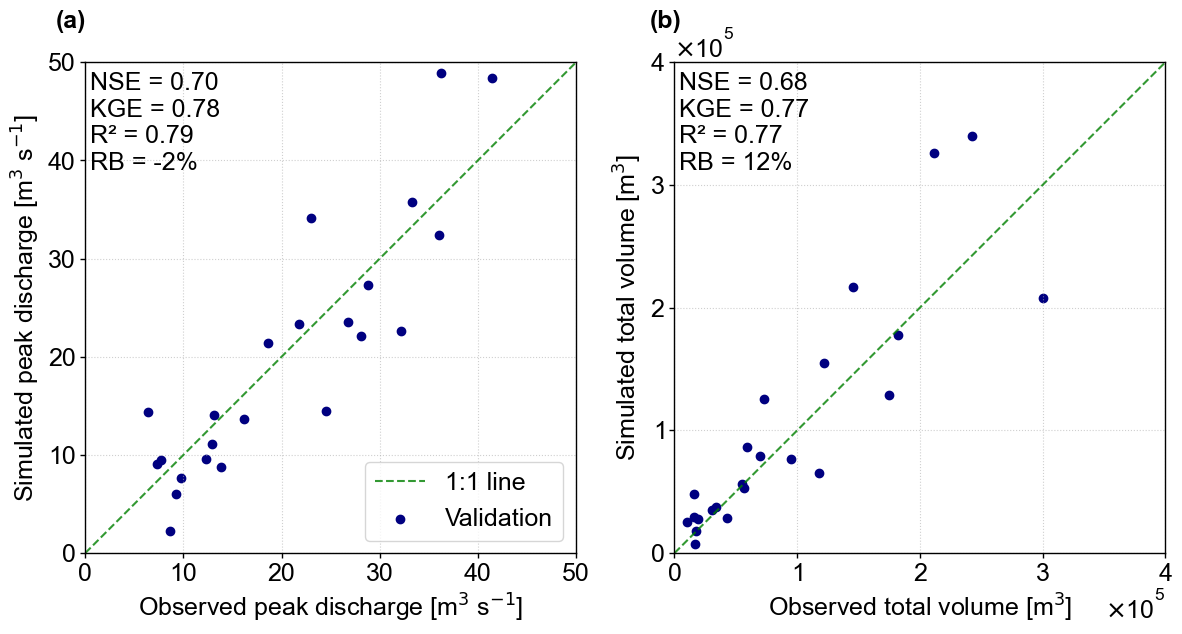

In [30]:
# Define standardized font properties
TITLE_FONT = {'fontsize': 18, 'fontweight': 'bold'}
LABEL_FONT = {'fontsize': 18, 'fontweight': 'normal'}
TICK_FONT = {'fontsize': 18}
STATS_FONT = {'fontsize': 18, 'fontweight': 'normal'}
SUBPLOT_LABEL_FONT = {'fontsize': 18, 'fontweight': 'bold'}

def format_statistics(objectives):
    """Format statistical metrics with consistent notation."""
    return '\n'.join([
        f'NSE = {objectives["nse"]:.2f}',
        f'KGE = {objectives["kge"][0]:.2f}',
        f'R² = {objectives["r_squared"]:.2f}',
        f'RB = {objectives["rel_bias"]:.0f}%'
    ])

# Initialize empty lists to store the 1D arrays for each cross-validation fold
vali_max_obs_runoff_list = []
vali_max_swmm_runoff_list = []
vali_volume_obs_runoff_list = []
vali_volume_swmm_runoff_list = []

for index, cross_val in enumerate(cross_validation_dict.keys()):
    cali_total_df, cali_swmm_hydrograph_df, cali_obs_hydrograph_df = cross_validation_dict[cross_val][:3]
    vali_total_df, vali_swmm_hydrograph_df, vali_OBS_hydrograph_df = cross_validation_dict[cross_val][5:8]
    cali_total_df[factors_cols] = cali_total_df[factors_cols].apply(lambda x: x.round(2))

    # Selecting the OPTIMUM FACTORS
    imp_factor, storage_factor, width_factor, n_factor, pct_zero_factor, cn_factor, pct_routed_factor, evap_factor = [
        (cross_validation_dict[cross_val][4][col].round(2)) for col in factors_cols]
    
    cons_factors_df = cali_total_df.loc[ 
        (cali_total_df.loc[:, ('Factors', 'IMP')] == imp_factor) &
        (cali_total_df.loc[:, ('Factors', 'Storage')] == storage_factor) &
        (cali_total_df.loc[:, ('Factors', 'Width')] == width_factor) &
        (cali_total_df.loc[:, ('Factors', 'N')] == n_factor) &
        (cali_total_df.loc[:, ('Factors', 'PCT_ZERO')] == pct_zero_factor) &
        (cali_total_df.loc[:, ('Factors', 'PCT_ROUTED')] == pct_routed_factor) &
        (cali_total_df.loc[:, ('Factors', 'EVAP')] == evap_factor)]

    # Validation data
    vali_max_obs_runoff = vali_OBS_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
    vali_max_obs_runoff_list.append(vali_max_obs_runoff)
    vali_max_swmm_runoff = vali_total_df.loc[:, pd.IndexSlice[:, ['Max Runoff']]].values.flatten()
    vali_max_swmm_runoff_list.append(vali_max_swmm_runoff)

    vali_total_storm_vol_swmm = vali_total_df.loc[:, pd.IndexSlice[:, ['Total Volume']]].values.flatten() * 5 * 60
    vali_volume_swmm_runoff_list.append(vali_total_storm_vol_swmm)
    vali_total_storm_vol_obs = vali_OBS_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60
    vali_volume_obs_runoff_list.append(vali_total_storm_vol_obs)

# Convert the lists to NumPy arrays
vali_max_obs_runoff = np.concatenate(vali_max_obs_runoff_list)
vali_max_swmm_runoff = np.concatenate(vali_max_swmm_runoff_list)
vali_volume_obs_runoff = np.concatenate(vali_volume_obs_runoff_list)
vali_volume_swmm_runoff = np.concatenate(vali_volume_swmm_runoff_list)

# Set figure properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.0
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Peak flow validation
x_min_limit = 0; x_max_limit = 50; y_min_limit = 0; y_max_limit = 50
axs[0].scatter(vali_max_obs_runoff, vali_max_swmm_runoff, color='navy', label='Validation')
axs[0].plot([x_min_limit, x_max_limit], [x_min_limit, x_max_limit], color='green', linestyle='--', alpha=0.8, label='1:1 line')

objectives = calculate_objectives(vali_max_obs_runoff, vali_max_swmm_runoff)
text_lines = format_statistics(objectives)

axs[0].text(x_max_limit * 0.01, y_max_limit * 0.98, text_lines, **STATS_FONT, ha='left', va='top')
axs[0].set_xlabel('Observed peak discharge [m$^3$ s$^{-1}$]', **LABEL_FONT)
axs[0].set_ylabel('Simulated peak discharge [m$^3$ s$^{-1}$]', **LABEL_FONT)
axs[0].set_xlim(x_min_limit, x_max_limit)
axs[0].set_ylim(y_min_limit, y_max_limit)
axs[0].grid(True, linestyle=':', alpha=0.6)
# Define standardized font properties
TICK_FONT = {'labelsize': 12}  # Changed from 'fontsize' to 'labelsize'
axs[0].tick_params(axis='both', labelsize=18, width=1.0)
axs[0].set_aspect('equal')
axs[0].legend(frameon=True, fontsize=18, loc='lower right')

# Add 'a' label for the left plot
axs[0].text(x_max_limit * -0.06, y_max_limit * 1.07, '(a)', **SUBPLOT_LABEL_FONT)

# Plot 2: Volume validation
x_min_limit = 0; x_max_limit = 4 * 10**5; y_min_limit = 0; y_max_limit = 4 * 10**5
axs[1].scatter(vali_volume_obs_runoff, vali_volume_swmm_runoff, color='navy', label='Validation')
axs[1].plot([x_min_limit, x_max_limit], [x_min_limit, x_max_limit], color='green', linestyle='--', alpha=0.8, label='1:1 line')

objectives = calculate_objectives(vali_volume_obs_runoff, vali_volume_swmm_runoff)
text_lines = format_statistics(objectives)

axs[1].text(x_max_limit * 0.01, y_max_limit * 0.98, text_lines, **STATS_FONT, ha='left', va='top')
axs[1].set_xlabel('Observed total volume [m$^3$]', **LABEL_FONT)
axs[1].set_ylabel('Simulated total volume [m$^3$]', **LABEL_FONT)
axs[1].set_xlim(x_min_limit, x_max_limit)
axs[1].set_ylim(y_min_limit, y_max_limit)
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].tick_params(axis='both',  labelsize=18, width=1.0)
axs[1].set_aspect('equal')
# axs[1].legend(frameon=False, fontsize=12, loc='lower right')

# Add 'b' label for the right plot
axs[1].text(x_max_limit * -0.05, y_max_limit * 1.07, '(b)', **SUBPLOT_LABEL_FONT)

# Format the total volume plot axis labels
axs[1].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1].xaxis.get_major_formatter().set_powerlimits((0, 0))
axs[1].yaxis.get_major_formatter().set_powerlimits((0, 0))

# Set tick intervals of 1 unit (1 * 10^5) for both axes
axs[1].xaxis.set_major_locator(MultipleLocator(1 * 10**5))
axs[1].yaxis.set_major_locator(MultipleLocator(1 * 10**5))

# Set larger font size for scientific notation (10^5)
axs[1].xaxis.offsetText.set_fontsize(18)
axs[1].yaxis.offsetText.set_fontsize(18)

plt.tight_layout()
plt.savefig(os.path.join(folder_path, 'validation_analysis.png'),
            bbox_inches='tight', dpi=600, format="png")

plt.show()

### Factors distribution

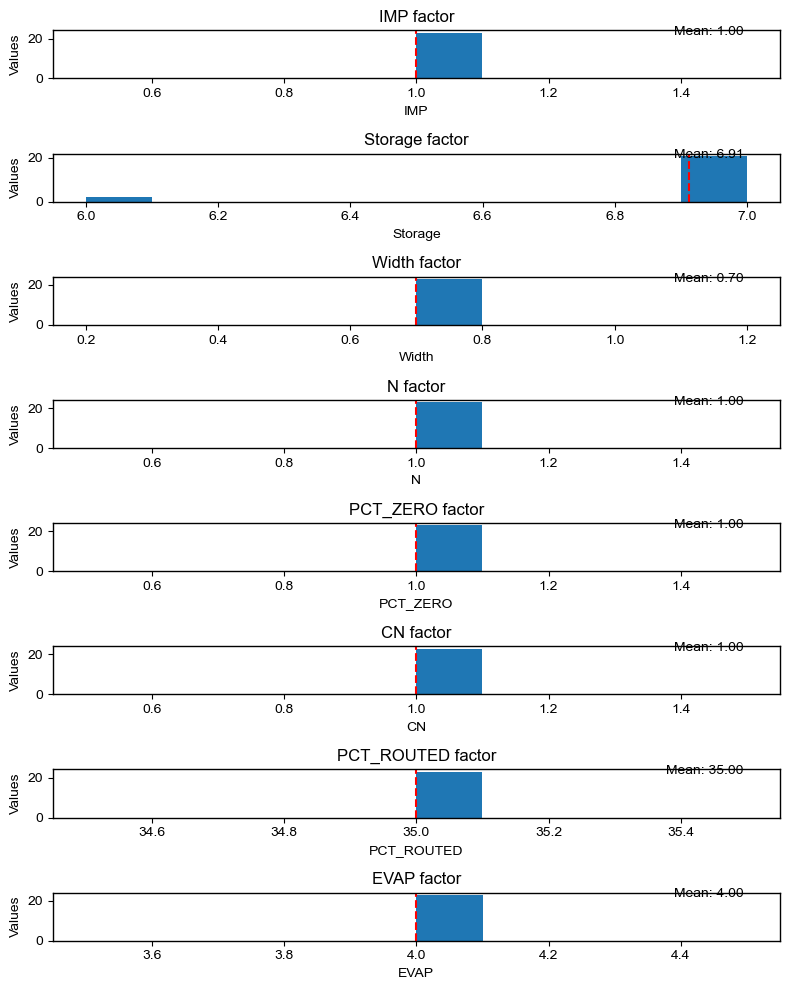

In [31]:
# factors_cols = [('Factors', 'IMP'), ('Factors', 'Storage'), ('Factors', 'Width'), ('Factors', 'N'), ('Factors', 'PCT_ZERO')]

# Create an empty DataFrame to store the merged data
validation_factors = pd.DataFrame()

# Iterate over the cross_validation_dict
for cross_val in cross_validation_dict.keys():
    # Get the specific DataFrame from the dictionary
    df = cross_validation_dict[cross_val][5][factors_cols]
    # Concatenate the DataFrame to the merged_df
    validation_factors = pd.concat([validation_factors, df])

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=len(factors_cols), figsize=(8, 10))

# Iterate over the columns and create separate box plots on subplots
for i, col in enumerate(validation_factors.columns):
    axes[i].hist(validation_factors[col])
    axes[i].set_xlabel(col[1])
    axes[i].set_ylabel('Values')
    axes[i].set_title(f'{col[1]} factor')

    # Calculate the mean value for the current column
    mean_value = validation_factors[col].mean()
    axes[i].axvline(x=mean_value, color='red', linestyle='--')
    # Add the mean value as text inside the subplot
    axes[i].text(0.95, 0.90, f'Mean: {mean_value:.2f}', transform=axes[i].transAxes, ha='right')
    
# Adjust the spacing between subplots
plt.tight_layout()
fig.savefig(os.path.join(folder_path, 'Factors_hist.png'))
plt.show()





## visualization

In [32]:
# Define the path and filename

path = r'D:\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, 'cross_validation_cali_dict_28catchments_without_conduit.pickle')

# Load the dictionary from the pickle file
with open(filename, 'rb') as file:
    cross_validation_dict = pickle.load(file)

In [33]:
def plot_param_scatter(cali_total_df, x_param, y_params):
    # Define the number of rows and columns for subplots
    num_rows = len(y_params) // 3 + (1 if len(y_params) % 3 != 0 else 0)
    num_cols = 3

    # Create subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 10))

    # Flatten the axs array if there's only one row or column
    if num_rows == 1 or num_cols == 1:
        axs = [axs]

    # Iterate over y_params and create scatter plots
    for i, param in enumerate(y_params):
#         print(x_param[1])
        y = cali_total_df[param]
        row = i // num_cols
        col = i % num_cols
        ax = axs[row][col]
        ax.scatter(cali_total_df[x_param], y)
        ax.set_xlabel(x_param[1], fontsize=14)  # Set x-axis label font size
        ax.set_ylabel(param[1], fontsize=14)  # Set y-axis label font size
        ax.set_title(f"{param[1]} vs {x_param[1]}", fontsize=14, fontweight='bold')  # Set subplot title font size and weight
        ax.tick_params(axis='both', which='major', labelsize=12)  # Set tick label font size

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()


## One-parameter scatter plot

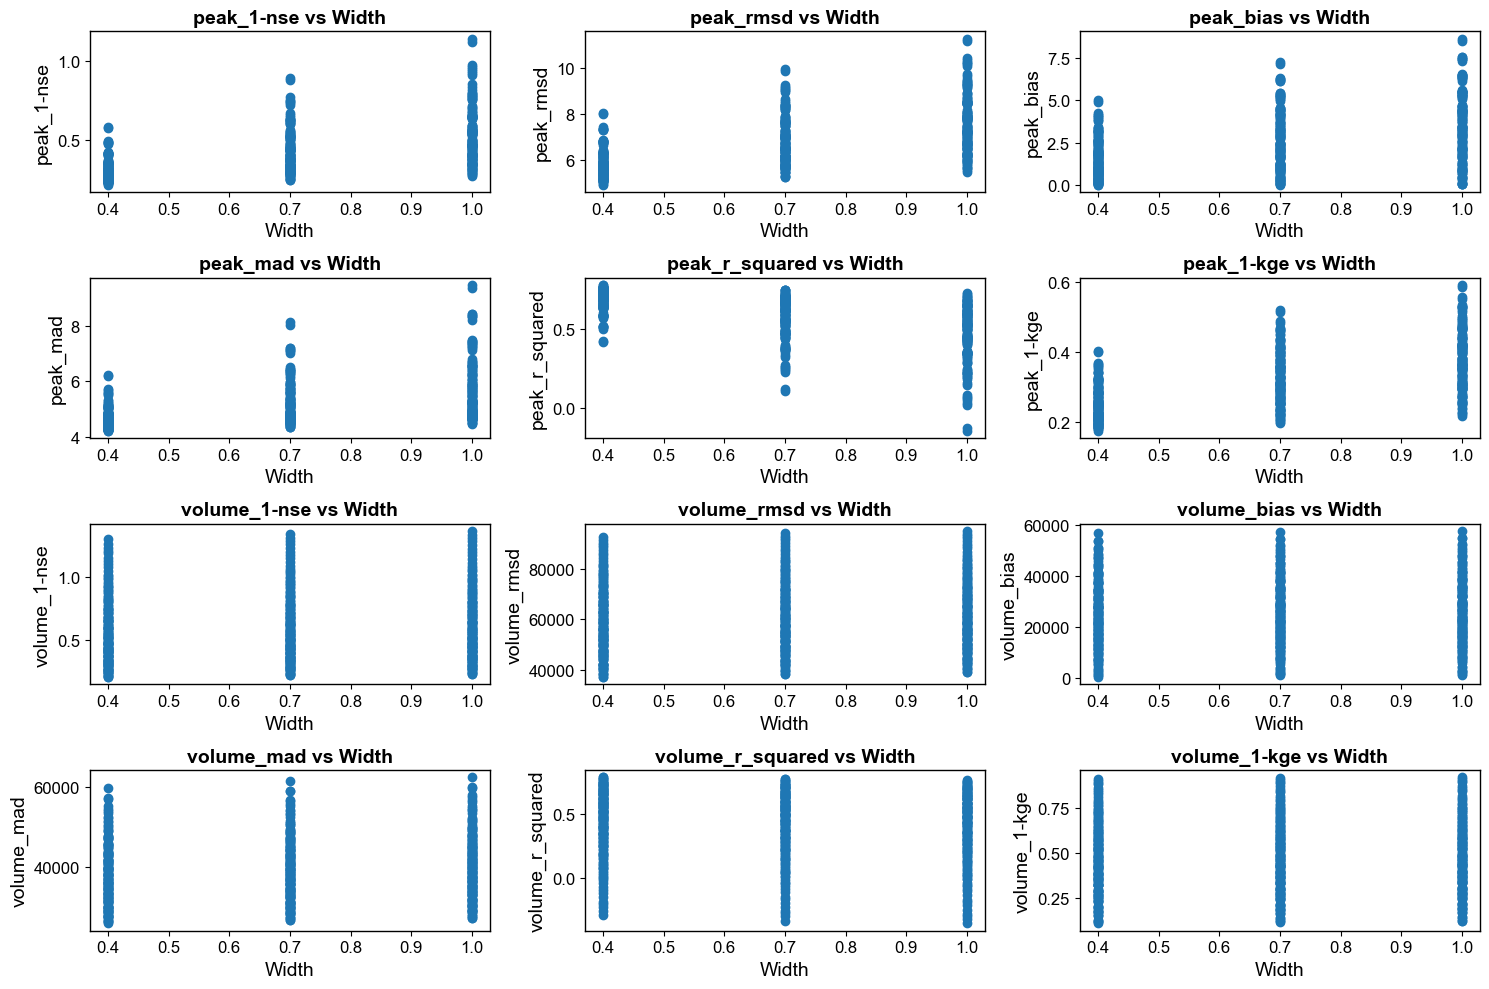

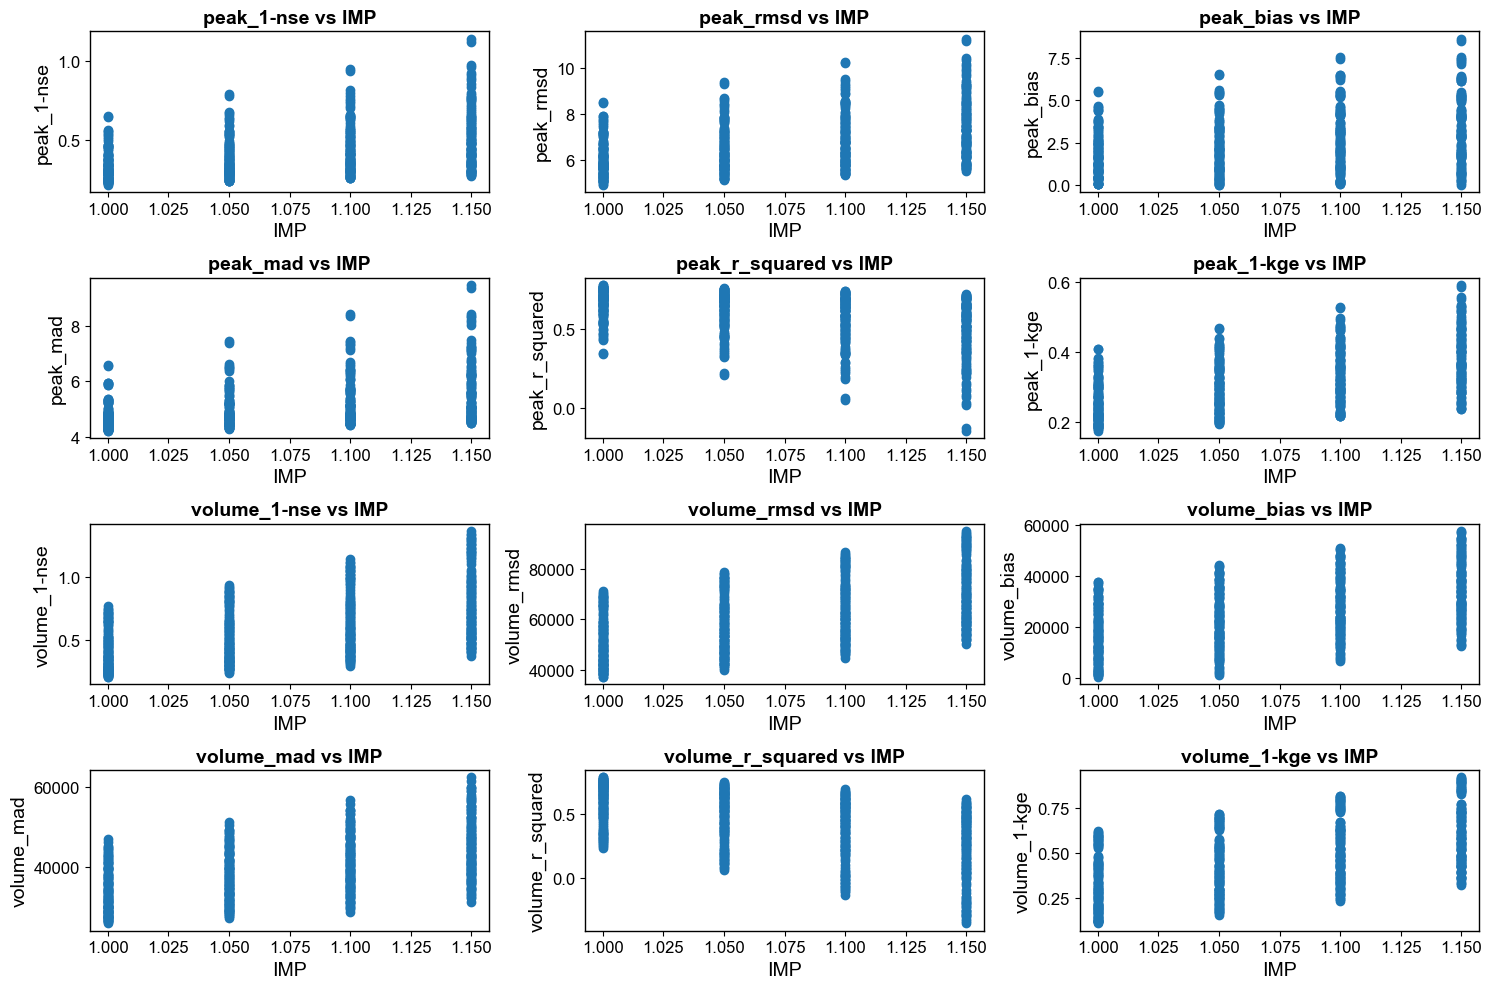

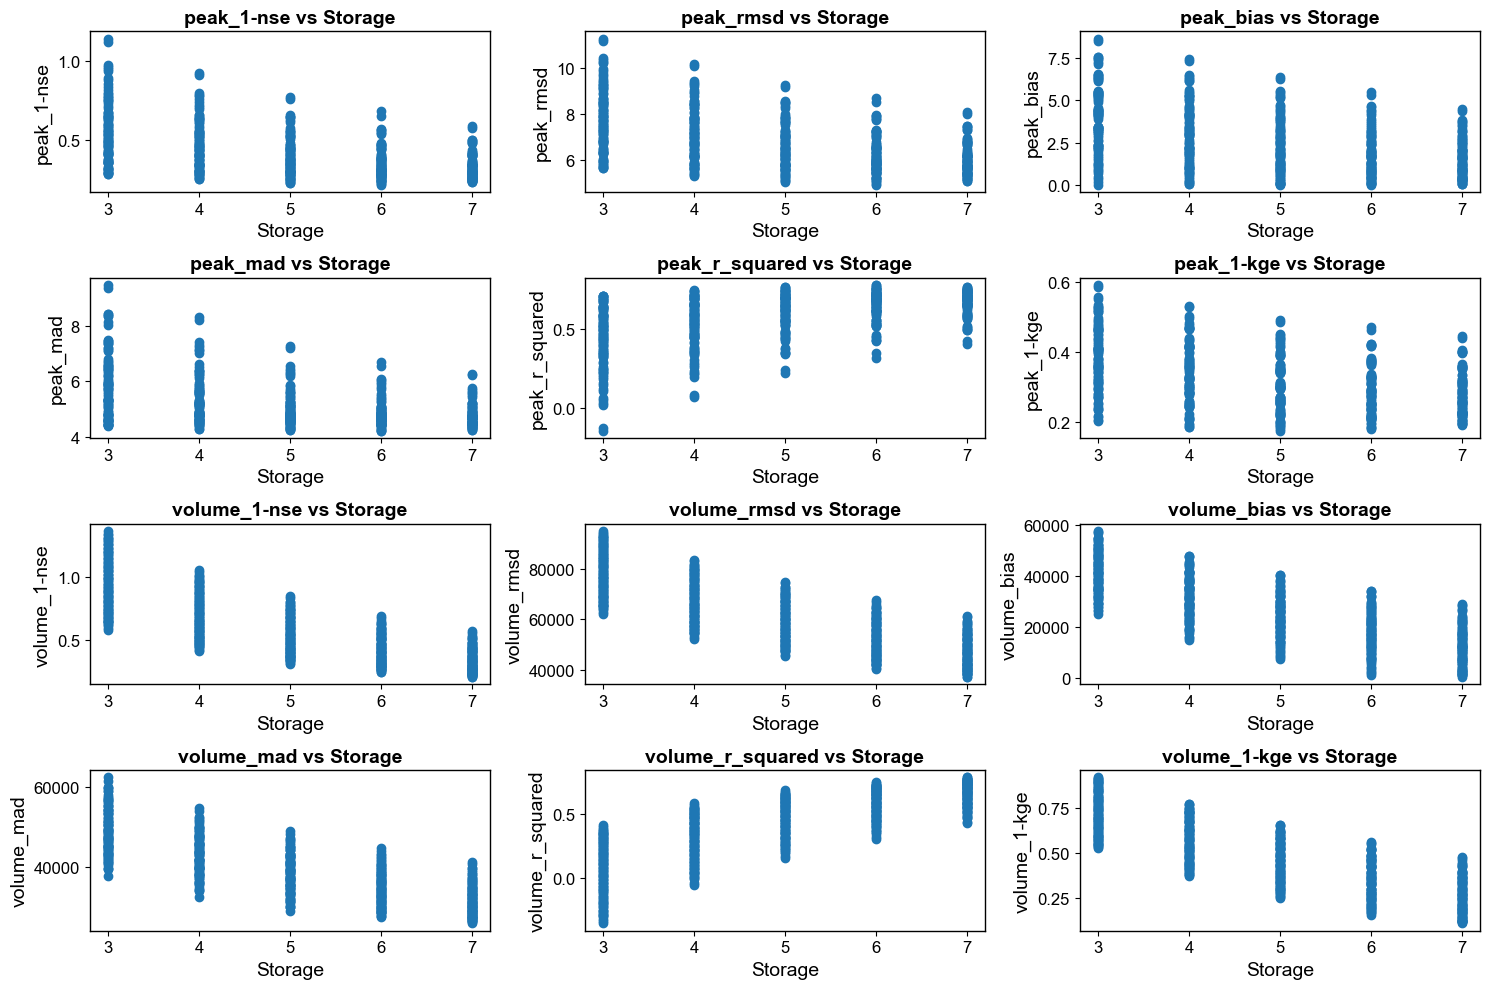

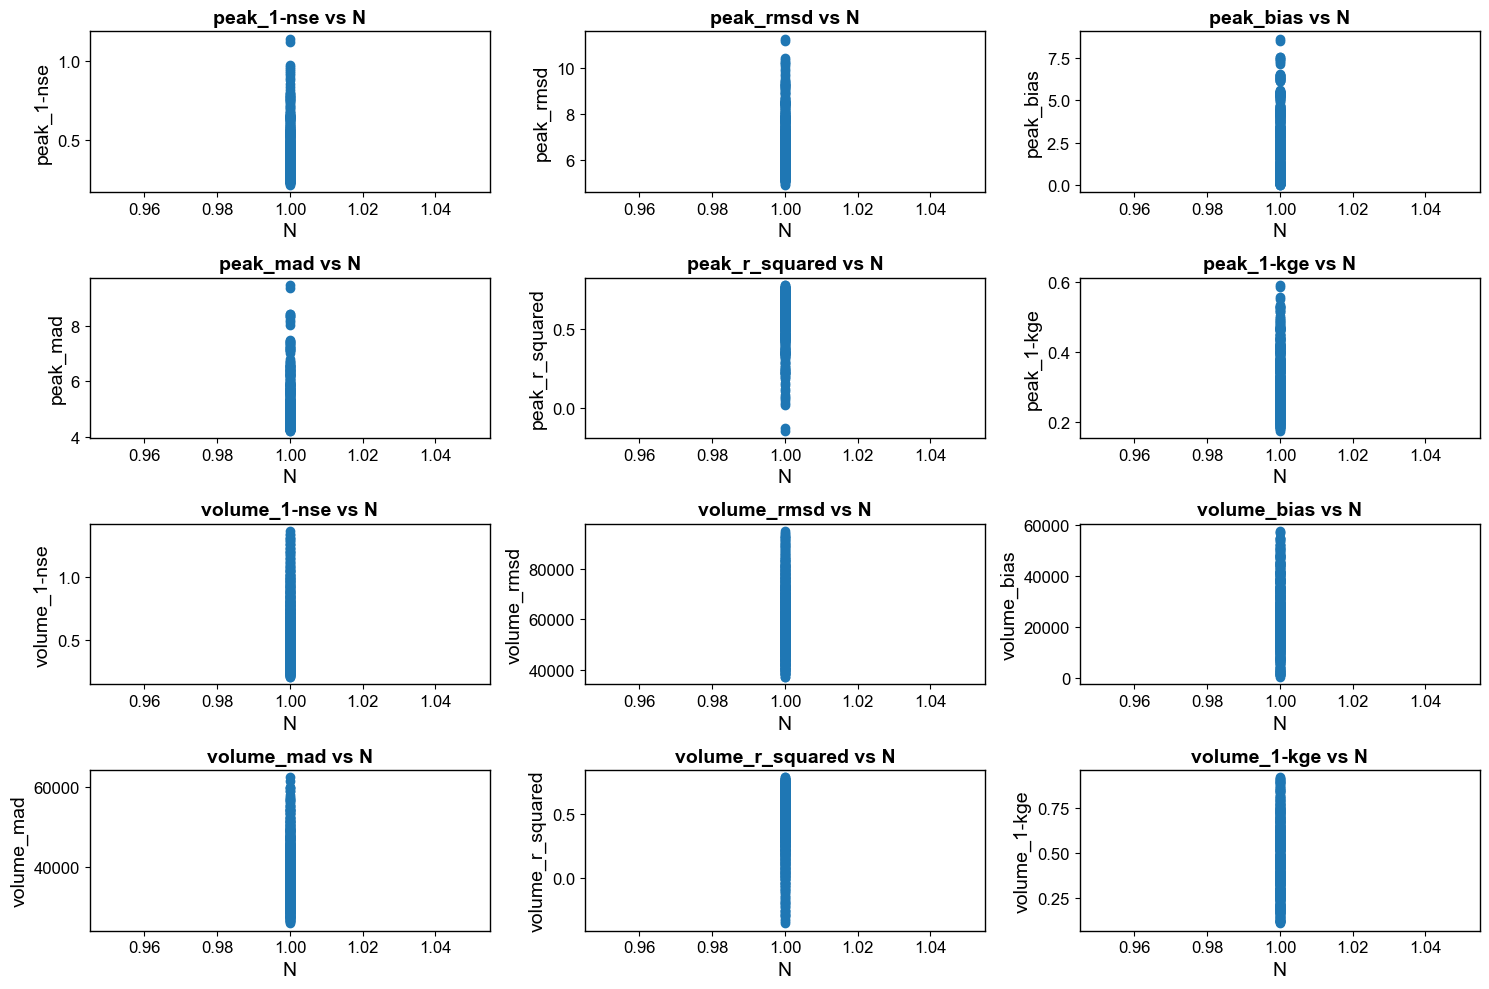

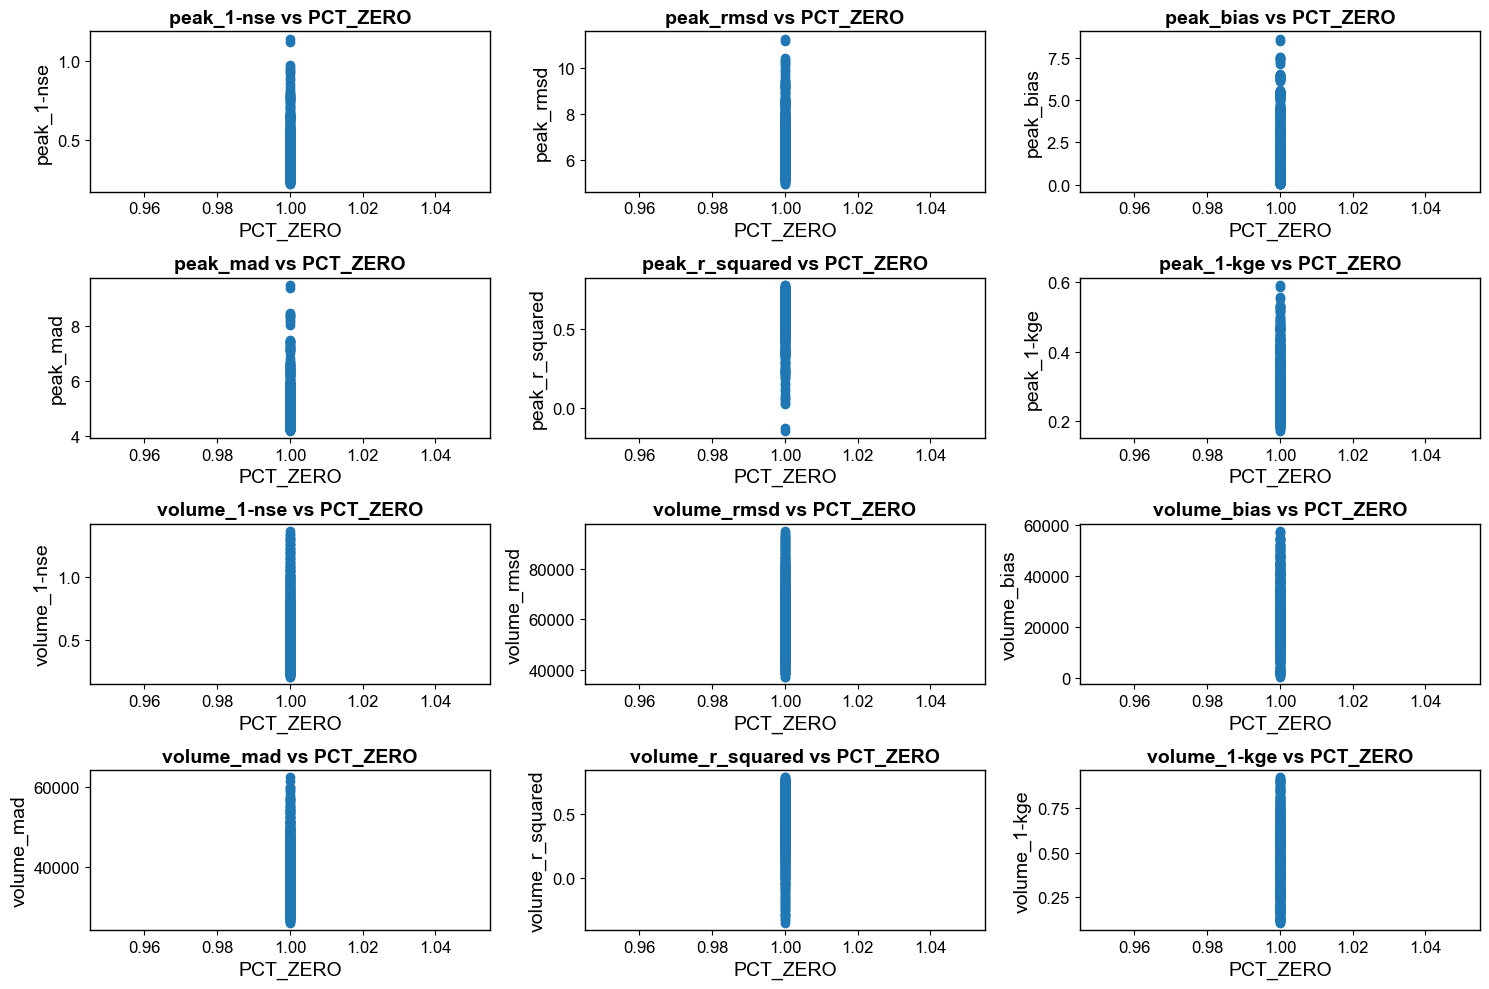

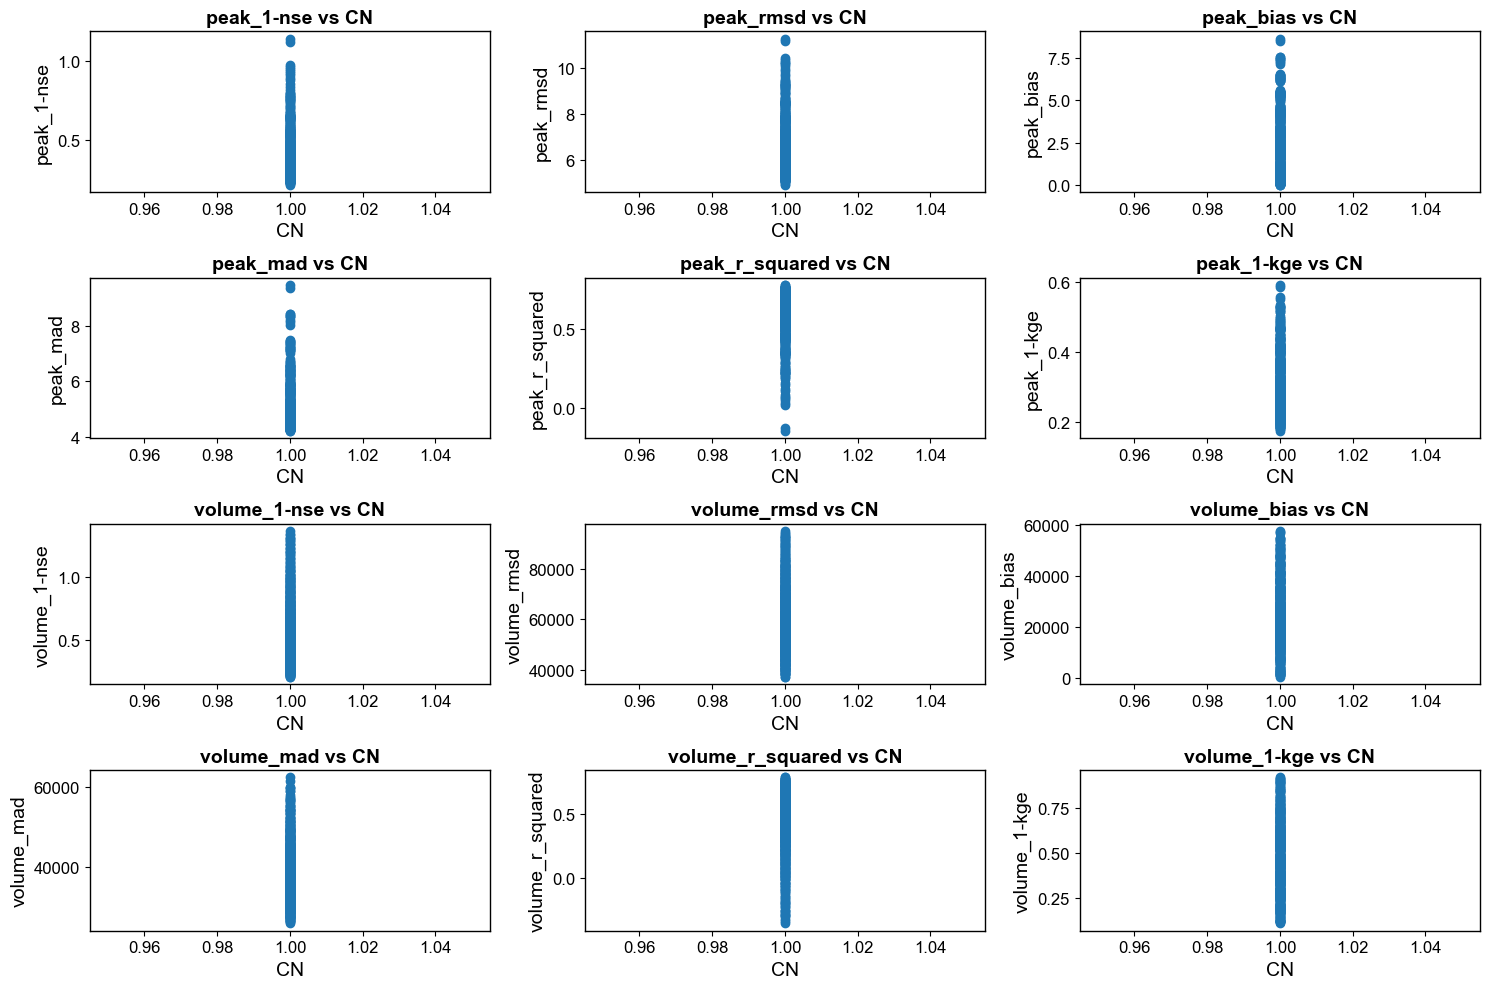

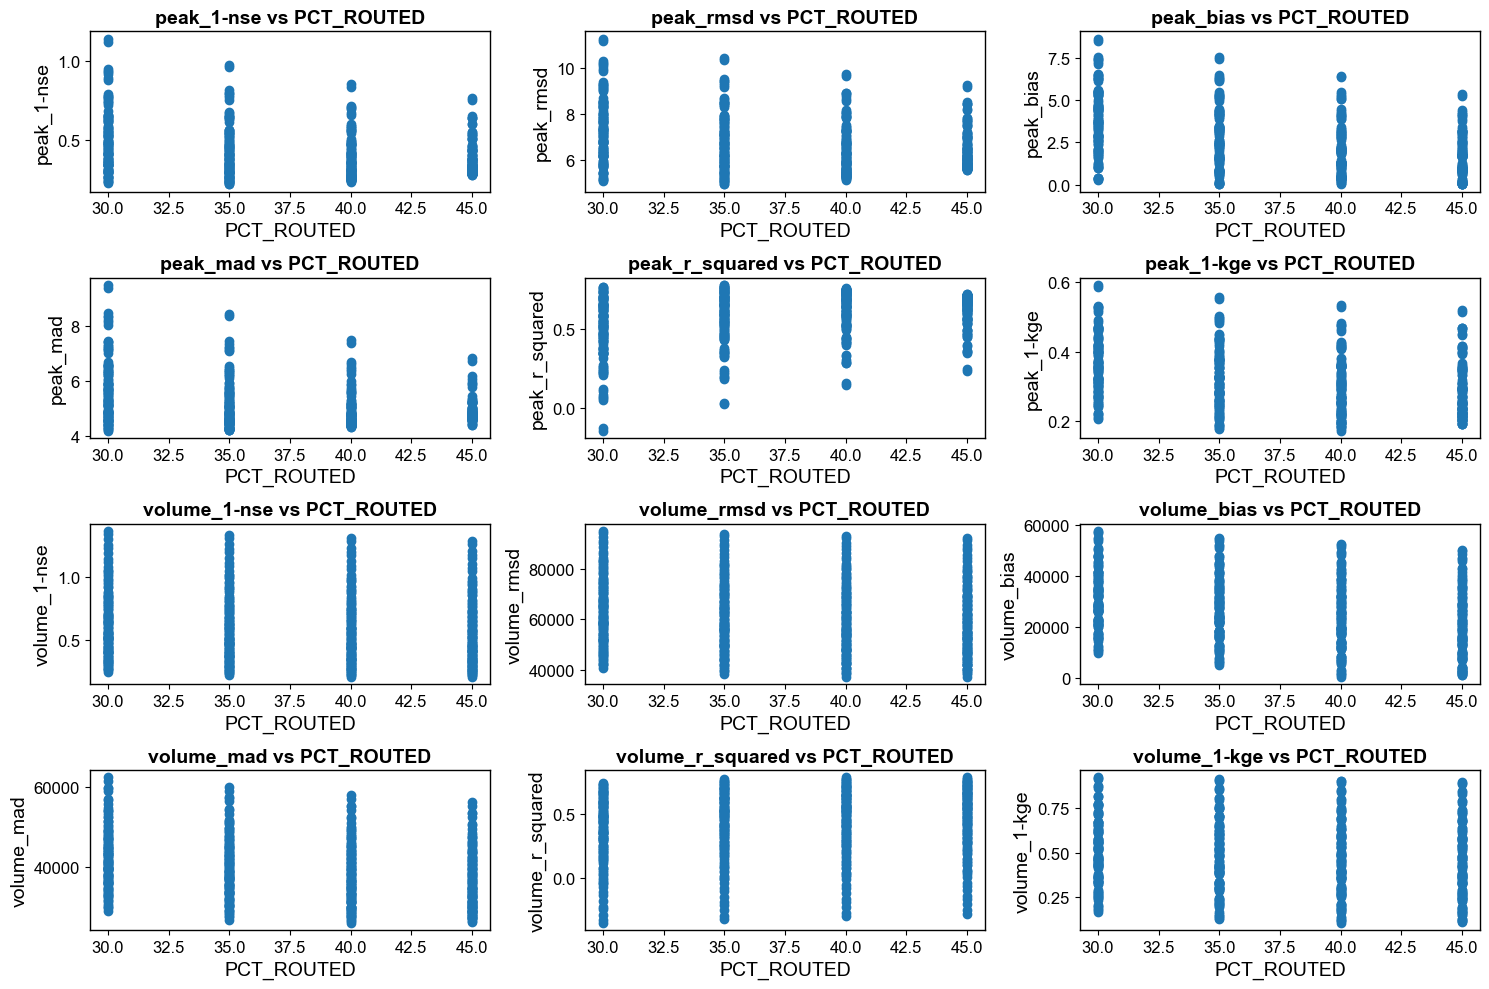

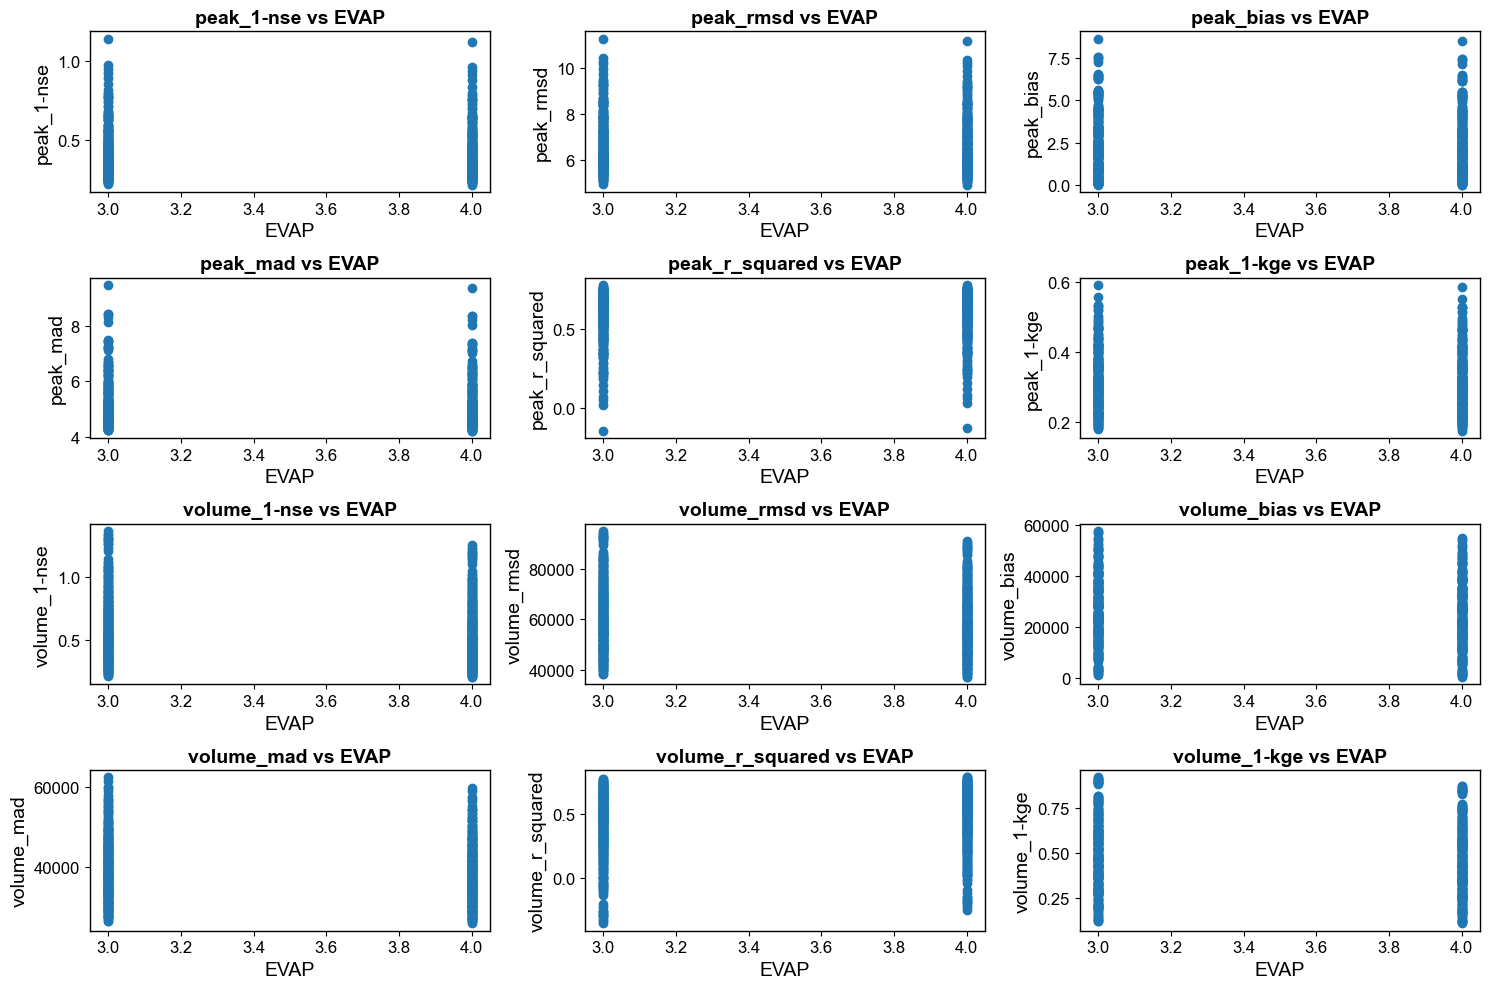

In [34]:
# Assuming x_factor is a list of factors
factors = cali_total_df['Factors'].columns  # Replace with your actual factors

for factor in factors:
    x_param = ('Factors', factor)
    y_params = cali_total_df.columns[-12:]  # Assuming you want to plot all parameters
    plot_param_scatter(cali_total_df, x_param, y_params)


In [35]:
def observation_and_swmm_hydrograph(storm_df, date):
    """
    This function takes observation and SWMM model runoff and precipitation data and puts it in a hydrograph.
    Params:
     - storm_df: df, The DataFrame that includes the runoff and precipitation data
     - date: date of storm occurrence. Format: 'yyyy_mm_dd'
    Returns: a hydrograph plot for one subcatchment
    """
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(storm_df.index.strftime('%d/%m/%Y')[0], fontsize=20)

    y_obs_runoff = storm_df['OBS runoff [CMS]']
    y_rainfall = storm_df['rainfall [mm/h]']
    y_sim_runoff = storm_df['SWMM outflow [CMS]']
    y_sim_out_flow = storm_df['SWMM outflow [CMS]']

    ax1 = sns.lineplot(ax=ax, data=y_obs_runoff, color='g', label='Observed Runoff')
    ax2 = ax1.twinx()
#     ax2.set_ylabel('Rainfall ($mm/hr$)')

    sns.lineplot(ax=ax2, data=y_rainfall, color='b', label='Rainfall', alpha=0.4)
    ax2.fill_between(storm_df.index, 0, y_rainfall, alpha=0.4, color='b')
#     ax2.set_ylim(ymin=y_rainfall.max() + 50, ymax=0)
    ax2.set_ylim(ymin=70, ymax=0)
    ax1.set_ylim(ymin=0, ymax=90)
    

    sns.lineplot(ax=ax, data=y_sim_runoff, color='r', label='Simulated Runoff')

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax1.set_ylabel('Runoff ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=15)

    # set x-axis label format to %d/%m %H
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax1.tick_params(axis='y', labelsize=18) ; ax2.tick_params(axis='y', labelsize=18)
    ax1.grid()

    return fig


## Response Surfaces

In [36]:
def heatmap_plot(x_factor, y_factor, constant_factors, stat_parameters):
    """
    Plots a heatmap for SWMM model calibration with variable X and Y based on specific constant factors and their values.

    Args:
        x_factor (str): Name of the factor for the X-axis.
        y_factor (str): Name of the factor for the Y-axis.
        constant_factors (list of tuples): List of (factor, value) pairs for filtering data.
        stat_parameters (list of str): List of statistical parameter names for plotting.
    """
    # Filter the DataFrame based on constant factors and their values
    condition = True
    for factor, value in constant_factors:
        condition &= (cali_total_df[('Factors', factor)] == value)
    cons_factors_df = cali_total_df[condition]

    # Define X, Y, and Z based on filtered data
    x = cons_factors_df[('Factors', x_factor)]
    y = cons_factors_df[('Factors', y_factor)]
    z = [cons_factors_df.loc[:, sp] for sp in stat_parameters]

    # Create the figure and subplots
    fig, ax = plt.subplots(2, 3, figsize=(18, 12))
    
    for i, (axi, zi, sp) in enumerate(zip(ax.flatten(), z, stat_parameters)):
        # Define contour levels and color map
        levels = np.linspace(zi.min(), zi.max(), num=20)
        cmap = plt.get_cmap('coolwarm')
        
        # Plot the heatmap
        contourf = axi.tricontourf(x, y, zi, levels=levels, cmap=cmap)
        cbar = fig.colorbar(contourf, ax=axi, format='%.2f')
        cbar.set_label(sp[1], fontsize=16)
        
        # Set color bar tick label font size
        cbar.ax.tick_params(labelsize=14)
        
        # Set axis titles and labels
        axi.set_title(f'{sp[1]}', fontweight='bold', fontsize=16)
        axi.set_xlabel(x_factor, fontsize=16)
        axi.set_ylabel(y_factor, fontsize=16)
        
        # Set tick labels for both axes
        axi.set_xticklabels([f'{tick:.2f}' for tick in axi.get_xticks()], fontsize=14, rotation=90)
        axi.set_yticklabels([f'{tick:.2f}' for tick in axi.get_yticks()], fontsize=14)

    # Create main title including constant factors
    constant_factors_text = ', '.join([f"{factor} = {value}" for factor, value in constant_factors])
    main_title = f'SWMM Model Calibration\n{constant_factors_text}'
    fig.suptitle(main_title, fontsize=16, fontweight='bold')
    
    # Adjust layout
    plt.subplots_adjust(top=0.85, hspace=0.4, wspace=0.4)
    plt.show()


C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\4120754554.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  axi.set_xticklabels([f'{tick:.2f}' for tick in axi.get_xticks()], fontsize=14, rotation=90)
C:\Users\raznu\AppData\Local\Temp\ipykernel_11044\4120754554.py:45: UserWarning: FixedFormatter should only be used together with FixedLocator
  axi.set_yticklabels([f'{tick:.2f}' for tick in axi.get_yticks()], fontsize=14)


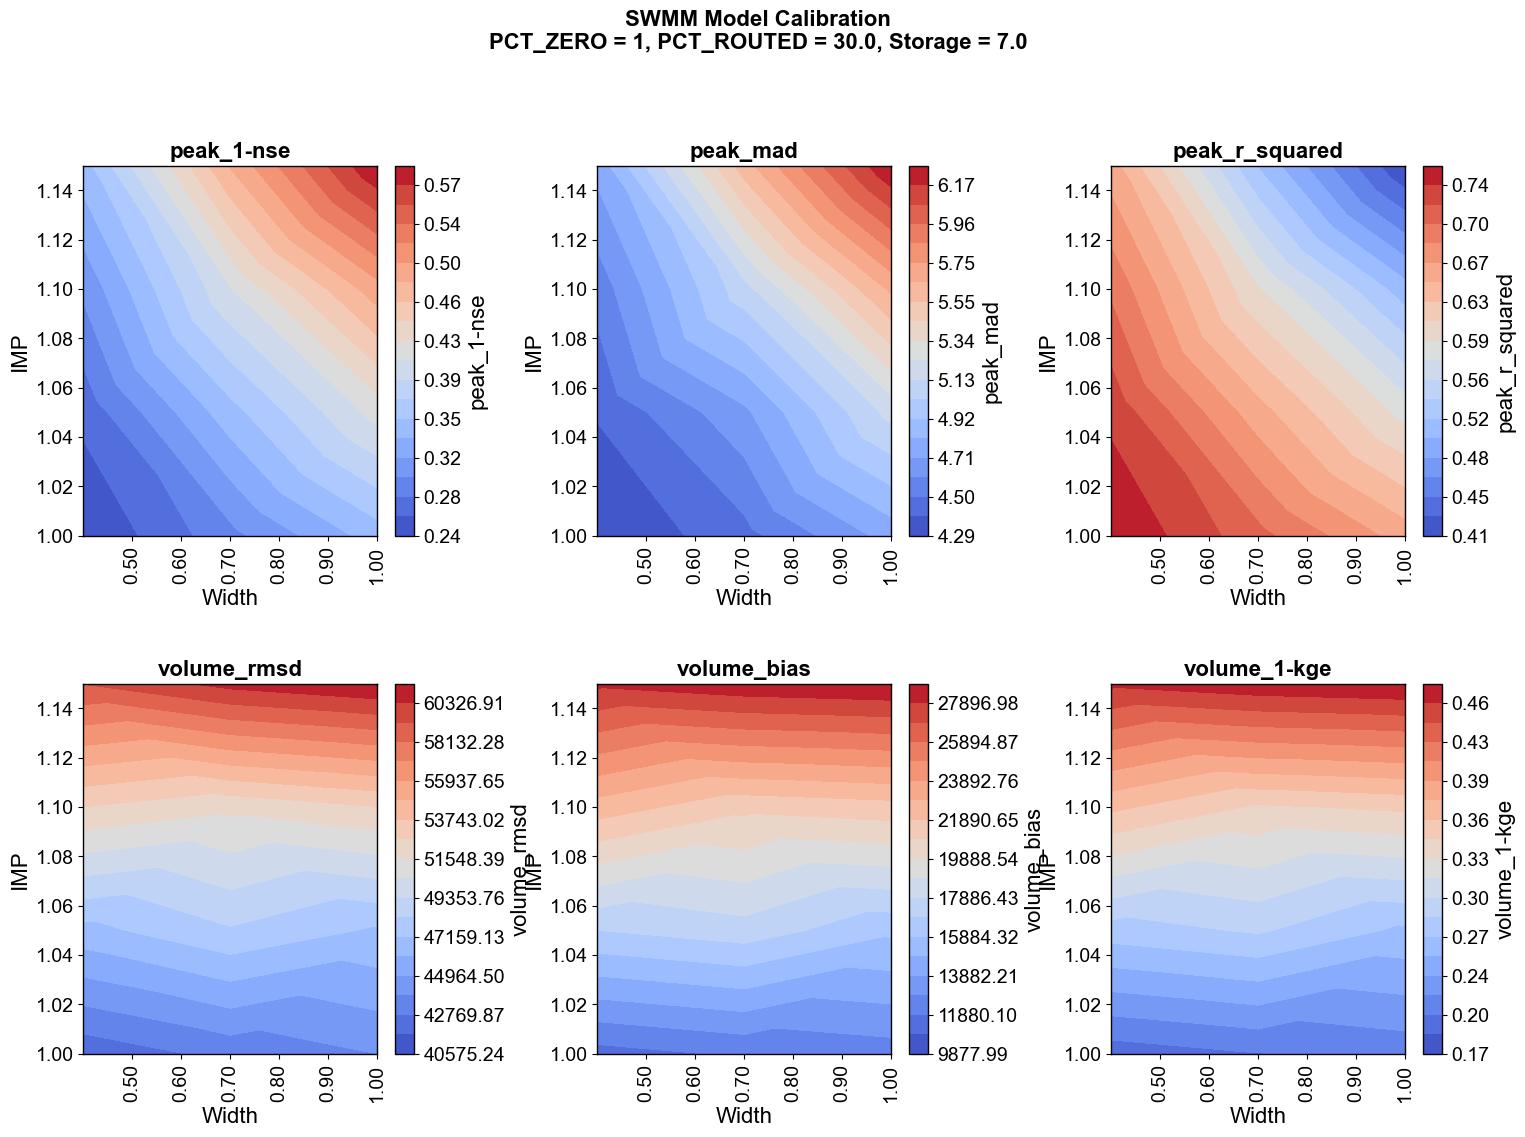

In [37]:
pct_routed_val = 30.0
imp_val = 1.00
storage_val = 7.0
pct_zero_val = 1
stat_parameters = cali_total_df.columns[[-12, -9, -8, -5, -4, -1]]

constant_factors = [
    ('PCT_ZERO', pct_zero_val),
    ('PCT_ROUTED', pct_routed_val),
    ('Storage', storage_val)
]

heatmap_plot('Width', 'IMP', constant_factors, stat_parameters)
